# TECH SAVVY INSTITUTE | PYTHON FOR DATA ANALYSIS

## Module 2 — NumPy, Pandas & Time Series: The Complete Study Notebook

**Author:** Benson M. Merita  
**Programme:** Python for Data Analysis & Claude AI Analytics — Tech Savvy Institute  
**Course material by:** Trainer Cantwel Njeri Otieno (Lessons 2, 4, 5, 6 and 8, Advanced Pandas I, and the Lesson 8 data-cleaning notebook)  
**Dataset:** *Retail Store Sales: Dirty for Data Cleaning* (`retail_store_sales.csv`, 12,575 rows × 11 columns)  
**Level:** Beginner → intermediate

This single notebook combines **everything** from Module 2: my own practice notebooks (`day1`, `day2`, `day3_4`), the NumPy notes, every trainer lesson (including the extended Lesson 8 with the data-cleaning pipeline), and a large set of extra examples. Every earlier error has been fixed, every TODO is completed, and **every task is shown with several different examples** so the pattern is clear rather than memorised from one case.

## Contents

| Part | Topic | Source |
|---|---|---|
| 0 | Setup and loading the data | — |
| 1 | NumPy foundations (1.1–1.9) | day1, day2, NumPy notes, Lesson 2, new examples |
| 2 | Pandas structures and reading/writing files (2.1–2.5) | Lesson 4, new examples |
| 3 | Inspecting, selecting and filtering (3.1–3.4) | Lesson 5, day3_4, new examples |
| 4 | Missing data, recovery and the full cleaning toolkit (4.1–4.3) | Lesson 6, Lesson 8 cleaning section, new examples |
| 5 | Aggregation: `groupby`, `agg`, `transform` (5.1–5.2) | Advanced Pandas I, day3_4, new examples |
| 6 | Reshaping: `pivot_table`, `crosstab`, `melt`, `stack` (6.1) | Lesson 8, new examples |
| 7 | Combining: `merge`, `join`, `concat` (7.1) | Lesson 8, new examples |
| 8 | Time series: `.dt`, `resample`, `rolling`, `shift` (8.1–8.9) | Lesson 8 (completed), new examples |
| 9 | Exploratory data analysis and visualisation | New |
| 10 | Capstone mini-project | New |
| 11 | Extra practice on a new dataset, with solutions | New |
| 12 | Common errors: read them, fix them | New |
| 13 | Self-quiz (27 questions with answers) | New |
| 14 | Cheat sheet, glossary, reflection | New |

## How this notebook is laid out

- **Bold-numbered cells** (**Q1.**, **Q2.** ...) are questions or tasks, usually grouped as **Example 1, 2, 3...** for the same task.
- A code cell follows with real, executed output.
- An *italic cell* after it gives the prediction or explanation.
- Cells marked *Fixed* replace mistakes from my earlier notebooks, with the reason explained.
- **Part 12 fails on purpose**: those red tracebacks are teaching material, each followed by the fix.
- Run the notebook top to bottom. `retail_store_sales.csv` must be in the same folder (or in a `data/` sub-folder).

---
# PART 0 — SETUP

**Q1.** Import the libraries, fix the random seed, and load `retail_store_sales.csv`. Check the shape straight away.

In [1]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
np.random.seed(42)                      # makes every random example repeatable

# Works whether the CSV sits next to the notebook or inside a data/ folder
DATA_PATH = next(p for p in [Path("retail_store_sales.csv"), Path("data/retail_store_sales.csv")] if p.exists())

os.makedirs("io_demo", exist_ok=True)   # scratch folder for the file read/write demos in Part 2

sales = pd.read_csv(DATA_PATH)
print("numpy:", np.__version__, "| pandas:", pd.__version__)
print("Shape:", sales.shape)
sales.head()

numpy: 2.4.4 | pandas: 3.0.2
Shape: (12575, 11)


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


*Fixed: my earlier notebooks loaded the file from a hard-coded `C:\Users\...` path, which breaks on any other computer. A relative path works everywhere. The seed keeps `np.random` examples identical on every run, so the outputs in this notebook match what you will see.*

---
# PART 1 — NUMPY FOUNDATIONS
*(day1, day2, NumPy notes, Lesson 2 — Week 3)*

NumPy (Numerical Python) is the foundation library for scientific computing in Python. It gives us the **ndarray**, an N-dimensional array that holds one data type and does maths on the whole array at once. Pandas is built on top of it.

## 1.1 Why NumPy? The speed test

**Q2.** Time a plain Python loop, a Python loop over a NumPy array, and a vectorised NumPy operation, all doing the same job on 1,000,000 numbers. Which is fastest?

In [2]:
big_list = list(range(1_000_000))

start = time.time()
total = sum(x * 2 for x in big_list)
print("Python list loop:            ", round(time.time() - start, 4), "seconds")

big_array = np.array(big_list)          # a real array of 1,000,000 numbers
start = time.time()
total = sum(x * 2 for x in big_array)   # a Python loop, but over the array
print("Python loop over NumPy array:", round(time.time() - start, 4), "seconds")

start = time.time()
total = (big_array * 2).sum()           # vectorised: one operation on the whole array
print("NumPy vectorised:            ", round(time.time() - start, 4), "seconds")

Python list loop:             0.029 seconds


Python loop over NumPy array: 0.1117 seconds
NumPy vectorised:             0.0041 seconds


*Prediction: the vectorised version wins by a wide margin. Fixed: my day1 version wrote `np.array(1000000)` (one single number, not a million) and then looped over `big_list` again, so it timed the same code twice. Here the array holds a million values. Note that looping over a NumPy array in Python is often *slower* than looping over a list, so the speed comes from vectorising, not from the array alone. Exact timings differ by machine.*

## 1.2 Creating arrays

**Q3.** Create a 1D array and a 2D array from lists, then read their `ndim`, `shape`, `dtype` and `itemsize`.

In [3]:
a = np.array([1, 2, 3])
b = np.array([[9.0, 8.0, 7.0], [6.0, 5.0, 4.0]])

print("a:", a, "| ndim:", a.ndim, "| shape:", a.shape, "| dtype:", a.dtype)
print("b:\n", b)
print("b ndim:", b.ndim, "| shape:", b.shape, "| dtype:", b.dtype, "| itemsize:", b.itemsize, "bytes")

a: [1 2 3] | ndim: 1 | shape: (3,) | dtype: int64
b:
 [[9. 8. 7.]
 [6. 5. 4.]]
b ndim: 2 | shape: (2, 3) | dtype: float64 | itemsize: 8 bytes


*`ndim` is the number of axes (1 = vector, 2 = table), `shape` is the size along each axis as (rows, columns), `dtype` is the single type shared by all values, and `itemsize` is the bytes each value takes (8 for float64).*

**Q4.** Build arrays without typing the values: all zeros, all ones, a constant, random decimals, random integers, and an identity matrix.

In [4]:
print("zeros 1D:", np.zeros(3))
print("zeros 2x3:\n", np.zeros((2, 3)))
print("ones 3x3:\n", np.ones((3, 3)))
print("ones 3D (3,4,5) shape:", np.ones((3, 4, 5)).shape)
print("ones as int32:\n", np.ones((2, 2), dtype="int32"))
print("full of 99:\n", np.full((2, 2), 99))
print("random decimals 0-1:\n", np.random.rand(3, 3).round(3))
print("random integers 0-9:\n", np.random.randint(0, 10, size=(3, 3)))
print("identity 4x4:\n", np.identity(4))
print("repeat a row 3 times:\n", np.repeat(np.array([[1, 2, 3]]), 3, axis=0))

zeros 1D: [0. 0. 0.]
zeros 2x3:
 [[0. 0. 0.]
 [0. 0. 0.]]
ones 3x3:
 [[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]
ones 3D (3,4,5) shape: (3, 4, 5)
ones as int32:
 [[1 1]
 [1 1]]
full of 99:
 [[99 99]
 [99 99]]
random decimals 0-1:
 [[0.375 0.951 0.732]
 [0.599 0.156 0.156]
 [0.058 0.866 0.601]]
random integers 0-9:
 [[7 2 5]
 [4 1 7]
 [5 1 4]]
identity 4x4:
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
repeat a row 3 times:
 [[1 2 3]
 [1 2 3]
 [1 2 3]]


*The shape goes in as ONE tuple, for example `(2, 3)`. `randint(low, high)` never returns `high` itself. `np.identity(n)` puts 1 on the diagonal and 0 everywhere else.*

**Q5.** What happens if you write `np.array(2, 3)`, hoping for a 2×3 array?

In [5]:
try:
    np.array(2, 3)
except TypeError as e:
    print("TypeError:", e)

print(np.array([2, 3]))        # what that call actually builds: the values 2 and 3
print(np.zeros((2, 3)))        # what was probably wanted: a 2x3 grid

TypeError: Cannot interpret '3' as a data type
[2 3]
[[0. 0. 0.]
 [0. 0. 0.]]


*`np.array()` builds an array from the data you give it. Its second argument is `dtype`, not a second dimension, so NumPy refuses the `3`. To get a shape, use `zeros`, `ones` or `full` with a tuple.*

## 1.3 Names, copies and views

**Q6.** `b = a` does not copy an array. Show the difference between re-assigning a name and changing an array in place.

In [6]:
a = np.array([1, 2, 3])
b = a                       # b is a second NAME for the same array
b = np.array([4, 5, 6])     # re-assigning b points it at a NEW array; a is untouched
print("a:", a, "| b:", b)

a = np.array([1, 2, 3])
b = a
b[0] = 100                  # changing the data IN PLACE is seen through both names
print("a:", a, "| b:", b)

a = np.array([1, 2, 3])
c = a.copy()                # .copy() makes a fully independent array
c[0] = 100
print("a:", a, "| c:", c)

a: [1 2 3] | b: [4 5 6]
a: [100   2   3] | b: [100   2   3]
a: [1 2 3] | c: [100   2   3]


*Prediction: after re-assignment `a` is unchanged. After the in-place change `a` also becomes `[100 2 3]`, because there was only ever one array. `.copy()` is the safe way to get an independent one. My day1 notebook only showed the re-assignment case, which hides the real danger.*

## 1.4 Indexing, slicing, reshaping

**Q7.** Create the `sales_np` table from my day2 notebook (3 branches × 3 products) and inspect it.

In [7]:
sales_np = np.array([
    [120, 340, 400],
    [345, 674, 898],
    [4456, 789, 234],
])
print(sales_np)
print("shape:", sales_np.shape, "| ndim:", sales_np.ndim, "| dtype:", sales_np.dtype)

[[ 120  340  400]
 [ 345  674  898]
 [4456  789  234]]
shape: (3, 3) | ndim: 2 | dtype: int64


*A 3×3 table of integers: `shape` is (3, 3), `ndim` is 2, and the dtype is `int64` on most systems.*

**Q8.** Pull out the first row, last row, first column, last column and one single value.

In [8]:
print("first row:   ", sales_np[0, :])
print("last row:    ", sales_np[-1])          # sales_np[-1:] would keep a 2D shape: [[...]]
print("last row 2D: ", sales_np[-1:])
print("first column:", sales_np[:, 0])
print("last column: ", sales_np[:, -1])
print("row 0, col 0:", sales_np[0, 0])
print("2nd column, all rows:", sales_np[:, 1])

first row:    [120 340 400]
last row:     [4456  789  234]
last row 2D:  [[4456  789  234]]
first column: [ 120  345 4456]
last column:  [400 898 234]
row 0, col 0: 120
2nd column, all rows: [340 674 789]


*Fixed: day2 used `sales[-1 :]`, which returned `[[4456 789 234]]` (a 2D row) when I wanted a flat row. `sales[-1]` gives the flat row; the slice `[-1:]` keeps the extra dimension. In `[rows, columns]`, `:` means "all".*

**Q9.** Flatten the table, reshape it back, and show that slices are views while `.copy()` is independent.

In [9]:
flat = sales_np.flatten()
print("flat:", flat, "| ndim:", flat.ndim)
reshaped = flat.reshape(3, 3)
print("reshaped back equals original:", np.array_equal(reshaped, sales_np))

sale = sales_np.copy()                 # work on a copy so sales_np stays clean
row_slice = sale[0, :]                 # a VIEW of row 0
row_slice[0] = 850                     # change the view...
print("sale after editing the view:\n", sale)   # ...the parent array changed too

safe_row = sales_np[0, :].copy()       # an independent copy
safe_row[0] = -1
print("sales_np unchanged:\n", sales_np)

flat: [ 120  340  400  345  674  898 4456  789  234] | ndim: 1
reshaped back equals original: True
sale after editing the view:
 [[ 850  340  400]
 [ 345  674  898]
 [4456  789  234]]
sales_np unchanged:
 [[ 120  340  400]
 [ 345  674  898]
 [4456  789  234]]


*`flatten()` returns a new 1D copy and `reshape()` rearranges the same values. A slice is a **view** onto the parent's memory, so editing it edits the parent. Call `.copy()` before editing a slice you want to keep separate. This is the most common NumPy surprise.*

## 1.5 Vectorised arithmetic and broadcasting

**Q10.** Give five products a 10% discount using a loop, then using NumPy.

In [10]:
prices = [120, 450, 75, 300, 60]

discounted_loop = []
for p in prices:
    discounted_loop.append(p * 0.9)
print("loop result:      ", discounted_loop)

price_array = np.array(prices)
print("vectorised result:", price_array * 0.9)

loop result:       [108.0, 405.0, 67.5, 270.0, 54.0]
vectorised result: [108.  405.   67.5 270.   54. ]


*Same answer, one line instead of four. Vectorisation shortens the code and speeds up large arrays because the loop runs in optimised compiled code. It does not mean no iteration happens internally.*

**Q11.** Apply a different discount to each product across a price matrix without a loop.

In [11]:
price_matrix = np.array([
    [1000, 2000, 1500],
    [800, 1200, 900],
])
discount_row = np.array([0.9, 0.8, 0.95])     # one discount per PRODUCT (3 values)

print(price_matrix * discount_row)

[[ 900. 1600. 1425.]
 [ 720.  960.  855.]]


*Fixed: my day2 notebook ended with `price matrix = np.array(...)`, which is a SyntaxError because variable names cannot contain spaces. The name is `price_matrix`. Broadcasting stretches the shape-`(3,)` row across both rows of the `(2, 3)` matrix automatically.*

## 1.6 Statistics and `np.where`

**Q12.** Compute the mean, standard deviation, variance and 90th percentile of daily returns, then find the position of the best day.

In [12]:
daily_returns = np.array([0.8, -1.2, 2.1, 0.4, -0.5, 1.8, -2.3, 0.9])

print("mean:", daily_returns.mean())
print("std (volatility):", daily_returns.std())
print("variance:", daily_returns.var())
print("90th percentile:", np.percentile(daily_returns, 90))
print("position of max:", daily_returns.argmax())
print("value at that position:", daily_returns[daily_returns.argmax()])

mean: 0.25
std (volatility): 1.4026760139105539
variance: 1.9675000000000002
90th percentile: 1.89
position of max: 2
value at that position: 2.1


*`argmax()` and `argmin()` return the **position**, not the value. Standard deviation measures spread; the percentile is the value below which that share of observations fall.*

**Q13.** Flag each day as "above average" or "below average" with `np.where`.

In [13]:
average = daily_returns.mean()
flags = np.where(daily_returns > average, "above average", "below average")
print(flags)

['above average' 'below average' 'above average' 'above average'
 'below average' 'above average' 'below average' 'above average']


*Fixed: my day2 notebook ended with `average = daily_returns.mean()` and an unfinished `flags = ` line, and `daily_returns` had never been created in that notebook. `np.where(condition, value_if_true, value_if_false)` works on the whole array at once.*

## 1.7 Lesson 2 practice, completed

**Q14.** **TODO 1:** extract the last column of the Lesson 2 `sales` table. **TODO 2:** make an independent copy of row 1, set its first value to 0, and confirm the original is unchanged.

In [14]:
lesson_sales = np.array([
    [120, 450, 75, 300],
    [200, 310, 90, 150],
    [175, 260, 60, 220],
])

last_column = lesson_sales[:, -1]
print("last column:", last_column)

row1_copy = lesson_sales[1, :].copy()
row1_copy[0] = 0
print("row1_copy:", row1_copy)
print("original unchanged:\n", lesson_sales)

last column: [300 150 220]
row1_copy: [  0 310  90 150]
original unchanged:
 [[120 450  75 300]
 [200 310  90 150]
 [175 260  60 220]]


*The copy changed, the original did not, which is exactly what `.copy()` promises.*

**Q15.** **Part 7:** apply a 15% markup to `price_matrix` by broadcasting and print the mean and standard deviation.

In [15]:
marked_up_matrix = price_matrix * 1.15
print(marked_up_matrix)
print("mean:", marked_up_matrix.mean())
print("std:", marked_up_matrix.std())

[[1150. 2300. 1725.]
 [ 920. 1380. 1035.]]
mean: 1418.3333333333333
std: 472.6050735609549


*Multiplying by 1.15 scales every value, so the mean and the standard deviation both grow by exactly 15%.*

**Q16.** **Self-checks 1 to 4** from the quiz-prep section.

In [16]:
# Self-check 1
class_scores = np.array([68, 74, 91, 55, 82, 77])
print("shape:", class_scores.shape, "| dtype:", class_scores.dtype)

# Self-check 2
grid = np.arange(1, 13).reshape(4, 3)
print("second row:", grid[1, :])
print("first column:", grid[:, 0])

# Self-check 3
branch_prices = np.array([[500, 800, 300], [600, 750, 400]])
discount = np.array([0.9, 0.85, 0.95])
print("discounted:\n", branch_prices * discount)

# Self-check 4
print("mean:", class_scores.mean(), "| std:", round(class_scores.std(), 3))
print(np.where(class_scores >= 50, "pass", "fail"))

shape: (6,) | dtype: int64
second row: [4 5 6]
first column: [ 1  4  7 10]
discounted:
 [[450.  680.  285. ]
 [540.  637.5 380. ]]
mean: 74.5 | std: 11.236
['pass' 'pass' 'pass' 'pass' 'pass' 'pass']


**Q17.** **Reflect:** in your own words, what is the difference between a view and a copy, and why does it matter when editing a slice?

*A view shares memory with the original array, so changing the slice changes the original. A copy owns separate memory, so changes stay local. It matters because an edit to a slice can silently corrupt the source data; taking `.copy()` first makes the intent explicit and the original safe.*

**Quiz-prep answers.** `.shape` tells you how the data is laid out, so check it first. `np.arange(start, stop, step)` steps by a fixed *increment*, while `np.linspace(start, stop, num)` gives a fixed *number of points*, both shown next. A slice can change the original because it is a view. `argmin()` and `argmax()` return positions. `np.where()` needs a condition, a value if true, and a value if false.

## 1.8 Extra NumPy practice (new examples)
Topics the quiz-prep list mentioned but the notes never demonstrated: `arange`, `linspace`, axis-wise statistics, boolean masks on arrays, sorting and cumulative sums.

**Q18.** `np.arange` and `np.linspace` both make sequences. Build a list of bus stops numbered 1 to 10 and five evenly spaced points from 0 to 1.

In [17]:
print("arange(1, 11):      ", np.arange(1, 11))
print("arange(0, 20, 5):   ", np.arange(0, 20, 5))
print("linspace(0, 1, 5):  ", np.linspace(0, 1, 5))

arange(1, 11):       [ 1  2  3  4  5  6  7  8  9 10]
arange(0, 20, 5):    [ 0  5 10 15]
linspace(0, 1, 5):   [0.   0.25 0.5  0.75 1.  ]


*`arange(start, stop, step)` stops *before* `stop` and you choose the step size. `linspace(start, stop, num)` *includes* `stop` and you choose how many points. Use `arange` for counting and `linspace` for evenly spaced measurements.*

**Q19.** A matatu operator recorded daily fares (Ksh) for 3 routes over 4 days. Find each route's total, each day's total, and the overall average.

In [18]:
fares = np.array([
    [12500, 13200, 11800, 14100],     # Route 1: Mon..Thu
    [ 9800, 10100,  9600, 10500],     # Route 2
    [15200, 14800, 15900, 16300],     # Route 3
])

print("total per route (sum across days, axis=1):", fares.sum(axis=1))
print("total per day   (sum across routes, axis=0):", fares.sum(axis=0))
print(f"overall average: Ksh {fares.mean():,.2f}")
print("best route:", fares.sum(axis=1).argmax() + 1)

total per route (sum across days, axis=1): [51600 40000 62200]
total per day   (sum across routes, axis=0): [37500 38100 37300 40900]
overall average: Ksh 12,816.67
best route: 3


*`axis=0` collapses the rows, giving one number per column (per day). `axis=1` collapses the columns, giving one number per row (per route). Remember: axis=0 runs down, axis=1 runs across. `argmax()` returns a position starting at 0, so add 1 for the route number.*

**Q20.** Which route-days earned more than Ksh 14,000? How many were there, and what did they add up to?

In [19]:
mask = fares > 14000
print(mask)
print("count:", mask.sum())
print("values:", fares[mask])
print(f"total of those: Ksh {fares[mask].sum():,}")

[[False False False  True]
 [False False False False]
 [ True  True  True  True]]
count: 5
values: [14100 15200 14800 15900 16300]
total of those: Ksh 76,300


*A comparison on an array returns an array of True/False. Using it as an index keeps only the True positions, and `mask.sum()` counts the Trues because True counts as 1. Pandas boolean masking in Part 3 uses exactly this idea.*

**Q21.** Sort Route 1's fares from lowest to highest, get the running total, and the day-to-day change.

In [20]:
route1 = fares[0]
print("sorted:", np.sort(route1))
print("running total:", route1.cumsum())
print("day-to-day change:", np.diff(route1))

sorted: [11800 12500 13200 14100]
running total: [12500 25700 37500 51600]
day-to-day change: [  700 -1400  2300]


*`np.sort` returns a sorted copy. `cumsum()` adds as it goes, so the last value equals the total. `np.diff` subtracts each value from the next, so its result is one element shorter.*

## 1.9 More NumPy examples (several per task)
Each task below is shown with **three different examples** so the pattern sticks.

### Task: changing a dtype

**Q22.** Example 1: convert an array of whole numbers to decimals and back. What gets lost on the way back?

In [21]:
scores = np.array([68, 74, 91, 55])
as_float = scores.astype(float)
print(as_float, as_float.dtype)

measurements = np.array([2.9, 3.5, 7.99, -1.7])
print(measurements.astype(int))

[68. 74. 91. 55.] float64
[ 2  3  7 -1]


*Whole numbers become decimals without loss. Going from decimals to integers **truncates toward zero** (2.9 → 2, −1.7 → −1); it does not round. Use `np.round` first if you want rounding.*

**Q23.** Example 2: convert text digits to numbers.

In [22]:
text_digits = np.array(["10", "20", "30"])
print(text_digits.dtype)
numbers = text_digits.astype(int)
print(numbers, numbers.sum())

<U2
[10 20 30] 60


**Q24.** Example 3: convert numbers to True/False and count the non-zero values.

In [23]:
visits = np.array([0, 3, 0, 5, 1, 0])
flags = visits.astype(bool)
print(flags, "| non-zero days:", flags.sum())

[False  True False  True  True False] | non-zero days: 3


*Zero becomes `False` and every other number becomes `True`. Summing a boolean array counts the Trues.*

### Task: joining arrays

**Q25.** Example 1: stack two branches' sales as new rows with `vstack`.

In [24]:
branch_a = np.array([120, 340, 400])
branch_b = np.array([345, 674, 898])
print(np.vstack([branch_a, branch_b]))

[[120 340 400]
 [345 674 898]]


**Q26.** Example 2: place two columns side by side with `hstack` and `column_stack`.

In [25]:
price = np.array([100, 250, 80])
qty = np.array([3, 1, 5])
print(np.column_stack([price, qty]))
print(np.hstack([price, qty]))     # joins end to end instead

[[100   3]
 [250   1]
 [ 80   5]]
[100 250  80   3   1   5]


*`column_stack` treats each 1D array as a column; `hstack` on 1D arrays simply joins them into one longer array. Choose by the shape you want.*

**Q27.** Example 3: `np.concatenate` along either axis.

In [26]:
a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6]])
print(np.concatenate([a, b], axis=0))          # add a row
print(np.concatenate([a, b.T], axis=1))        # add a column (b transposed to a column)

[[1 2]
 [3 4]
 [5 6]]
[[1 2 5]
 [3 4 6]]


### Task: broadcasting

**Q28.** Example 1: subtract each branch's own average from its row (column vector broadcasting).

In [27]:
sales_grid = np.array([[100, 120, 140],
                       [200, 180, 220]])
row_means = sales_grid.mean(axis=1, keepdims=True)    # shape (2, 1), not (2,)
print(row_means)
print(sales_grid - row_means)

[[120.]
 [200.]]
[[-20.   0.  20.]
 [  0. -20.  20.]]


*`keepdims=True` keeps the result as a column (2, 1) so it stretches across the columns. Without it the shape is `(2,)` and the subtraction would line up on the wrong axis.*

**Q29.** Example 2: scale every column to a 0–1 range (min-max scaling).

In [28]:
data = np.array([[10, 200], [20, 400], [30, 600]], dtype=float)
scaled = (data - data.min(axis=0)) / (data.max(axis=0) - data.min(axis=0))
print(scaled)

[[0.  0. ]
 [0.5 0.5]
 [1.  1. ]]


**Q30.** Example 3: what happens when shapes cannot broadcast?

In [29]:
try:
    np.ones((2, 3)) + np.ones((2,))
except ValueError as e:
    print("ValueError:", e)
print(np.ones((2, 3)) + np.ones((3,)))     # this one works

ValueError: operands could not be broadcast together with shapes (2,3) (2,) 
[[2. 2. 2.]
 [2. 2. 2.]]


*Shapes broadcast when, comparing from the right, each pair of sizes is equal or one of them is 1. `(2, 3)` with `(3,)` works; `(2, 3)` with `(2,)` does not.*

### Task: finding and counting values

**Q31.** Example 1: unique values and how often each appears.

In [30]:
payments = np.array(["Cash", "M-Pesa", "Cash", "Card", "M-Pesa", "Cash"])
values, counts = np.unique(payments, return_counts=True)
print(dict(zip(values.tolist(), counts.tolist())))

{'Card': 1, 'Cash': 3, 'M-Pesa': 2}


**Q32.** Example 2: positions where a condition is true, with `np.where` (one argument).

In [31]:
temps = np.array([22.5, 31.0, 28.5, 19.0, 33.5])
hot_days = np.where(temps > 30)[0]
print("hot day positions:", hot_days, "| values:", temps[hot_days])

hot day positions: [1 4] | values: [31.  33.5]


**Q33.** Example 3: grade bands with `np.select` (more than two outcomes).

In [32]:
marks = np.array([34, 52, 68, 75, 91])
grades = np.select([marks >= 80, marks >= 60, marks >= 40], ["A", "B", "C"], default="F")
print(list(zip(marks.tolist(), grades.tolist())))

[(34, 'F'), (52, 'C'), (68, 'B'), (75, 'B'), (91, 'A')]


*`np.where` handles two outcomes; `np.select` takes a list of conditions (checked in order) and a list of results. The first matching condition wins, so order them from strictest to loosest.*

### Task: missing values in arrays

**Q34.** Example 1: why does the mean of an array with `nan` come out as `nan`?

In [33]:
x = np.array([4.0, np.nan, 6.0, 10.0])
print("mean:", x.mean())
print("nanmean:", np.nanmean(x))
print("nansum:", np.nansum(x), "| nanmax:", np.nanmax(x))

mean: nan
nanmean: 6.666666666666667
nansum: 20.0 | nanmax: 10.0


*Any arithmetic with `nan` gives `nan`, so the plain mean is `nan`. The `nan`-versions skip missing values. pandas does this skipping automatically, which is why `Series.mean()` works on columns with gaps.*

**Q35.** Example 2: count and locate missing values.

In [34]:
print("missing count:", np.isnan(x).sum())
print("missing positions:", np.where(np.isnan(x))[0])
print("without missing:", x[~np.isnan(x)])

missing count: 1
missing positions: [1]
without missing: [ 4.  6. 10.]


**Q36.** Example 3: fill missing values with the column average.

In [35]:
filled = np.where(np.isnan(x), np.nanmean(x), x)
print(filled)

[ 4.          6.66666667  6.         10.        ]


### Task: sorting, ranking and limits

**Q37.** Example 1: sort, and get the ordering with `argsort`.

In [36]:
prices = np.array([120, 450, 75, 300, 60])
names = np.array(["Sugar", "Rice", "Flour", "Oil", "Salt"])
order = np.argsort(prices)
print("cheapest first:", names[order])
print("most expensive:", names[order[-1]])

cheapest first: ['Salt' 'Flour' 'Sugar' 'Oil' 'Rice']
most expensive: Rice


*`argsort` returns the *positions* that would sort the array. Using those positions to index a second array keeps related arrays in step (names stay matched with prices).*

**Q38.** Example 2: cap extreme values with `np.clip`.

In [37]:
orders = np.array([2, 5, 120, 7, 3, 300])
print(np.clip(orders, 0, 50))

[ 2  5 50  7  3 50]


**Q39.** Example 3: random sampling and shuffling with a seed.

In [38]:
rng = np.random.default_rng(7)
customers = np.arange(1, 11)
print("sample of 4:", rng.choice(customers, size=4, replace=False))
print("shuffled:", rng.permutation(customers))
print("normal draws:", rng.normal(loc=100, scale=15, size=5).round(1))

sample of 4: [ 7  6 10  9]
shuffled: [ 4  3  7  9  2 10  1  8  5  6]
normal draws: [105.4 101.6  86.   99.6 110.4]


*A seeded generator makes the random results repeatable. `replace=False` means no value is chosen twice.*

---
# PART 2 — PANDAS STRUCTURES AND FILES
*(Lesson 4 — Week 4, Session 1)*

Pandas is the library for **tabular data**. It is built on NumPy but adds row labels, column names, a separate data type per column, and easy file reading and writing. Its two core structures are the **Series** (one labelled column) and the **DataFrame** (a table of Series that share one index).

## 2.1 Where NumPy struggles

**Q40.** Put mixed text, numbers and True/False into one NumPy array and try to add 1 to the price column.

In [39]:
product_table = np.array([
    ["Sugar", 120, True],
    ["Rice",  450, True],
    ["Flour",  75, False],
    ["Oil",   300, True],
])
print(product_table)
print("dtype:", product_table.dtype)

try:
    print(product_table[:, 1] + 1)
except Exception as e:
    print("Error type:", type(e).__name__)
    print("Message:   ", e)

[['Sugar' '120' 'True']
 ['Rice' '450' 'True']
 ['Flour' '75' 'False']
 ['Oil' '300' 'True']]


dtype: <U21
Error type: UFuncTypeError
Message:    ufunc 'add' did not contain a loop with signature matching types (dtype('<U21'), dtype('int64')) -> None


*Prediction: it fails. An array has one dtype, so NumPy turned every value into text and cannot add a number to text. That is the gap pandas fills: one dtype per column, labels, and file support.*

| In Excel | In pandas |
|---|---|
| A worksheet | A DataFrame |
| One column | A Series |
| Row numbers down the left | The index |
| The header row | The column names |
| Open a .csv / .xlsx file | `pd.read_csv()` / `pd.read_excel()` |
| Save As... | `df.to_csv()` / `df.to_excel()` |

## 2.2 The Series

**Q41.** Build a Series of four prices, look at its values, index and dtype, then give it your own labels.

In [40]:
prices = pd.Series([120, 450, 75, 300], name="price")
print(prices)
print("values:", prices.values, "| type:", type(prices.values).__name__)
print("index:", prices.index)

prices_labeled = pd.Series([120, 450, 75, 300], index=["Sugar", "Rice", "Flour", "Oil"], name="price")
print(prices_labeled)
print("Price of Rice:", prices_labeled["Rice"])

0    120
1    450
2     75
3    300
Name: price, dtype: int64


values: [120 450  75 300] | type: ndarray
index: RangeIndex(start=0, stop=4, step=1)
Sugar    120
Rice     450
Flour     75
Oil      300
Name: price, dtype: int64
Price of Rice: 450


*A Series is a NumPy array plus an index (and a name). With labels you ask for `"Rice"` instead of remembering it sits in position 1.*

**Q42.** Do maths on the labelled Series. Do the labels survive a 10% price rise?

In [41]:
print(prices_labeled * 1.10)
print("Average price:", np.mean(prices_labeled))
print("Highest price:", np.max(prices_labeled))

Sugar    132.0
Rice     495.0
Flour     82.5
Oil      330.0
Name: price, dtype: float64
Average price: 236.25
Highest price: 450


*Prediction: yes, the labels stay attached. NumPy functions also work directly on a Series.*

**Q43.** **TODO:** a kiosk recorded sales in KES for Monday to Friday: 1500, 1800, 1200, 2100, 2500. Make a Series called `daily_sales` (index Mon..Fri, name `sales_kes`), print Wednesday by label, then all sales in thousands.

In [42]:
daily_sales = pd.Series(
    [1500, 1800, 1200, 2100, 2500],
    index=["Mon", "Tue", "Wed", "Thu", "Fri"],
    name="sales_kes",
)
print(daily_sales)
print("\nWednesday:", daily_sales["Wed"])
print("\nIn thousands of KES:")
print(daily_sales / 1000)

Mon    1500
Tue    1800
Wed    1200
Thu    2100
Fri    2500
Name: sales_kes, dtype: int64

Wednesday: 1200

In thousands of KES:
Mon    1.5
Tue    1.8
Wed    1.2
Thu    2.1
Fri    2.5
Name: sales_kes, dtype: float64


*Fixed: my first attempt printed `prices / 1000` at the last step. That is a *different* Series (the four grocery prices from earlier), so the output looked plausible but answered the wrong question. It also used the name `prices` and lower-case day labels. Using the wrong variable name is a silent error, so always check that the numbers match the data you meant.*

## 2.3 The DataFrame

**Q44.** Build a DataFrame from a dictionary of lists and check its dtypes, index, columns and shape.

In [43]:
data = {
    "product": ["Sugar", "Rice", "Flour", "Oil"],
    "price": [120, 450, 75, 300],
    "in_stock": [True, True, False, True],
}
df = pd.DataFrame(data)
print(df)
print()
print(df.dtypes)
print("Index:", df.index)
print("Columns:", df.columns.tolist())
print("Shape (rows, columns):", df.shape)

  product  price  in_stock
0   Sugar    120      True
1    Rice    450      True
2   Flour     75     False
3     Oil    300      True

product       str
price       int64
in_stock     bool
dtype: object
Index: RangeIndex(start=0, stop=4, step=1)
Columns: ['product', 'price', 'in_stock']
Shape (rows, columns): (4, 3)


*The dictionary keys became column names and each list became a column. Every column keeps its own dtype: text, `int64` and `bool`. (Text may show as `str` in pandas 3, or `object` in older versions; both mean text.)*

**Q45.** Pull one column out. What type is it?

In [44]:
price_column = df["price"]
print(type(price_column).__name__)
print(price_column * 1.10)

Series
0    132.0
1    495.0
2     82.5
3    330.0
Name: price, dtype: float64


*A single column is a Series, so a DataFrame really is many Series sharing one index.*

**Q46.** Build a weather DataFrame. Predict the dtype of each column before running.

In [45]:
weather = pd.DataFrame({
    "city": ["Nairobi", "Mombasa", "Kisumu", "Nakuru"],
    "temp_c": [24.5, 31.0, 28.5, 22.0],
    "rained_today": [False, False, True, True],
})
print(weather)
print(weather.dtypes)

      city  temp_c  rained_today
0  Nairobi    24.5         False
1  Mombasa    31.0         False
2   Kisumu    28.5          True
3   Nakuru    22.0          True


city                str
temp_c          float64
rained_today       bool
dtype: object


*`temp_c` is `float64` because its values have decimals. Pandas picks the dtype column by column.*

**Q47.** What happens if the lists have different lengths?

In [46]:
try:
    broken = pd.DataFrame({
        "name": ["Amani", "Brian", "Cate"],
        "score": [78, 65],
    })
except ValueError as e:
    print("ValueError:", e)

ValueError:

 All arrays must be of the same length


*Every column must be the same length. When you see this error, count the items in each list.*

**Q48.** **TODO:** create `students_df` with `name`, `score` and `passed` (pass mark 50), print it and its dtypes, then show its shape and the type of the `score` column.

In [47]:
students_df = pd.DataFrame({
    "name": ["John", "Jane", "James", "Jude"],
    "score": [79, 98, 49, 56],
    "passed": [True, True, False, True],
})
print(students_df)
print(students_df.dtypes)
print("shape:", students_df.shape, "| score column type:", type(students_df["score"]).__name__)

    name  score  passed
0   John     79    True
1   Jane     98    True
2  James     49   False
3   Jude     56    True
name        str
score     int64
passed     bool
dtype: object
shape: (4, 3) | score column type: Series


*Fixed: in my first version Jude scored 56 but was marked `passed = False`, which contradicts a pass mark of 50. It is safer to compute the flag from the score. The next cell does that.*

In [48]:
students_df["passed"] = students_df["score"] >= 50
students_df

,name,score,passed
0,John,79,True
1,Jane,98,True
2,James,49,False
3,Jude,56,True


*Deriving `passed` from `score` guarantees the two columns can never disagree.*

## 2.4 Reading and writing files

**Q49.** Do a full round trip: save `df` to CSV with `index=False`, read it back, and look at the raw text of the file.

In [49]:
df.to_csv("io_demo/products.csv", index=False)
loaded_df = pd.read_csv("io_demo/products.csv")
print(loaded_df)
print()
print(open("io_demo/products.csv").read())
print(loaded_df.dtypes)

  product  price  in_stock
0   Sugar    120      True
1    Rice    450      True
2   Flour     75     False
3     Oil    300      True

product,price,in_stock
Sugar,120,True
Rice,450,True
Flour,75,False
Oil,300,True

product       str
price       int64
in_stock     bool
dtype: object


*A CSV is plain text: one row per line, columns split by commas, with the header first. `index=False` keeps the row numbers out of the file. Pandas restores the dtype of every column when it reads the file back.*

**Q50.** What happens if you forget `index=False`?

In [50]:
df.to_csv("io_demo/products_with_index.csv")
print(open("io_demo/products_with_index.csv").read())
print(pd.read_csv("io_demo/products_with_index.csv"))

,product,price,in_stock
0,Sugar,120,True
1,Rice,450,True
2,Flour,75,False
3,Oil,300,True

   Unnamed: 0 product  price  in_stock
0           0   Sugar    120      True
1           1    Rice    450      True
2           2   Flour     75     False
3           3     Oil    300      True


*The row numbers were saved as data and come back as a column called `Unnamed: 0`. Repeat the mistake and you get `Unnamed: 0.1`, and so on.*

**Q51.** Round-trip the same DataFrame through Excel and JSON.

In [51]:
df.to_excel("io_demo/products.xlsx", index=False)
print(pd.read_excel("io_demo/products.xlsx"))

df.to_json("io_demo/products.json", orient="records")
print(pd.read_json("io_demo/products.json"))
print(open("io_demo/products.json").read())

  product  price  in_stock
0   Sugar    120      True
1    Rice    450      True
2   Flour     75     False
3     Oil    300      True


  product  price  in_stock
0   Sugar    120      True
1    Rice    450      True
2   Flour     75     False
3     Oil    300      True


[{"product":"Sugar","price":120,"in_stock":true},{"product":"Rice","price":450,"in_stock":true},{"product":"Flour","price":75,"in_stock":false},{"product":"Oil","price":300,"in_stock":true}]


| Format | Read | Write | Typical use |
|---|---|---|---|
| CSV | `pd.read_csv()` | `df.to_csv()` | Sharing data between almost any tools |
| Excel | `pd.read_excel()` | `df.to_excel()` | Business files |
| JSON | `pd.read_json()` | `df.to_json()` | Data from web services |
| Parquet | `pd.read_parquet()` | `df.to_parquet()` | Very large datasets |
| SQL | `pd.read_sql()` | `df.to_sql()` | Company databases |

The pattern is always **`read_` to load, `to_` to save.**

**Q52.** Save a semicolon-separated file and load it the wrong way, then the right way.

In [52]:
df.to_csv("io_demo/products_semicolon.csv", index=False, sep=";")
print(open("io_demo/products_semicolon.csv").read())
print(pd.read_csv("io_demo/products_semicolon.csv"))
print(pd.read_csv("io_demo/products_semicolon.csv", sep=";"))

product;price;in_stock
Sugar;120;True
Rice;450;True
Flour;75;False
Oil;300;True

  product;price;in_stock
0         Sugar;120;True
1          Rice;450;True
2         Flour;75;False
3           Oil;300;True


  product  price  in_stock
0   Sugar    120      True
1    Rice    450      True
2   Flour     75     False
3     Oil    300      True


*Read the default way, pandas found no commas and treated each whole line as one column. The file is not broken: tell `read_csv` the separator with `sep=";"`. Other useful arguments are `sheet_name=` for Excel and `encoding=` for unusual characters.*

**Q53.** **TODO (Part 5):** write `students_df` to `students.csv`, read it into `students_reloaded`, and confirm shape, columns and dtypes match. Then repeat with Excel and JSON.

In [53]:
students_df.to_csv("io_demo/students.csv", index=False)
students_reloaded = pd.read_csv("io_demo/students.csv")
print(students_reloaded)

print("Shape:   ", students_df.shape, "vs", students_reloaded.shape)
print("Columns: ", students_df.columns.tolist(), "vs", students_reloaded.columns.tolist())
print(students_df.dtypes.equals(students_reloaded.dtypes))

students_df.to_excel("io_demo/students.xlsx", index=False)
students_df.to_json("io_demo/students.json", orient="records")
print(pd.read_excel("io_demo/students.xlsx").equals(students_df))
print(pd.read_json("io_demo/students.json").equals(students_df))

    name  score  passed
0   John     79    True
1   Jane     98    True
2  James     49   False
3   Jude     56    True
Shape:    (4, 3) vs (4, 3)
Columns:  ['name', 'score', 'passed'] vs ['name', 'score', 'passed']
True


True
True


*Fixed: my first attempt wrote `df.to_csv(...)` (the *products* table) instead of `students_df`, and used a `C:\Users\...` path with no `.csv` extension. The round trip therefore reloaded the wrong data and the check cell compared two different tables. `True` on each `.equals` check shows the round trip is faithful.*

### Reflect — model answers

1. **Why `index=False` matters.** Without it, the row numbers are saved as an extra column. The next person sees an unexplained `Unnamed: 0` column, and it multiplies every time the file is saved and loaded again.
2. **Series vs NumPy array.** A Series *is* a NumPy array underneath, but with an **index** and a **name**. You look values up by label instead of position, and the labels stay attached when you do maths.
3. **Mixed types.** A NumPy array has one dtype for the whole array, so mixed content becomes text. A DataFrame is a collection of Series, and **each Series has its own dtype**.

## 2.5 More pandas structure examples (several per task)

### Task: creating a Series

**Q54.** Example 1: from a dictionary (keys become the index).

In [54]:
stock = pd.Series({"Sugar": 40, "Rice": 25, "Flour": 0, "Oil": 12}, name="units_in_stock")
print(stock)

Sugar    40
Rice     25
Flour     0
Oil      12
Name: units_in_stock, dtype: int64


**Q55.** Example 2: from a NumPy array with a date index.

In [55]:
dates = pd.date_range("2024-03-01", periods=5, freq="D")
temps = pd.Series(np.array([24.1, 25.3, 23.8, 26.0, 27.2]), index=dates, name="temp_c")
print(temps)

2024-03-01    24.1
2024-03-02    25.3
2024-03-03    23.8
2024-03-04    26.0
2024-03-05    27.2
Freq: D, Name: temp_c, dtype: float64


**Q56.** Example 3: arithmetic between Series aligns on the **labels**, not the positions.

In [56]:
jan = pd.Series({"Sugar": 100, "Rice": 80, "Oil": 40})
feb = pd.Series({"Rice": 90, "Oil": 35, "Salt": 20})
print(feb - jan)
print((feb - jan).fillna(0))

Oil      -5.0
Rice     10.0
Salt      NaN
Sugar     NaN
dtype: float64
Oil      -5.0
Rice     10.0
Salt      0.0
Sugar     0.0
dtype: float64


*Labels present in only one Series produce `NaN`, because pandas cannot subtract something that is not there. `fillna` is one way to deal with that, but think about whether 0 is a sensible stand-in.*

### Task: creating a DataFrame

**Q57.** Example 1: from a list of dictionaries (one dictionary per row).

In [57]:
rows = [
    {"branch": "Nairobi", "sales": 1200, "staff": 8},
    {"branch": "Kisumu", "sales": 800, "staff": 5},
    {"branch": "Mombasa", "sales": 950, "staff": 6},
]
branches_df = pd.DataFrame(rows)
branches_df

,branch,sales,staff
0,Nairobi,1200,8
1,Kisumu,800,5
2,Mombasa,950,6


**Q58.** Example 2: from a NumPy array with chosen column names and index.

In [58]:
grid = np.array([[120, 340, 400], [345, 674, 898], [4456, 789, 234]])
pd.DataFrame(grid, columns=["Mon", "Tue", "Wed"], index=["Branch A", "Branch B", "Branch C"])

,Mon,Tue,Wed
Branch A,120,340,400
Branch B,345,674,898
Branch C,4456,789,234


**Q59.** Example 3: from a list of lists with column names.

In [59]:
pd.DataFrame([["Amina", 78], ["Brian", 45]], columns=["name", "score"])

,name,score
0,Amina,78
1,Brian,45


*Dictionary of lists is column-oriented; list of dictionaries is row-oriented; a NumPy array needs `columns=` and `index=` to carry labels. All give the same kind of DataFrame.*

### Task: adding, changing and removing columns

**Q60.** Example 1: add a calculated column.

In [60]:
branches_df["sales_per_staff"] = (branches_df["sales"] / branches_df["staff"]).round(1)
branches_df

,branch,sales,staff,sales_per_staff
0,Nairobi,1200,8,150.0
1,Kisumu,800,5,160.0
2,Mombasa,950,6,158.3


**Q61.** Example 2: add a column with conditions, then rename and reorder.

In [61]:
branches_df["size"] = np.where(branches_df["staff"] >= 6, "Large", "Small")
branches_df = branches_df.rename(columns={"sales": "sales_ksh"})
branches_df = branches_df[["branch", "size", "staff", "sales_ksh", "sales_per_staff"]]
branches_df

,branch,size,staff,sales_ksh,sales_per_staff
0,Nairobi,Large,8,1200,150.0
1,Kisumu,Small,5,800,160.0
2,Mombasa,Large,6,950,158.3


**Q62.** Example 3: drop columns and rows, then sort by two columns.

In [62]:
trimmed = branches_df.drop(columns=["sales_per_staff"]).drop(index=1)
print(trimmed)
print(branches_df.sort_values(["size", "sales_ksh"], ascending=[True, False]))

    branch   size  staff  sales_ksh
0  Nairobi  Large      8       1200
2  Mombasa  Large      6        950
    branch   size  staff  sales_ksh  sales_per_staff
0  Nairobi  Large      8       1200            150.0
2  Mombasa  Large      6        950            158.3
1   Kisumu  Small      5        800            160.0


*`drop` returns a new DataFrame; the original is unchanged unless you reassign. `sort_values` accepts a list of columns and a matching list of directions.*

### Task: reading files with options

**Q63.** Example 1: read only some columns and rows of the real data.

In [63]:
small = pd.read_csv(DATA_PATH, usecols=["Transaction ID", "Category", "Total Spent"], nrows=5)
small

,Transaction ID,Category,Total Spent
0,TXN_6867343,Patisserie,185.0
1,TXN_3731986,Milk Products,261.0
2,TXN_9303719,Butchers,43.0
3,TXN_9458126,Beverages,247.5
4,TXN_4575373,Food,87.5


**Q64.** Example 2: parse dates while reading, and choose a dtype for a column.

In [64]:
d = pd.read_csv(DATA_PATH, parse_dates=["Transaction Date"], dtype={"Category": "category"})
print(d["Transaction Date"].dtype, "|", d["Category"].dtype)

datetime64[us] | category


*`parse_dates` converts the column while loading, so no separate `to_datetime` step is needed. A `category` dtype stores repeated text efficiently.*

**Q65.** Example 3: treat odd placeholders as missing with `na_values`, and compare memory use.

In [65]:
messy_csv = "id,score\n1,80\n2,N/A\n3,-\n4,95\n"
print(pd.read_csv(pd.io.common.StringIO(messy_csv)))
print(pd.read_csv(pd.io.common.StringIO(messy_csv), na_values=["N/A", "-"]))

plain = pd.read_csv(DATA_PATH)
print("memory (KB) as text:", round(plain["Category"].memory_usage(deep=True) / 1024))
print("memory (KB) as category:", round(plain["Category"].astype("category").memory_usage(deep=True) / 1024))

   id score
0   1    80
1   2   NaN
2   3     -
3   4    95
   id  score
0   1   80.0
1   2    NaN
2   3    NaN
3   4   95.0
memory (KB) as text: 780


memory (KB) as category: 13


*Without `na_values`, the placeholders force the whole column to text. Converting a repeated-text column to `category` shrinks its memory a lot.*

**Q66.** Example 4: write several tables into one Excel workbook, then read a chosen sheet back.

In [66]:
with pd.ExcelWriter("io_demo/report.xlsx") as writer:
    sales.groupby("Category")["Total Spent"].sum().to_frame().to_excel(writer, sheet_name="By Category")
    sales.groupby("Location")["Total Spent"].sum().to_frame().to_excel(writer, sheet_name="By Location")

print(pd.ExcelFile("io_demo/report.xlsx").sheet_names)
pd.read_excel("io_demo/report.xlsx", sheet_name="By Location", index_col=0)

['By Category', 'By Location']


,Total Spent
Location,
In-store,760670
Online,791401


---
# PART 3 — INSPECTING, SELECTING AND FILTERING REAL DATA
*(Lesson 5 and my day3_4 notes — Week 4, Session 2)*

From here on we work with the real, messy retail dataset. This part is about **seeing the data clearly**: first-look checks, choosing columns and rows, and filtering with boolean masks. We do not fix anything yet; that is Part 4.

---
## Part 0 — Catch-Up: Common CSV Import Mistakes (0:00–0:15)

Last session we ran out of time before covering this — so we start here today, before we touch the real dataset. These two mistakes account for most of the "why does my data look wrong" questions you'll ever ask.

### Mistake 1: The wrong delimiter (0:00–0:07)

Not every "CSV" is actually comma-separated. Some exports use a semicolon, others a tab. **If you read one with the default settings, pandas doesn't error — it just gets it wrong silently, which is worse than a crash.**

In [67]:
import pandas as pd

# Let's deliberately create a semicolon-delimited file, the way some systems export data
with open("io_demo/semicolon_example.csv", "w") as f:
    f.write("name;price;in_stock\n")
    f.write("Sugar;120;True\n")
    f.write("Rice;450;True\n")

# Read it the WRONG way first -- watch what happens
wrong = pd.read_csv("io_demo/semicolon_example.csv")
print(wrong)
print("\nNumber of columns pandas thinks exist:", wrong.shape[1])

  name;price;in_stock
0      Sugar;120;True
1       Rice;450;True

Number of columns pandas thinks exist: 1


> **Predict, before you run the next cell:** how many columns will pandas find once we tell it the real delimiter?

In [68]:
# pandas read the whole line as ONE column, because it was looking for commas.
# The fix: tell it the real delimiter with sep=
correct = pd.read_csv("io_demo/semicolon_example.csv", sep=";")
print(correct)
print("\nNumber of columns pandas thinks exist:", correct.shape[1])

    name  price  in_stock
0  Sugar    120      True
1   Rice    450      True



Number of columns pandas thinks exist: 3


**Why this is dangerous rather than obvious:** a wrong `dtype` or a crash gets your attention immediately. A silent single-column DataFrame does not — it's easy to run `.head()`, see *something*, and move on without noticing anything is wrong. Always sanity-check `.shape[1]` (the column count) against what you expect after loading an unfamiliar file.

### Mistake 2: The accidental index column (0:07–0:15)
This happens constantly: someone saves a DataFrame without `index=False` (the habit we practiced last week), and the row numbers get saved as a real column. Whoever opens the file next inherits a mess.

In [69]:
# Deliberately save WITHOUT index=False, the way this mistake usually happens
mini_df = pd.DataFrame({"name": ["Sugar", "Rice"], "price": [120, 450]})
mini_df.to_csv("io_demo/mistake_example.csv")   # no index=False -- watch what this does

# Now read it back, the way you'd receive it from someone else
reloaded_wrong = pd.read_csv("io_demo/mistake_example.csv")
print(reloaded_wrong)

   Unnamed: 0   name  price
0           0  Sugar    120
1           1   Rice    450

Let's look at the raw file to see exactly where that extra column came from:

In [70]:
print(open("io_demo/mistake_example.csv").read())

,name,price
0,Sugar,120
1,Rice,450



See the extra `Unnamed: 0` column? That's the old row index, saved as if it were real data. There are two fixes, depending on which side of the mistake you're on:

In [71]:
# Fix A -- if you're the one SAVING the file, prevent it in the first place
mini_df.to_csv("io_demo/mistake_example_fixed.csv", index=False)
print(pd.read_csv("io_demo/mistake_example_fixed.csv"))

    name  price
0  Sugar    120
1   Rice    450


In [72]:
# Fix B -- if you're RECEIVING a file that already has this problem, tell read_csv
# which column is actually the index
reloaded_fixed = pd.read_csv("io_demo/mistake_example.csv", index_col=0)
print(reloaded_fixed)

    name  price
0  Sugar    120
1   Rice    450


**Rule of thumb:** `index=False` when you save, `index_col=0` (or whatever the real index column is) when you receive a file that already has this problem baked in.

**Quick check before we move on:** what would `wrong.shape[1]` have been in Mistake 1 if the file had used a *tab* instead of a semicolon? (Same idea — `sep="\t"` would be the fix.)

## 3.1 Load the real dataset

**Q67.** Reload the dataset and run the sanity check on the column count.

In [73]:
sales = pd.read_csv(DATA_PATH)
print(sales.shape)
print("Columns found:", sales.shape[1], "(expected 11)")
sales.head()

(12575, 11)
Columns found: 11 (expected 11)


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


*Eleven columns, as expected. Had we seen just one, we would suspect a delimiter problem. The dataset has 12,575 rows.*

---
## Part 2 — First Look: Inspecting the Data (0:25–0:45)
### Live demo

Before touching a single value, get in the habit of running the same handful of checks on any new DataFrame — the same instinct as checking `.shape` on a NumPy array back in Week 3.

| Method | What it tells you |
|---|---|
| `.head()` / `.tail()` | The first or last few rows — a quick sanity check on what the data looks like |
| `.info()` | Row count, column names, data types, and how many non-missing values each column has |
| `.describe()` | Summary statistics (mean, std, min, max, quartiles) for numeric columns |
| `.shape` / `.dtypes` | Dimensions, and the data type of every column |

In [74]:
print(sales.shape)      # (rows, columns)
print(sales.dtypes)     # what type is each column right now?

(12575, 11)
Transaction ID          str
Customer ID             str
Category                str
Item                    str
Price Per Unit      float64
Quantity            float64
Total Spent         float64
Payment Method          str
Location                str
Transaction Date        str
Discount Applied     object
dtype: object


In [75]:
sales.head()       # first 5 rows -- default is 5, but you can pass a number: sales.head(10)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [76]:
sales.tail(3)       # last 3 rows -- useful for checking the end of a file wasn't cut off

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True
12574,TXN_2407494,CUST_23,Food,Item_9_FOOD,17.0,3.0,51.0,Cash,Online,2022-08-06,NaN


In [77]:
sales.info()          # row count, non-missing counts, and dtypes, all at once

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  str    
 1   Customer ID       12575 non-null  str    
 2   Category          12575 non-null  str    
 3   Item              11362 non-null  str    
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  str    
 8   Location          12575 non-null  str    
 9   Transaction Date  12575 non-null  str    
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(1), str(7)
memory usage: 1.1+ MB


**Read the `Non-Null Count` column carefully.** The dataset has 12,575 rows total. Any column whose non-null count is below 12,575 is missing values in some rows — and several columns here are. This is the "dirty" part of *Retail Store Sales: Dirty for Data Cleaning*.

> **Discuss:** based on `.info()`, which columns already look like they have missing values? You don't need to fix anything yet — just notice. (We tackle actually fixing this in Lesson 6.)

In [78]:
sales.describe()      # summary statistics -- only for the numeric columns

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


Notice `.describe()` only covers `Price Per Unit`, `Quantity`, and `Total Spent` — the numeric columns. Text columns like `Category` or `Payment Method` are skipped, because "mean" and "std" don't mean anything for text.

**One more thing worth noticing while we're here:** check the dtype of `Discount Applied`.

In [79]:
print(sales["Discount Applied"].dtype)
print(sales["Discount Applied"].value_counts(dropna=False))

object
Discount Applied
True     4219
NaN      4199
False    4157
Name: count, dtype: int64


You'd expect a True/False column to have dtype `bool`, like `in_stock` did in Lesson 4. Here it's `object` (mixed types), because the column also contains missing values — and pandas can't store `True`, `False`, *and* "missing" all as pure `bool`. This is exactly the kind of thing `.info()` and `.dtypes` are for: catching a surprise before it causes a bug three cells later.

---
## Part 3 — Selecting Columns and Rows (0:45–1:05)
### Code together

A single column comes back as a Series; a list of columns comes back as a DataFrame — same rule as Lesson 4, just on real data now.

In [80]:
# A single column -> a Series
items = sales["Item"]
print(type(items))
print(items.head())

<class 'pandas.Series'>
0     Item_10_PAT
1    Item_17_MILK
2     Item_12_BUT
3     Item_16_BEV
4     Item_6_FOOD
Name: Item, dtype: str


In [81]:
# A list of columns -> a DataFrame
subset = sales[["Category", "Item", "Total Spent"]]
print(type(subset))
subset.head()

<class 'pandas.DataFrame'>


,Category,Item,Total Spent
0,Patisserie,Item_10_PAT,185.0
1,Milk Products,Item_17_MILK,261.0
2,Butchers,Item_12_BUT,43.0
3,Beverages,Item_16_BEV,247.5
4,Food,Item_6_FOOD,87.5


### `.loc` vs `.iloc` (0:52–1:00)
For rows, pandas gives you two different tools, and mixing them up is the single most common pandas mistake.

| | `.loc[]` | `.iloc[]` |
|---|---|---|
| Selects by | Label (the index value, or column name) | Integer position (0, 1, 2... regardless of label) |
| Example | `sales.loc[3, "Category"]` | `sales.iloc[3, 2]` |
| Row 3 means | the row **labeled** 3 — not necessarily the 4th row | **always** the 4th row, position 3 |

In [82]:
# .loc -- by LABEL (here, that happens to look like position, since the index is a plain range)
print(sales.loc[0, "Category"])

# .iloc -- by POSITION, always
print(sales.iloc[0, 2])   # 3rd column, first row

Patisserie
Patisserie


Right now `.loc[0]` and `.iloc[0]` agree, because the index is still the default 0, 1, 2, 3... (nothing has been filtered or sorted yet). **Watch what happens the moment we sort the data** — this is the trap the warning box in your handout is about.

In [83]:
sorted_sales = sales.sort_values("Total Spent", ascending=False)
print(sorted_sales[["Total Spent"]].head())

       Total Spent
1505         410.0
1468         410.0
8852         410.0
8845         410.0
10103        410.0


> **Predict:** the row labelled `3` still exists in `sorted_sales`, but it is no longer near the top. Will `.loc[3]` (label 3) and `.iloc[3]` (fourth row by position) return the same value?

In [84]:
print("loc[3]  (row LABELED 3):   ", sorted_sales.loc[3, "Total Spent"])
print("iloc[3] (4th row by POSITION):", sorted_sales.iloc[3]["Total Spent"])

loc[3]  (row LABELED 3):    247.5
iloc[3] (4th row by POSITION): 410.0


Two completely different numbers, from the same `[3]`. That's the whole warning in one example: **once a DataFrame has been filtered, sorted, or had rows dropped, its labels and positions drift apart.** `.loc[3]` still means "the row that was originally labeled 3, wherever it ended up." `.iloc[3]` always means "the 4th row from the top, right now." When in doubt, check `.index` first.

In [85]:
print(sorted_sales.index[:6].tolist())   # the labels are no longer in order -- that's the drift

[1505, 1468, 8852, 8845, 10103, 5364]


**Q68.** **TODO (Part 4):** select `Payment Method` and `Location` into `payment_location`, print the first 5 rows and confirm it is a DataFrame with two columns. **Stretch:** compare `.loc[100]` with `.iloc[100]` on the unsorted data.

In [86]:
payment_location = sales[["Payment Method", "Location"]]
print(type(payment_location).__name__, payment_location.shape)
print(payment_location.head())

print(".loc[100]: ", sales.loc[100, "Category"])
print(".iloc[100]:", sales.iloc[100]["Category"])

DataFrame (12575, 2)
   Payment Method Location
0  Digital Wallet   Online
1  Digital Wallet   Online
2     Credit Card   Online
3     Credit Card   Online
4  Digital Wallet   Online
.loc[100]:  Food
.iloc[100]: Food


*A *list* of columns returns a DataFrame; a single name returns a Series. On the unsorted data the two lookups agree because the index is still 0, 1, 2, 3...*

---
## Part 5 — Boolean Masking (1:25–1:45)
### Code together

A boolean mask is a row of `True`/`False` values — one per row — that tells pandas which rows to keep.

In [87]:
# Single condition
electronics = sales[sales["Category"] == "Computers and electric accessories"]
print(electronics.shape)
electronics.head(3)

(1558, 11)


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
46,TXN_6404316,CUST_04,Computers and electric accessories,Item_16_CEA,27.5,6.0,165.0,Credit Card,Online,2022-04-06,False
51,TXN_8413369,CUST_23,Computers and electric accessories,Item_5_CEA,11.0,6.0,66.0,Credit Card,Online,2024-03-09,True
56,TXN_7909783,CUST_12,Computers and electric accessories,Item_5_CEA,11.0,1.0,11.0,Credit Card,Online,2023-12-17,True


Combine conditions with `&` (and) and `|` (or) — **not** the plain Python `and`/`or` — and wrap each condition in its own parentheses.

In [88]:
# Multiple conditions -- remember: & and |, each condition in its own parentheses
big_cash_sales = sales[
    (sales["Total Spent"] > 100) & (sales["Payment Method"] == "Cash")
]
print(big_cash_sales.shape)
big_cash_sales.head()

(2179, 11)


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
9,TXN_2722661,CUST_25,Butchers,Item_22_BUT,36.5,3.0,109.5,Cash,Online,2024-03-14,False
16,TXN_7563311,CUST_23,Patisserie,Item_17_PAT,29.0,8.0,232.0,Cash,Online,2024-11-16,True
28,TXN_1598860,CUST_08,Food,Item_14_FOOD,24.5,10.0,245.0,Cash,In-store,2022-10-23,True
40,TXN_4223250,CUST_16,Beverages,Item_22_BEV,36.5,7.0,255.5,Cash,Online,2023-05-31,True
49,TXN_8425168,CUST_25,Milk Products,Item_16_MILK,27.5,7.0,192.5,Cash,In-store,2022-03-12,NaN


> **Predict:** what error do you think you'd get if you dropped the parentheses and wrote `sales["Total Spent"] > 100 & sales["Payment Method"] == "Cash"`? Try it below if you're curious (it's wrapped in `try/except` so it won't stop the notebook).

In [89]:
try:
    broken_mask = sales[sales["Total Spent"] > 100 & sales["Payment Method"] == "Cash"]
except Exception as e:
    print(type(e).__name__, "-", e)

TypeError - unsupported operand type(s) for &: 'int' and 'StringArray'


Forgetting the parentheses around each condition is the most common boolean-masking error — Python's operator precedence reads `100 & sales["Payment Method"]` as one piece *before* it gets to your `>` and `==`, so you get a confusing error rather than a wrong-but-working answer. **Always wrap each condition.**

### A quick warning about missing values in a mask (1:35–1:38)
Remember `Discount Applied` from Part 2 — the True/False column with missing values? Masking with `== True` quietly **skips** the missing rows, it doesn't error and it doesn't count them as False:

In [90]:
discounted = sales[sales["Discount Applied"] == True]
print("Rows where Discount Applied is True:", discounted.shape[0])
print("Rows where Discount Applied is missing:", sales["Discount Applied"].isna().sum())
print("Together:", discounted.shape[0] + sales["Discount Applied"].isna().sum(), "out of", sales.shape[0])

Rows where Discount Applied is True: 4219
Rows where Discount Applied is missing: 4199
Together: 8418 out of 12575


Keep this in mind whenever you filter a column that has missing values — "not True" and "missing" are two different things. We'll deal with missing values properly in Lesson 6.

### The SettingWithCopyWarning (1:38–1:45)
You will see this warning the moment you filter a DataFrame and then try to edit the result. It looks alarming; it is pandas being honest about an ambiguity.

In [91]:
print("Your pandas version:", pd.__version__)

Your pandas version: 3.0.2


In [92]:
risky = sales[sales["Category"] == "Beverages"]
risky["Price Per Unit"] = risky["Price Per Unit"] * 1.10   # behavior depends on your pandas version -- see below

# Fix either way: .copy() makes it explicit that 'risky' is its own independent DataFrame
safe = sales[sales["Category"] == "Beverages"].copy()
safe["Price Per Unit"] = safe["Price Per Unit"] * 1.10     # always safe, always clear

**Two possible outcomes, both worth knowing:**
- **pandas below 3.0:** the cell above prints a `SettingWithCopyWarning`. pandas genuinely isn't sure whether `risky` is its own DataFrame or a view into `sales`, so it warns you rather than guessing.
- **pandas 3.0 and above** (what we're running today): no warning appears. pandas 3.0 made Copy-on-Write permanent, so `risky` is now automatically treated as independent the moment you filter — the ambiguity the warning used to flag no longer exists.

Either way, **`.copy()` is still the right habit.** On older pandas it silences the warning and guarantees correctness. On pandas 3.0+ it's no longer strictly required for safety, but it still makes your intent explicit to anyone reading the code — including you, in six months. Pandas can't always tell whether a result is its own independent DataFrame or a view into the original, so being explicit costs you one word and removes all doubt.

**Q69.** **TODO (Part 6):** find every transaction where `Total Spent` is missing and count them. **Stretch:** find Food purchases paid with Cash.

In [93]:
missing_totals = sales[sales["Total Spent"].isna()]
print("Rows with missing Total Spent:", missing_totals.shape[0])

food_cash = sales[(sales["Category"] == "Food") & (sales["Payment Method"] == "Cash")]
print("Food paid in Cash:", food_cash.shape[0])

Rows with missing Total Spent: 604
Food paid in Cash: 560


*`.isna()` gives a True/False mask just like a comparison does. Wrap each condition in parentheses when combining with `&`.*

### Discussion answer — which columns have missing values?

Based on `.info()`, `Item`, `Price Per Unit`, `Quantity`, `Total Spent` and `Discount Applied` all have non-null counts below the 12,575 total rows. `Transaction ID`, `Customer ID`, `Category`, `Payment Method`, `Location` and `Transaction Date` are complete.

## 3.2 More filtering practice (from my day3_4 notebook)

**Q70.** Filter big orders (`Total Spent` > 100), then transactions paid by Cash **or** Digital Wallet, and Beverage orders of more than 3 units.

In [94]:
big_orders = sales[sales["Total Spent"] > 100]
print("Total Spent > 100:", big_orders.shape)

cash_or_wallet = sales[(sales["Payment Method"] == "Cash") | (sales["Payment Method"] == "Digital Wallet")]
print("Cash OR Digital Wallet:", cash_or_wallet.shape)

big_beverage_orders = sales[(sales["Category"] == "Beverages") & (sales["Quantity"] > 3)]
print("Beverages with Quantity > 3:", big_beverage_orders.shape)

big_cash_sales = sales[(sales["Total Spent"] > 100) & (sales["Payment Method"] == "Cash")]
print("Big Cash sales:", big_cash_sales.shape)

Total Spent > 100: (6259, 11)
Cash OR Digital Wallet: (8454, 11)
Beverages with Quantity > 3: (1055, 11)
Big Cash sales: (2179, 11)


*Fixed: day3_4 contained duplicate cells for the electronics filter, the Beverage filter and the multi-column `groupby`. They are merged here. Remember that missing values compare as False, so rows with a missing `Total Spent` are silently left out of `> 100`.*

**Q71.** How many distinct items are in each category, and does each price belong to exactly one item?

In [95]:
print(sales["Category"].unique())
print()
print(sales.groupby("Category")["Item"].nunique())
print()
items_per_price = sales.groupby(["Category", "Price Per Unit"])["Item"].nunique()
print(items_per_price.value_counts())

<StringArray>
[                        'Patisserie',                      'Milk Products',
                           'Butchers',                          'Beverages',
                               'Food',                          'Furniture',
      'Electric household essentials', 'Computers and electric accessories']
Length: 8, dtype: str

Category
Beverages                             25
Butchers                              25
Computers and electric accessories    25
Electric household essentials         25
Food                                  25
Furniture                             25
Milk Products                         25
Patisserie                            25
Name: Item, dtype: int64

Item
1    200
Name: count, dtype: int64


*The last table says every (Category, Price) pair maps to exactly one item, so the price identifies the item. This is a useful discovery: it means a missing `Item` can often be recovered from the category and price, which we exploit in Part 4.*

## 3.3 Bonus toolkit (new): sorting, counting and smarter filters

**Q72.** Show the five largest transactions, the share of each payment method, and the top 3 customers by number of transactions.

In [96]:
print(sales.nlargest(5, "Total Spent")[["Transaction ID", "Category", "Total Spent"]])
print()
print(sales["Payment Method"].value_counts(normalize=True).round(3))
print()
print(sales["Customer ID"].value_counts().head(3))

     Transaction ID   Category  Total Spent
27      TXN_1599706  Furniture        410.0
133     TXN_2953434  Furniture        410.0
339     TXN_4374445       Food        410.0
869     TXN_1814138  Beverages        410.0
1060    TXN_3710081  Furniture        410.0

Payment Method
Cash              0.343
Digital Wallet    0.330
Credit Card       0.328
Name: proportion, dtype: float64

Customer ID
CUST_05    544
CUST_24    543
CUST_13    534
Name: count, dtype: int64


*`nlargest(n, column)` is a shortcut for sorting and taking the top rows. (All five rows tie at 410, the dataset's maximum, so the top five are just the first five ties.) `value_counts()` counts each distinct value; `normalize=True` turns the counts into proportions that add to 1.*

**Q73.** Filter with `isin`, `between` and `query`: Food or Beverages, quantity between 4 and 6, paid in Cash.

In [97]:
a = sales[sales["Category"].isin(["Food", "Beverages"])]
b = sales[sales["Quantity"].between(4, 6)]
c = sales.query("Category in ['Food', 'Beverages'] and Quantity >= 4 and Quantity <= 6 and `Payment Method` == 'Cash'")
print(a.shape, b.shape, c.shape)

(3155, 11) (3603, 11) (328, 11)


*`isin` replaces a chain of `|` conditions. `between(low, high)` is inclusive on both ends. `query` writes the condition as text; column names containing spaces need backticks.*

**Q74.** Sort by `Total Spent` descending. Then confirm the `.loc` versus `.iloc` drift on the sorted result.

In [98]:
top = sales.sort_values("Total Spent", ascending=False).head()
print(top.index.tolist())
print("loc[0]  ->", sales.sort_values("Total Spent", ascending=False).loc[0, "Total Spent"])
print("iloc[0] ->", sales.sort_values("Total Spent", ascending=False).iloc[0]["Total Spent"])

[1505, 1468, 8852, 8845, 10103]
loc[0]  -> 185.0
iloc[0] -> 410.0


*After sorting, the labels travel with their rows. `.iloc[0]` is always the top row now, while `.loc[0]` is whichever row was originally labelled 0.*

### Reflect — model answers

1. **Why the wrong delimiter gave no error.** `read_csv` uses whatever `sep` it is given (a comma by default) and returns *something*. Nothing was broken, so nothing raised an error. It is dangerous because the result still looks like a DataFrame; check `.shape[1]`.
2. **`.loc` vs `.iloc`.** `.loc` looks up by index *label*; `.iloc` looks up by *position*. They agree only while the index is untouched. After filtering, sorting or dropping rows, labels and positions drift apart.
3. **Why `SettingWithCopyWarning` exists.** Filtering may return an independent copy or a view that shares memory with the original, and pandas was not always sure which. Editing the result might change the original, so older pandas warned. `.copy()` removes the doubt, and stays a good habit even in pandas 3.0, where Copy-on-Write is permanent.

---
## Key Takeaways
- Check `.shape[1]` right after loading a file you didn't create yourself — a silent one-column DataFrame usually means the wrong `sep=`
- `index=False` when you save a CSV; `index_col=0` when you receive one that already has the accidental index column baked in
- `.head()`, `.tail()`, `.info()`, `.describe()`, `.shape`, and `.dtypes` are the first checks on any new DataFrame
- `.loc` selects by **label**; `.iloc` selects by **integer position** — they can disagree once a DataFrame has been filtered or sorted
- Combine boolean conditions with `&` and `|`, with each condition in its own parentheses
- Filtering then editing the result can trigger `SettingWithCopyWarning` — fix it, or just future-proof your habits, with `.copy()`

## 3.4 More selection and filtering examples (several per task)

### Task: selecting with `.loc`

**Q75.** Example 1: rows 10 to 14 and two columns by label (note: `.loc` slices include the end).

In [99]:
sales.loc[10:14, ["Category", "Total Spent"]]

,Category,Total Spent
10,Butchers,72.0
11,Milk Products,52.0
12,Food,45.5
13,Patisserie,237.0
14,Milk Products,55.0


**Q76.** Example 2: a boolean mask and column list in one step.

In [100]:
sales.loc[sales["Quantity"] >= 10, ["Transaction ID", "Quantity", "Total Spent"]].head()

,Transaction ID,Quantity,Total Spent
0,TXN_6867343,10.0,185.0
5,TXN_7482416,10.0,200.0
17,TXN_9634894,10.0,275.0
27,TXN_1599706,10.0,410.0
28,TXN_1598860,10.0,245.0


**Q77.** Example 3: set the index to something meaningful, then look rows up by it.

In [101]:
by_txn = sales.set_index("Transaction ID")
print(by_txn.loc["TXN_6867343", ["Category", "Total Spent"]])

Category       Patisserie
Total Spent         185.0
Name: TXN_6867343, dtype: object

*`.loc[rows, columns]` takes labels or masks. A meaningful index such as the transaction ID makes lookups readable. `.loc` slices include both ends; `.iloc` slices exclude the end.*

### Task: selecting with `.iloc`

**Q78.** Example 1: the first three rows and first three columns by position.

In [102]:
sales.iloc[:3, :3]

,Transaction ID,Customer ID,Category
0,TXN_6867343,CUST_09,Patisserie
1,TXN_3731986,CUST_22,Milk Products
2,TXN_9303719,CUST_02,Butchers


**Q79.** Example 2: every 2000th row, and the last row.

In [103]:
print(sales.iloc[::2000, [0, 2, 6]])
print(sales.iloc[-1])

      Transaction ID                            Category  Total Spent
0        TXN_6867343                          Patisserie        185.0
2000     TXN_8815455                           Beverages         49.0
4000     TXN_2331907       Electric household essentials        234.0
6000     TXN_6794150  Computers and electric accessories        230.0
8000     TXN_5247770  Computers and electric accessories         70.0
10000    TXN_8316905                          Patisserie         52.0
12000    TXN_7662644                          Patisserie         52.0


Transaction ID      TXN_2407494
Customer ID             CUST_23
Category                   Food
Item                Item_9_FOOD
Price Per Unit             17.0
Quantity                    3.0
Total Spent                51.0
Payment Method             Cash
Location                 Online
Transaction Date     2022-08-06
Discount Applied            NaN
Name: 12574, dtype: object


**Q80.** Example 3: specific rows and columns by position lists.

In [104]:
sales.iloc[[0, 5, 10], [1, 2, 4]]

,Customer ID,Category,Price Per Unit
0,CUST_09,Patisserie,18.5
5,CUST_09,Patisserie,NaN
10,CUST_22,Butchers,8.0


### Task: filtering rows

**Q81.** Example 1: negate a condition with `~`: every transaction that is **not** online.

In [105]:
not_online = sales[~(sales["Location"] == "Online")]
print(not_online.shape, not_online["Location"].unique())

(6221, 11) <StringArray>
['In-store']
Length: 1, dtype: str


**Q82.** Example 2: filter on missing values with `isna`/`notna`, and combine with a normal condition.

In [106]:
no_item_big = sales[sales["Item"].isna() & (sales["Total Spent"] > 300)]
print("big transactions with no item recorded:", len(no_item_big))
print("rows with a recorded discount flag:", sales["Discount Applied"].notna().sum())

big transactions with no item recorded: 45
rows with a recorded discount flag: 8376


**Q83.** Example 3: text-based filters with `.str` (item codes end with a category code).

In [107]:
furniture_items = sales[sales["Item"].str.endswith("_FUR", na=False)]
print(furniture_items.shape, furniture_items["Category"].unique())

(1460, 11) <StringArray>
['Furniture']
Length: 1, dtype: str


*The item code suffix `_FUR` lines up with the Furniture category, which is another way of confirming the Item and Category columns agree. `na=False` treats missing items as non-matches instead of producing missing masks.*

**Q84.** Example 4: use `query` with an outside variable, and `isin` with a list.

In [108]:
threshold = 350
print(sales.query("`Total Spent` > @threshold").shape)
wanted = ["Food", "Beverages", "Patisserie"]
print(sales[sales["Category"].isin(wanted)]["Category"].value_counts())

(298, 11)


Category
Food          1588
Beverages     1567
Patisserie    1528
Name: count, dtype: int64


### Task: changing values safely

**Q85.** Example 1: set values for rows that meet a condition with `.loc` (on a copy).

In [109]:
work = sales.copy()
work["size"] = "Normal"
work.loc[work["Total Spent"] > 300, "size"] = "Large"
print(work["size"].value_counts())

size
Normal    11728
Large       847
Name: count, dtype: int64

**Q86.** Example 2: `where` keeps values that match and replaces the rest; `clip` caps values.

In [110]:
capped = work["Total Spent"].clip(upper=300)
print(work["Total Spent"].max(), "->", capped.max())
before = work["Total Spent"].isna().sum()
after = work["Total Spent"].where(work["Total Spent"] <= 300).isna().sum()
print("missing before:", before, "| missing after where():", after, "| values above 300 replaced:", after - before)

410.0 -> 300.0


missing before: 604 | missing after where(): 1451 | values above 300 replaced: 847


**Q87.** Example 3: why chained indexing is unreliable, and the safe alternative.

In [111]:
w = sales.copy()
w.loc[w["Category"] == "Food", "Quantity"] = 0        # one step: .loc with mask and column
print(w.loc[w["Category"] == "Food", "Quantity"].unique())

[0.]


*Use one `.loc[mask, column] = value` step instead of `df[mask][column] = value`. The second form first creates a temporary object, so the change may not reach the original (and in pandas 3 it never does).*

### Task: sampling and ranking

**Q88.** Example 1: a reproducible random sample; Example 2: smallest values; Example 3: rank within the data.

In [112]:
print(sales.sample(3, random_state=1)[["Transaction ID", "Total Spent"]])
print(sales.nsmallest(3, "Total Spent")[["Transaction ID", "Total Spent"]])
sales["spend_rank"] = sales["Total Spent"].rank(ascending=False, method="min")
print(sales[["Total Spent", "spend_rank"]].sort_values("spend_rank").head(3))
sales = sales.drop(columns="spend_rank")

     Transaction ID  Total Spent
1804    TXN_7450962        215.0
4485    TXN_3415090          NaN
8944    TXN_7304590         65.0
     Transaction ID  Total Spent
377     TXN_8504691          5.0
814     TXN_5366697          5.0
1228    TXN_8447557          5.0
       Total Spent  spend_rank
12189        410.0         1.0
12192        410.0         1.0
4780         410.0         1.0


---
# PART 4 — MISSING DATA AND THE CLEANING PIPELINE
*(Lesson 6 — Week 4, Session 3)*

Real data is dirty. This part finds what is missing, decides whether to fill or drop it, removes duplicates, fixes types and text, and chains everything into one repeatable pipeline.

**Q89.** **TODO (masking catch-up):** filter to Beverages with `Quantity` greater than 3 and print the shape.

In [113]:
big_beverage_orders = sales[(sales["Category"] == "Beverages") & (sales["Quantity"] > 3)]
print(big_beverage_orders.shape)

(1055, 11)


*Fixed: my Lesson 6 notebook left this line unfinished (`big_beverage_orders = `), which is a SyntaxError and stops "Run All". The finished filter needs both conditions in parentheses joined by `&`.*

### A quick word on editing a filtered result
If you filter a DataFrame and then try to edit the result, Pandas may warn you (`SettingWithCopyWarning`) — the fix is always the same: add `.copy()` when you filter, if you intend to change the result afterward.

In [114]:
safe = sales[sales["Category"] == "Beverages"].copy()
safe["Price Per Unit"] = safe["Price Per Unit"] * 1.10   # safe -- 'safe' is independent of 'sales'

---
## Part 1 — Finding What's Missing (0:20–0:35)
### Live demo

In [115]:
print(sales.isna().sum())

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64


**Watch out:** `isna()` and `isnull()` do exactly the same thing — `isnull()` exists for historical reasons. Use either; just stay consistent.

---
## Part 2 — Deciding: Fill or Drop? (0:35–0:50)

This is a judgment call about the data, not just a syntax choice. Ask what the missing value probably means before choosing.

In [116]:
# 'Item' missing -- we don't know what was bought, so filling it in would invent data. Drop these rows.
sales_clean = sales.dropna(subset=["Item"])
print(sales_clean.shape)

(11362, 11)


In [117]:
# 'Discount Applied' missing -- most likely means no discount was recorded. Reasonable to fill.
sales_clean["Discount Applied"] = sales_clean["Discount Applied"].fillna(False)
print(sales_clean["Discount Applied"].isna().sum())

0


---
## Part 3 — Removing Duplicates (1:00–1:10)

In [118]:
print("Duplicate rows:", sales_clean.duplicated().sum())
sales_clean = sales_clean.drop_duplicates()
print(sales_clean.shape)

Duplicate rows: 0
(11362, 11)


---
## Part 4 — Renaming and Retyping Columns (1:10–1:25)

In [119]:
# Renaming -- useful once column names get unwieldy or inconsistent
sales_clean = sales_clean.rename(columns={"Total Spent": "total_spent"})
print(sales_clean.columns.tolist())

['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit', 'Quantity', 'total_spent', 'Payment Method', 'Location', 'Transaction Date', 'Discount Applied']


In [120]:
# Retyping -- Transaction Date is currently text, not a real date
sales_clean["Transaction Date"] = pd.to_datetime(sales_clean["Transaction Date"])
print(sales_clean["Transaction Date"].dtype)

datetime64[us]


---
## Part 5 — Cleaning Text Columns at Scale (1:25–1:35)

In [121]:
# .str applies a string method to an entire column at once -- same idea as vectorization
sales_clean["Category"] = sales_clean["Category"].str.strip().str.title()
print(sales_clean["Category"].unique())

<StringArray>
[                        'Patisserie',                      'Milk Products',
                           'Butchers',                          'Beverages',
                               'Food',                          'Furniture',
      'Electric Household Essentials', 'Computers And Electric Accessories']
Length: 8, dtype: str


**Q90.** **TODO (Part 6):** starting fresh from `sales`, chain the whole cleaning pipeline: drop missing `Item`, drop duplicates, fill missing `Discount Applied` with `False`, clean `Category` text, and convert `Transaction Date` to datetime.

In [122]:
pipeline_result = (
    sales
    .dropna(subset=["Item"])
    .drop_duplicates()
    .assign(**{"Discount Applied": lambda d: d["Discount Applied"].fillna(False)})
    .assign(Category=lambda d: d["Category"].str.strip().str.title())
    .assign(**{"Transaction Date": lambda d: pd.to_datetime(d["Transaction Date"])})
)
print(pipeline_result.shape)
print(pipeline_result.dtypes)

(11362, 11)


Transaction ID                 str
Customer ID                    str
Category                       str
Item                           str
Price Per Unit             float64
Quantity                   float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
Discount Applied            object
dtype: object


*Method chaining reads top to bottom like a recipe, and every step returns a new DataFrame, so `sales` itself is untouched.*

**Q91.** **Reflect:** why does the *order* of steps matter, for example duplicates before filling missing values?

*Filling changes the data. If you fill first, two rows that were true duplicates can end up different (or two different rows can end up identical), and any fill value based on a statistic such as the mean is computed from rows you would later throw away. Remove rows you will not keep first, then fill what remains. (This dataset happens to contain no exact duplicate rows, but the pipeline should still be safe for the next file.)*

## 4.1 Extension (new): recovering missing values instead of dropping them

Lesson 6 drops the 1,213 rows with a missing `Item`. That throws away a lot of data. Three facts about this dataset let us **recover** most values:

- `Total Spent = Price Per Unit × Quantity` on every complete row.
- So any one of the three can be rebuilt from the other two.
- Each (`Category`, `Price Per Unit`) pair identifies exactly one `Item` (Part 3.2).

**Q92.** Count the missing values, rebuild `Price Per Unit`, `Quantity` and `Total Spent` from each other, then rebuild `Item` from a lookup table.

In [123]:
fixed = sales.copy()
cols = ["Item", "Price Per Unit", "Quantity", "Total Spent"]
print("missing BEFORE:\n", fixed[cols].isna().sum(), "\n")

# Confirm the rule first
complete = fixed.dropna(subset=["Price Per Unit", "Quantity", "Total Spent"])
print("rows where Price x Quantity != Total Spent:",
      ((complete["Price Per Unit"] * complete["Quantity"] - complete["Total Spent"]).abs() > 0.01).sum())

# Rebuild the numbers from each other
fixed["Price Per Unit"] = fixed["Price Per Unit"].fillna(fixed["Total Spent"] / fixed["Quantity"])
fixed["Quantity"]       = fixed["Quantity"].fillna(fixed["Total Spent"] / fixed["Price Per Unit"])
fixed["Total Spent"]    = fixed["Total Spent"].fillna(fixed["Price Per Unit"] * fixed["Quantity"])

# Rebuild Item from (Category, Price Per Unit)
lookup = (sales.dropna(subset=["Item", "Price Per Unit"])
               .drop_duplicates(["Category", "Price Per Unit"])
               [["Category", "Price Per Unit", "Item"]]
               .rename(columns={"Item": "Item_lookup"}))
fixed = fixed.merge(lookup, on=["Category", "Price Per Unit"], how="left")
fixed["Item"] = fixed["Item"].fillna(fixed["Item_lookup"])
fixed = fixed.drop(columns="Item_lookup")

print("missing AFTER:\n", fixed[cols].isna().sum())

missing BEFORE:
 Item              1213
Price Per Unit     609
Quantity           604
Total Spent        604
dtype: int64 

rows where Price x Quantity != Total Spent: 0


missing AFTER:
 Item                0
Price Per Unit      0
Quantity          604
Total Spent       604
dtype: int64


*The rule held on every complete row (0 exceptions), so rebuilding is safe. `Price Per Unit` (609 rows) and `Item` (1,213 rows) are now complete. `Quantity` and `Total Spent` still show 604 missing each: these are the **same** 604 rows, missing both values together, so with only the price left there is nothing to rebuild from. Those rows would need a judgement call (for example, the typical quantity for that item) or should stay missing. This is imputation with logic: use relationships in the data before falling back on averages, and never fill a value you cannot justify.*

**Q93.** Check the recovery: does any recovered row break the price rule, and how many rows did we save compared with dropping?

In [124]:
chk = fixed.dropna(subset=["Price Per Unit", "Quantity", "Total Spent"])
print("rule violations after recovery:",
      ((chk["Price Per Unit"] * chk["Quantity"] - chk["Total Spent"]).abs() > 0.01).sum())
print("rows kept by recovering Item:", fixed["Item"].notna().sum(), "| rows kept by dropping:", sales["Item"].notna().sum())

rule violations after recovery: 0


rows kept by recovering Item: 12575 | rows kept by dropping: 11362


*Zero violations means recovery introduced no contradictions. Recovering instead of dropping keeps more of the dataset, which matters when every row is a real transaction.*

---
## 4.2 Data cleaning toolkit
*(new Lesson 8 notebook, "Part 1 — Data Cleaning Pipeline", with extra examples)*

A **data cleaning pipeline** is a series of deliberate steps that make a dataset consistent, reliable and ready for analysis. Four practical tasks:

1. **Deduplication** — `duplicated()`, `drop_duplicates()`
2. **Renaming columns** — `rename()`
3. **Type conversion** — `astype()`, `pd.to_numeric()`, `pd.to_datetime()`
4. **String cleaning** — the `.str` accessor

```text
RAW DATA  →  INSPECT  →  CLEAN  →  CHECK  →  ANALYZE
```

Cleaning is not about making a table look nicer. It prevents misleading results: a duplicated transaction inflates a total, `"Online"` and `" online "` become two categories, and numbers stored as text will not add up.

**Q94.** Reload the raw data so this section starts from the untouched file, and make a short list of what we will check.

In [125]:
sales = pd.read_csv(DATA_PATH)
print(sales.shape)
print(sales.dtypes)

(12575, 11)
Transaction ID          str
Customer ID             str
Category                str
Item                    str
Price Per Unit      float64
Quantity            float64
Total Spent         float64
Payment Method          str
Location                str
Transaction Date        str
Discount Applied     object
dtype: object


*Starting from the raw table means every step below can be compared against the original. In `pandas 3` text columns are shown as `str`; in older versions they show as `object`.*

### 4.2.1 Deduplication

A **duplicate row** appears more than once. The habit is **check first, remove second**.

**Q95.** Example 1: how many fully duplicated rows are there, and what would the duplicated rows look like?

In [126]:
print("fully duplicated rows:", sales.duplicated().sum())
sales[sales.duplicated()].head()

fully duplicated rows: 0


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied


*`duplicated()` returns True for every row that repeats an earlier row; `.sum()` counts the Trues. This file has none, so the result is 0 and the table above is empty. Because the real data has none, the next examples inject some on purpose so we can see the tools work.*

**Q96.** Example 2: create a dataset with deliberate duplicates and remove them. Compare the row counts before and after.

In [127]:
with_dupes = pd.concat([sales.head(8), sales.iloc[[2, 5]]], ignore_index=True)    # rows 2 and 5 repeated at the end
print("rows before:", len(with_dupes), "| duplicated:", with_dupes.duplicated().sum())

deduped = with_dupes.drop_duplicates()
print("rows after: ", len(deduped), "| removed:", len(with_dupes) - len(deduped))
with_dupes[with_dupes.duplicated(keep=False)].sort_values("Transaction ID")

rows before: 10 | duplicated: 2
rows after:  8 | removed: 2


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
5,TXN_7482416,CUST_09,Patisserie,NaN,NaN,10.0,200.0,Credit Card,Online,2023-11-30,NaN
9,TXN_7482416,CUST_09,Patisserie,NaN,NaN,10.0,200.0,Credit Card,Online,2023-11-30,NaN
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
8,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False


*`duplicated(keep=False)` marks **every** member of a duplicate group, not just the later copies, which lets you see both rows side by side. `drop_duplicates()` returns a new DataFrame, so `with_dupes` is unchanged.*

**Q97.** Example 3: duplicates judged on selected columns with `subset`. Are any Transaction IDs repeated? Any customer-and-date pairs?

In [128]:
print("repeated Transaction IDs:", sales["Transaction ID"].duplicated().sum())

pairs = sales.duplicated(subset=["Customer ID", "Transaction Date"], keep=False)
print("rows sharing a customer and date with another row:", pairs.sum())
sales[pairs].sort_values(["Customer ID", "Transaction Date"]).head(6)

repeated Transaction IDs: 0


rows sharing a customer and date with another row: 4635


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
7949,TXN_5268837,CUST_01,Electric household essentials,Item_22_EHE,36.5,2.0,73.0,Credit Card,Online,2022-01-15,True
10293,TXN_1701594,CUST_01,Milk Products,Item_6_MILK,12.5,6.0,75.0,Credit Card,Online,2022-01-15,True
1119,TXN_3778032,CUST_01,Electric household essentials,Item_9_EHE,17.0,5.0,85.0,Cash,Online,2022-01-21,False
3675,TXN_2893975,CUST_01,Furniture,Item_15_FUR,26.0,5.0,130.0,Digital Wallet,In-store,2022-01-21,NaN
8055,TXN_7792938,CUST_01,Patisserie,Item_14_PAT,24.5,2.0,49.0,Digital Wallet,In-store,2022-01-21,False
1222,TXN_1793827,CUST_01,Electric household essentials,Item_20_EHE,33.5,6.0,201.0,Cash,Online,2022-02-15,True


*Transaction IDs are unique, but the **same customer on the same date** appears many times: that is normal (a customer can buy twice in a day), not an error. This is why deleting by a loose key can destroy real data. **Cleaning is a data decision, not just a command.***

**Q98.** Example 4: the `keep` argument on a small table: `first`, `last` and `False`.

In [129]:
dup_demo = pd.DataFrame({
    "Transaction ID": ["T001", "T002", "T001", "T003", "T002"],
    "Amount": [500, 700, 520, 300, 700],
})
print(dup_demo, "\n")
print("keep='first':\n", dup_demo.drop_duplicates(subset=["Transaction ID"], keep="first"), "\n")
print("keep='last':\n", dup_demo.drop_duplicates(subset=["Transaction ID"], keep="last"), "\n")
print("keep=False:\n", dup_demo.drop_duplicates(subset=["Transaction ID"], keep=False))

  Transaction ID  Amount
0           T001     500
1           T002     700
2           T001     520
3           T003     300
4           T002     700 

keep='first':
   Transaction ID  Amount
0           T001     500
1           T002     700
3           T003     300 



keep='last':
   Transaction ID  Amount
2           T001     520
3           T003     300
4           T002     700 

keep=False:
   Transaction ID  Amount
3           T003     300


*`T001` appears twice with **different** amounts (500 and 520). `keep="first"` keeps 500, `keep="last"` keeps 520, and `keep=False` removes both copies of every repeated ID. Which is right depends on the story behind the data: a correction, a double entry, or two different line items.*

**Q99.** Example 5: keep the **most recent** transaction for each customer by sorting first.

In [130]:
tmp = sales.assign(d=pd.to_datetime(sales["Transaction Date"]))
latest = (tmp.sort_values("d")
             .drop_duplicates(subset="Customer ID", keep="last")
             .sort_values("Customer ID"))
latest[["Customer ID", "d", "Total Spent"]].head()

,Customer ID,d,Total Spent
2729,CUST_01,2025-01-18,100.0
6500,CUST_02,2025-01-16,193.5
6564,CUST_03,2025-01-16,70.0
10463,CUST_04,2025-01-18,261.0
10091,CUST_05,2025-01-14,161.0


*`drop_duplicates` keeps by **row order**, so sort first. Sorting by date and keeping the last row per customer gives each customer's latest record. The result has one row per customer (25 rows).*

**Q100.** Example 6: duplicates hidden by capitalisation or spaces. Clean the text first, then look again.

In [131]:
names = pd.DataFrame({"customer": ["Amina Wanjiku", "amina wanjiku ", "Brian Otieno", "BRIAN OTIENO", "Carol Achieng"]})
print("duplicates before cleaning:", names.duplicated().sum())
names["clean"] = names["customer"].str.strip().str.lower()
print("duplicates after cleaning: ", names["clean"].duplicated().sum())
names.drop_duplicates(subset="clean")

duplicates before cleaning: 0
duplicates after cleaning:  2


,customer,clean
0,Amina Wanjiku,amina wanjiku
2,Brian Otieno,brian otieno
4,Carol Achieng,carol achieng


*To the computer `"Amina Wanjiku"` and `"amina wanjiku "` are different strings. Standardise text **before** de-duplicating, or near-duplicates slip through.*

### 4.2.2 Renaming columns

Column names are part of data quality. Names such as `Total Spent` contain spaces and capitals, which makes code longer and error-prone.

**Q101.** Example 1: rename one column, then several at once, with a dictionary.

In [132]:
one = sales.rename(columns={"Total Spent": "total_spent"})
print(one.columns.tolist())

several = sales.rename(columns={
    "Transaction ID": "transaction_id",
    "Customer ID": "customer_id",
    "Total Spent": "total_spent",
    "Payment Method": "payment_method",
})
several.head(3)

['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit', 'Quantity', 'total_spent', 'Payment Method', 'Location', 'Transaction Date', 'Discount Applied']


,transaction_id,customer_id,Category,Item,Price Per Unit,Quantity,total_spent,payment_method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False


*`rename` changes the **labels**, not the values inside. Names not listed in the dictionary are left alone, and a name that does not exist is silently ignored (unless you pass `errors="raise"`).*

**Q102.** Example 2: rename **every** column at once with a function: lower-case and replace spaces with underscores.

In [133]:
snake = sales.rename(columns=lambda c: c.strip().lower().replace(" ", "_"))
print(snake.columns.tolist())

['transaction_id', 'customer_id', 'category', 'item', 'price_per_unit', 'quantity', 'total_spent', 'payment_method', 'location', 'transaction_date', 'discount_applied']


**Q103.** Example 3: the same with the vectorised `.str` accessor on `columns`, and a reusable function.

In [134]:
def to_snake(df):
    out = df.copy()
    out.columns = (out.columns.str.strip()
                              .str.lower()
                              .str.replace(r"[^a-z0-9]+", "_", regex=True)
                              .str.strip("_"))
    return out

messy = pd.DataFrame(columns=["  Total Spent ", "Price/Unit (Ksh)", "Order-ID"])
print(to_snake(messy).columns.tolist())

['total_spent', 'price_unit_ksh', 'order_id']

*A small helper that standardises names means every dataset you load can be fixed with one call. The regular expression replaces any run of characters that are not letters or digits with a single underscore.*

**Q104.** Example 4: add a prefix or suffix, set all names directly, and check for duplicate column names.

In [135]:
print(sales.add_prefix("raw_").columns.tolist()[:3])
print(sales.add_suffix("_v1").columns.tolist()[:3])

tiny = pd.DataFrame({"a": [1, 2], "b": [3, 4]})
tiny.columns = ["first", "second"]            # replaces every name, so you must supply them all
print(tiny.columns.tolist())
print("duplicate column names:", sales.columns.duplicated().sum())

['raw_Transaction ID', 'raw_Customer ID', 'raw_Category']
['Transaction ID_v1', 'Customer ID_v1', 'Category_v1']
['first', 'second']
duplicate column names: 0


### 4.2.3 Data type conversion

| Type | Typical meaning |
|---|---|
| `int64` | Whole numbers |
| `float64` | Decimal numbers (also used when whole numbers have missing values) |
| `str` / `object` | Text |
| `bool` | True/False |
| `datetime64` | Dates and times |
| `category` | Repeated labels |

The question is always: **does the data type match what the values represent?**

**Q105.** Example 1: `astype(int)` on numbers stored as text, and why the sum only works afterwards.

In [136]:
qty = pd.DataFrame({"Quantity": ["2", "5", "10", "3"]})
print("text sum:", qty["Quantity"].sum())
qty["Quantity"] = qty["Quantity"].astype(int)
print("numeric sum:", qty["Quantity"].sum(), "| dtype:", qty["Quantity"].dtype)

text sum: 25103
numeric sum: 20 | dtype: int64


*Adding text *joins* it (`"2" + "5" + ...` = `"25103"`), which looks like an answer but is not. After conversion the values add as numbers.*

**Q106.** Example 2: `astype(float)` on decimals, then what happens with a bad value.

In [137]:
amounts = pd.Series(["100.50", "250.75", "300.00"]).astype(float)
print(amounts.mean())

try:
    pd.Series(["100", "250", "unknown"]).astype(float)
except ValueError as e:
    print("ValueError:", e)

217.08333333333334
ValueError: could not convert string to float: 'unknown'


**Q107.** Example 3: `pd.to_numeric(errors="coerce")` for messy numbers, then count what became missing.

In [138]:
messy = pd.Series(["100", "250", "unknown", "300", "N/A", "1,200"])
clean = pd.to_numeric(messy, errors="coerce")
print(clean.tolist())
print("became missing:", clean.isna().sum())

[100.0, 250.0, nan, 300.0, nan, nan]
became missing: 3


*`errors="coerce"` turns anything it cannot read into `NaN` instead of stopping. Note `"1,200"` also failed because of the comma: it needs cleaning first (next example). **Always count what became missing after coercing.***

**Q108.** Example 4: clean currency text such as `"Ksh 1,200"` before converting.

In [139]:
prices = pd.Series(["Ksh 1,200", "Ksh 850", "Ksh 2,450.50", "free"])
numeric = pd.to_numeric(prices.str.replace(r"[^0-9.]", "", regex=True), errors="coerce")
print(numeric.tolist())

[1200.0, 850.0, 2450.5, nan]

*The pattern `[^0-9.]` means "anything that is not a digit or a dot". Removing it leaves a clean number string. `"free"` becomes empty, which cannot be a number, so it turns into `NaN`.*

**Q109.** Example 5: category and boolean conversion, with the memory difference.

In [140]:
cat = sales["Category"].astype("category")
print(cat.dtype, "| categories:", list(cat.cat.categories)[:3], "...")
print("memory as text:", sales["Category"].memory_usage(deep=True), "| as category:", cat.memory_usage(deep=True))

flags = pd.Series(["yes", "no", "yes", "yes"]).map({"yes": True, "no": False})
print(flags.tolist(), flags.dtype)

category | categories: ['Beverages', 'Butchers', 'Computers and electric accessories'] ...
memory as text: 798608 | as category: 13215
[True, False, True, True] bool


*`category` stores each distinct label once and the rows as small integer codes, which saves memory and speeds up grouping on repeated text. `map` with a dictionary is a clean way to turn labels into booleans.*

**Q110.** Example 6: integers with missing values: the nullable `Int64` type.

In [141]:
q6 = sales["Quantity"]
print("default dtype:", q6.dtype)                 # float64 because of NaN
nullable = q6.astype("Int64")
print("nullable dtype:", nullable.dtype)
print(nullable.head(6).tolist())

default dtype: float64
nullable dtype: Int64
[10, 9, 2, 9, 7, 10]


*Plain `int64` cannot hold missing values, so pandas stores a column with gaps as `float64` (`10.0`). The capital-I `Int64` allows whole numbers **and** `<NA>`. Use it when a count should stay a whole number.*

**Q111.** Example 7: dates: `to_datetime` in several formats, with `format=`, `dayfirst` and `errors="coerce"`.

In [142]:
iso = pd.to_datetime(pd.Series(["2026-01-05", "2026-01-06", "2026-01-07"]))
print(iso.dtype)

kenyan = pd.to_datetime(pd.Series(["05/01/2026", "15/02/2026"]), format="%d/%m/%Y")
print(kenyan.tolist())

mixed = pd.to_datetime(pd.Series(["2026-01-05", "not a date", "2026-01-08"]), errors="coerce")
print(mixed.tolist(), "| invalid:", mixed.isna().sum())

print(pd.to_datetime(pd.Series([1700000000, 1700086400]), unit="s").tolist())

datetime64[us]


[Timestamp('2026-01-05 00:00:00'), Timestamp('2026-02-15 00:00:00')]
[Timestamp('2026-01-05 00:00:00'), NaT, Timestamp('2026-01-08 00:00:00')] | invalid: 1
[Timestamp('2023-11-14 22:13:20'), Timestamp('2023-11-15 22:13:20')]


*`format="%d/%m/%Y"` tells pandas the order is day/month/year, which matters because `05/01/2026` could be 5 January or 1 May. An invalid date becomes `NaT` ("not a time"). A number of seconds can be converted with `unit="s"`.*

**Q112.** Example 8: use `.dt` once the column is a real date.

In [143]:
d = pd.to_datetime(sales["Transaction Date"])
parts = pd.DataFrame({"date": d, "year": d.dt.year, "month": d.dt.month, "day": d.dt.day,
                      "weekday": d.dt.day_name(), "quarter": d.dt.quarter, "is_weekend": d.dt.dayofweek >= 5})
parts.head()

,date,year,month,day,weekday,quarter,is_weekend
0,2024-04-08,2024,4,8,Monday,2,False
1,2023-07-23,2023,7,23,Sunday,3,True
2,2022-10-05,2022,10,5,Wednesday,4,False
3,2022-05-07,2022,5,7,Saturday,2,True
4,2022-10-02,2022,10,2,Sunday,4,True


### 4.2.4 String cleaning with `.str`

The pattern is `df["column"].str.method()`: apply a text operation to **every value** without writing a loop.

**Q113.** Example 1: `strip`, `lower`, `upper` and `title` on messy city names.

In [144]:
cities = pd.Series([" Nairobi ", "MOMBASA", " kisumu ", "Nairobi", "nakuru  "])
print("unique before:", cities.nunique(), cities.unique().tolist())

tidy = cities.str.strip().str.title()
print("unique after: ", tidy.nunique(), tidy.unique().tolist())
print(cities.str.strip().str.lower().tolist())
print(cities.str.strip().str.upper().tolist())

unique before: 5 [' Nairobi ', 'MOMBASA', ' kisumu ', 'Nairobi', 'nakuru  ']
unique after:  4 ['Nairobi', 'Mombasa', 'Kisumu', 'Nakuru']
['nairobi', 'mombasa', 'kisumu', 'nairobi', 'nakuru']
['NAIROBI', 'MOMBASA', 'KISUMU', 'NAIROBI', 'NAKURU']


*Five different strings were really **four** cities: `" Nairobi "` and `"Nairobi"` are the same place, once spaces are removed. Method chaining (`.str.strip().str.title()`) applies the steps in order, and `nunique()` before and after is a quick way to prove the cleaning worked.*

**Q114.** Example 2: `contains`, `startswith`, `endswith` on the real Item codes.

In [145]:
items = sales["Item"]
print("contains 'FOOD':   ", items.str.contains("FOOD", na=False).sum())
print("starts with Item_1:", items.str.startswith("Item_1", na=False).sum())
print("ends with _BEV:    ", items.str.endswith("_BEV", na=False).sum())
print("case-insensitive 'food':", items.str.contains("food", case=False, na=False).sum())
print("contains 'Coffee':", items.str.contains("Coffee", case=False, na=False).sum())

contains 'FOOD':    1426
starts with Item_1: 5038
ends with _BEV:     1427
case-insensitive 'food': 1426
contains 'Coffee': 0


*The trainer's example searched for `"Coffee"`, which matches **nothing** here because this dataset's items are codes such as `Item_10_PAT`. A search that finds zero rows is not an error, so always check the count. `case=False` ignores capitals and `na=False` treats missing values as non-matches.*

**Q115.** Example 3: `replace`, with plain text and with a regular expression.

In [146]:
labels = pd.Series(["Online Sale", "Online Sale", "In-store Sale"])
print(labels.str.replace("Sale", "Transaction", regex=False).tolist())

codes = sales["Item"].dropna().head(5)
print(codes.str.replace("Item_", "", regex=False).tolist())
print(codes.str.replace(r"\d+", "#", regex=True).tolist())

['Online Transaction', 'Online Transaction', 'In-store Transaction']
['10_PAT', '17_MILK', '12_BUT', '16_BEV', '6_FOOD']
['Item_#_PAT', 'Item_#_MILK', 'Item_#_BUT', 'Item_#_BEV', 'Item_#_FOOD']


**Q116.** Example 4: split and extract: pull the number and the category code out of the item name.

In [147]:
parts = sales["Item"].dropna().str.split("_", expand=True)
parts.columns = ["prefix", "number", "code"]
print(parts.head())

extracted = sales["Item"].str.extract(r"Item_(\d+)_(\w+)")
extracted.columns = ["item_number", "category_code"]
extracted["item_number"] = pd.to_numeric(extracted["item_number"])
print(extracted.head())
print(extracted["category_code"].value_counts().head(3))

  prefix number  code
0   Item     10   PAT
1   Item     17  MILK
2   Item     12   BUT
3   Item     16   BEV
4   Item      6  FOOD
   item_number category_code
0         10.0           PAT
1         17.0          MILK
2         12.0           BUT
3         16.0           BEV
4          6.0          FOOD


category_code
FUR    1460
EHE    1437
BEV    1427
Name: count, dtype: int64


*`split(expand=True)` returns one column per piece. `extract` takes a regular expression whose **brackets** mark what to capture, so `(\d+)` captures the digits and `(\w+)` the code. Missing items stay missing in the result.*

**Q117.** Example 5: length, padding and counting: `len`, `zfill`, `count`.

In [148]:
ids = pd.Series(["7", "42", "305"])
print(ids.str.zfill(4).tolist())
print(sales["Transaction ID"].str.len().unique())
print(sales["Customer ID"].str.count("_").unique())

['0007', '0042', '0305']


[11]
[1]


**Q118.** Example 6: clean a dirty column. Create dirt on purpose in `Location` and `Payment Method`, then fix it.

In [149]:
dirty = sales.copy()
dirty.loc[::7, "Location"] = "  ONLINE "
dirty.loc[3::11, "Location"] = "in-store"
dirty.loc[::9, "Payment Method"] = " cash"

print("Location values before:", dirty["Location"].nunique(), sorted(dirty["Location"].unique().tolist()))
print("Payment values before: ", dirty["Payment Method"].nunique())

fixed = dirty.assign(
    Location=lambda d: d["Location"].str.strip().str.title(),
    **{"Payment Method": lambda d: d["Payment Method"].str.strip().str.title()},
)
print("Location values after: ", fixed["Location"].nunique(), sorted(fixed["Location"].unique().tolist()))
print("Payment values after:  ", fixed["Payment Method"].nunique())

Location values before:

 4 ['  ONLINE ', 'In-store', 'Online', 'in-store']
Payment values before:  4


Location values after:  2 ['In-Store', 'Online']
Payment values after:   3


*`.title()` fixed the capitals but turned the standard label `In-store` into `In-Store` (capital S), so the labels are now **different from the original data**. A later filter such as `== "In-store"` would silently find nothing. Always check `unique()` after cleaning text. A safer approach is to map to the exact standard labels (next cell).*

**Q119.** Fix the label mismatch with a `map` to the standard labels, then verify.

In [150]:
standard = {"online": "Online", "in-store": "In-store"}
fixed["Location"] = fixed["Location"].str.strip().str.lower().map(standard)
print(sorted(fixed["Location"].unique().tolist()), "| unmapped:", fixed["Location"].isna().sum())

['In-store', 'Online'] | unmapped: 0


*Lower-casing first and then mapping to an explicit dictionary gives exactly the labels you want, and any value outside the dictionary becomes `NaN` so you notice it (here, none).*

### 4.2.5 A complete cleaning pipeline

**Q120.** Build the pipeline from the trainer's notebook as a chain: remove duplicates, rename columns, clean text, convert numbers, convert dates. Then check the result.

In [151]:
sales_clean = (
    sales
    .drop_duplicates()
    .rename(columns={
        "Transaction ID": "transaction_id",
        "Customer ID": "customer_id",
        "Total Spent": "total_spent",
        "Payment Method": "payment_method",
    })
    .assign(
        Location=lambda d: d["Location"].str.strip().str.title(),
        payment_method=lambda d: d["payment_method"].str.strip().str.title(),
        total_spent=lambda d: pd.to_numeric(d["total_spent"], errors="coerce"),
        **{"Transaction Date": lambda d: pd.to_datetime(d["Transaction Date"], errors="coerce")},
    )
)
sales_clean.head()

,transaction_id,customer_id,Category,Item,Price Per Unit,Quantity,total_spent,payment_method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


*Look closely at the `Locations` line in the next cell: the trainer's `.str.title()` quietly changed `In-store` into `In-Store`. It is harmless for counting, but any later code that filters on `"In-store"` would find nothing. This is why the checks below matter, and why the reusable pipeline later in this section maps to explicit labels instead. Chaining with `assign` also avoids the `SettingWithCopy` risk of assigning into a renamed copy.*

**Q121.** Check the result: shape, column names, types, duplicates, missing values and the unique labels. (A pipeline should not end with the cleaning commands.)

In [152]:
print("shape:", sales_clean.shape)
print("columns:", sales_clean.columns.tolist())
print("duplicates:", sales_clean.duplicated().sum())
print("Locations:", sales_clean["Location"].unique().tolist())
print("Payment methods:", sales_clean["payment_method"].unique().tolist())
print()
print(sales_clean.dtypes)
print()
print(sales_clean.isna().sum())

shape: (12575, 11)
columns: ['transaction_id', 'customer_id', 'Category', 'Item', 'Price Per Unit', 'Quantity', 'total_spent', 'payment_method', 'Location', 'Transaction Date', 'Discount Applied']
duplicates: 0
Locations: ['Online', 'In-Store']
Payment methods: ['Digital Wallet', 'Credit Card', 'Cash']

transaction_id                 str
customer_id                    str
Category                       str
Item                           str
Price Per Unit             float64
Quantity                   float64
total_spent                float64
payment_method                 str
Location                       str
Transaction Date    datetime64[us]
Discount Applied            object
dtype: object



transaction_id         0
customer_id            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
total_spent          604
payment_method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64


**Q122.** Turn the checks into a reusable report function that you can run on any DataFrame.

In [153]:
def quality_report(df, text_cols=()):
    report = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_%": (df.isna().mean() * 100).round(1),
        "unique": df.nunique(),
    })
    print(f"rows: {len(df):,} | columns: {df.shape[1]} | duplicate rows: {df.duplicated().sum()}")
    for col in text_cols:
        stripped = df[col].dropna().str.strip()
        print(f"  {col}: {int((df[col].dropna() != stripped).sum())} values with stray spaces, "
              f"{df[col].nunique()} distinct vs {df[col].str.strip().str.lower().nunique()} after standardising")
    return report

quality_report(sales_clean, text_cols=["Location", "payment_method", "Category"])

rows: 12,575 | columns: 11 | duplicate rows: 0
  Location: 0 values with stray spaces, 2 distinct vs 2 after standardising
  payment_method: 0 values with stray spaces, 3 distinct vs 3 after standardising


  Category: 0 values with stray spaces, 8 distinct vs 8 after standardising


,dtype,missing,missing_%,unique
transaction_id,str,0,0.0,12575
customer_id,str,0,0.0,25
Category,str,0,0.0,8
Item,str,1213,9.6,200
Price Per Unit,float64,609,4.8,25
Quantity,float64,604,4.8,10
total_spent,float64,604,4.8,227
payment_method,str,0,0.0,3
Location,str,0,0.0,2
Transaction Date,datetime64[us],0,0.0,1114


*The two distinct counts agree when text is already consistent. If they differ, there are spelling or capitalisation variants to fix. Reusing one function on every new file is how data-cleaning becomes repeatable.*

**Q123.** Apply the same pipeline to a dirty copy to confirm it genuinely fixes problems (not just passes already-clean data).

In [154]:
def clean_pipeline(df):
    return (
        df.assign(
              Location=lambda d: d["Location"].str.strip().str.lower().map({"online": "Online", "in-store": "In-store"}),
              **{"Payment Method": lambda d: d["Payment Method"].str.strip().str.title(),
                 "Total Spent": lambda d: pd.to_numeric(d["Total Spent"], errors="coerce"),
                 "Transaction Date": lambda d: pd.to_datetime(d["Transaction Date"], errors="coerce")},
          )
          .drop_duplicates()          # LAST: duplicates only show up once the values are standardised
    )

dirty2 = pd.concat([sales, sales.head(20)], ignore_index=True)           # add 20 duplicate rows
pos = np.arange(len(dirty2))
m5, m13 = pos % 5 == 0, pos % 13 == 0                       # formatting-only mess: the true values stay recoverable
dirty2.loc[m5, "Location"] = " " + dirty2.loc[m5, "Location"].str.upper()
dirty2.loc[m13, "Payment Method"] = dirty2.loc[m13, "Payment Method"].str.lower() + " "
dirty2["Total Spent"] = dirty2["Total Spent"].astype(object)
dirty2.loc[100:104, "Total Spent"] = "n/a"

print("BEFORE: rows", len(dirty2), "| duplicates", dirty2.duplicated().sum(),
      "| Locations", dirty2["Location"].nunique(), "| Payment", dirty2["Payment Method"].nunique(),
      "| Total Spent dtype:", dirty2["Total Spent"].dtype)

cleaned = clean_pipeline(dirty2)
print("AFTER:  rows", len(cleaned), "| duplicates", cleaned.duplicated().sum(),
      "| Locations", cleaned["Location"].nunique(), "| Payment", cleaned["Payment Method"].nunique(),
      "| Total Spent dtype:", cleaned["Total Spent"].dtype)

BEFORE: rows 12595 | duplicates 17 | Locations 4 | Payment 6 | Total Spent dtype: object


AFTER:  rows 12575 | duplicates 0 | Locations 2 | Payment 3 | Total Spent dtype: float64


*Order matters. Standardising first lets copies that differed only by spaces or capitals match, so **all 20** added duplicates are removed and the table returns to its original 12,575 rows. If `drop_duplicates()` ran *before* standardising, some copies would still look different and survive. The `"n/a"` text values become `NaN`, so the column is numeric again.*

### 4.2.6 The cleaning mindset: four questions

For every cleaning operation, ask:

1. **What problem am I trying to fix?** (for example, "some location values contain extra spaces")
2. **What operation will fix it?** (`.str.strip()`)
3. **How will I know it worked?** (`.unique()`, `nunique()`, a count before and after)
4. **Could this remove or change meaningful information?** (especially for duplicates and missing data)

> **Good data cleaning is not blindly changing values. It is making deliberate, documented decisions.**

### Cleaning cheat sheet

| Cleaning task | Pandas operation | Example |
|---|---|---|
| Find duplicate rows | `duplicated()` | `df.duplicated().sum()` |
| Remove duplicate rows | `drop_duplicates()` | `df.drop_duplicates()` |
| Duplicates on selected columns | `drop_duplicates(subset=...)` | `df.drop_duplicates(subset=["ID"])` |
| Which copy to keep | `keep="first" / "last" / False` | `df.drop_duplicates(subset=["ID"], keep="last")` |
| Rename columns | `rename()` | `df.rename(columns={"Old": "New"})` |
| Convert type | `astype()` | `df["Amount"].astype(float)` |
| Convert messy numbers | `pd.to_numeric()` | `pd.to_numeric(s, errors="coerce")` |
| Convert dates | `pd.to_datetime()` | `pd.to_datetime(df["Date"], errors="coerce")` |
| Remove spaces | `.str.strip()` | `df["City"].str.strip()` |
| Change case | `.str.lower() / upper() / title()` | `df["City"].str.title()` |
| Search text | `.str.contains()` | `df["Item"].str.contains("FOOD", na=False)` |
| Replace text | `.str.replace()` | `df["Item"].str.replace("Item_", "", regex=False)` |
| Split / extract text | `.str.split()` / `.str.extract()` | `df["Item"].str.extract(r"Item_(\d+)_")` |

## 4.3 More cleaning tools (several examples per task)
Handling missing values, outliers, labels and groups.

**Q124.** Reload the raw data and measure how much is missing, in numbers and as a percentage.

In [155]:
sales = pd.read_csv(DATA_PATH)
miss = pd.DataFrame({"missing": sales.isna().sum(), "percent": (sales.isna().mean() * 100).round(2)})
miss[miss["missing"] > 0].sort_values("percent", ascending=False)

,missing,percent
Discount Applied,4199,33.39
Item,1213,9.65
Price Per Unit,609,4.84
Quantity,604,4.80
Total Spent,604,4.80


### Task: filling missing values

**Q125.** Example 1: fill with a constant, and why that depends on meaning.

In [156]:
disc = sales["Discount Applied"].fillna("Unknown")
print(disc.value_counts())

Discount Applied
True       4219
Unknown    4199
False      4157
Name: count, dtype: int64


*`Discount Applied` is missing for about a third of rows. Filling with `False` (as in Lesson 6) assumes "no discount recorded" means "no discount", which may be untrue. Filling with an explicit `"Unknown"` keeps the uncertainty visible.*

**Q126.** Example 2: fill a numeric column with its mean, median and mode; compare.

In [157]:
col = sales["Price Per Unit"]
print("mean:", round(col.mean(), 2), "| median:", col.median(), "| mode:", col.mode().iloc[0])
filled_mean = col.fillna(col.mean())
print("missing before:", col.isna().sum(), "| after:", filled_mean.isna().sum())
print("std before:", round(col.std(), 3), "| std after mean-fill:", round(filled_mean.std(), 3))

mean: 23.37 | median: 23.0 | mode: 33.5
missing before: 609 | after: 0
std before: 10.744 | std after mean-fill: 10.48


*Filling with the mean leaves the average unchanged but **shrinks the spread** (the standard deviation drops), because many rows now sit exactly at the centre. The median is safer when the data is skewed.*

**Q127.** Example 3: fill with a **group** statistic: the median price of each category.

In [158]:
group_median = sales.groupby("Category")["Price Per Unit"].transform("median")
price_filled = sales["Price Per Unit"].fillna(group_median)
print("missing after group fill:", price_filled.isna().sum())
print(group_median.groupby(sales["Category"]).first().round(1))

missing after group fill: 0
Category
Beverages                             24.5
Butchers                              26.0
Computers and electric accessories    23.0
Electric household essentials         26.0
Food                                  23.0
Furniture                             23.0
Milk Products                         21.5
Patisserie                            23.0
Name: Price Per Unit, dtype: float64


*A group-aware fill is usually more realistic than one global number, because a Furniture price and a Beverages price are not alike. `transform` returns a value for every row so it lines up with the column being filled.*

**Q128.** Example 4: forward-fill and back-fill on a time-ordered series, and `interpolate`.

In [159]:
s = pd.Series([10.0, np.nan, np.nan, 16.0, np.nan, 20.0], index=pd.date_range("2024-01-01", periods=6))
print(pd.DataFrame({"original": s, "ffill": s.ffill(), "bfill": s.bfill(), "interpolate": s.interpolate()}))

            original  ffill  bfill  interpolate
2024-01-01      10.0   10.0   10.0         10.0
2024-01-02       NaN   10.0   16.0         12.0
2024-01-03       NaN   10.0   16.0         14.0
2024-01-04      16.0   16.0   16.0         16.0
2024-01-05       NaN   16.0   20.0         18.0
2024-01-06      20.0   20.0   20.0         20.0


*`ffill` repeats the last known value, `bfill` uses the next known value, and `interpolate` draws a straight line between known points. Only use them when the order of rows means something, such as time.*

### Task: dropping missing values

**Q129.** Example 1: drop rows with any missing value, and see how many survive.

In [160]:
print("original:", len(sales), "| complete rows:", len(sales.dropna()))

original: 12575 | complete rows: 7579


**Q130.** Example 2: drop only where specific columns are missing (`subset`), and where **all** are missing (`how="all"`).

In [161]:
print("drop if Item missing:", len(sales.dropna(subset=["Item"])))
print("drop if Item OR Price missing:", len(sales.dropna(subset=["Item", "Price Per Unit"])))
print("drop only if every numeric col missing:", len(sales.dropna(how="all", subset=["Price Per Unit", "Quantity", "Total Spent"])))

drop if Item missing:

 11362
drop if Item OR Price missing: 11362
drop only if every numeric col missing: 12575


**Q131.** Example 3: keep rows with at least a minimum number of valid values (`thresh`).

In [162]:
print("rows with at least 10 of 11 values:", len(sales.dropna(thresh=10)))
print("rows with all 11 values:", len(sales.dropna(thresh=11)))

rows with at least 10 of 11 values: 11362
rows with all 11 values: 7579


*`dropna()` with no arguments drops a row if **any** column is missing, which here removes about 40% of the rows because `Discount Applied` alone is missing a third of the time. Use `subset` to look only at columns that matter.*

### Task: recognising and handling outliers

**Q132.** Example 1: the IQR rule: values beyond 1.5 × IQR from the quartiles.

In [163]:
x = sales["Total Spent"].dropna()
q1, q3 = x.quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
print(f"Q1={q1}, Q3={q3}, IQR={iqr}, fences=({low}, {high})")
print("outliers:", ((x < low) | (x > high)).sum(), "of", len(x))

Q1=51.0, Q3=192.0, IQR=141.0, fences=(-160.5, 403.5)


outliers: 60 of 11971


**Q133.** Example 2: the z-score rule on a column with a planted extreme value.

In [164]:
test = x.copy()
test.iloc[0] = 5000                       # planted extreme
z = (test - test.mean()) / test.std()
print("rows with |z| > 3:", (z.abs() > 3).sum(), "| the planted value has z =", round(z.iloc[0], 1))

rows with |z| > 3: 1 | the planted value has z = 46.5


**Q134.** Example 3: cap extremes instead of deleting them (winsorising with `clip`).

In [165]:
p1, p99 = test.quantile([0.01, 0.99])
capped = test.clip(p1, p99)
print("max before:", test.max(), "| after capping:", capped.max())

max before: 5000.0 | after capping: 380.0


*Outliers are not automatically errors. A very large order might be a real bulk purchase. Detect them, look at them, then decide: keep, cap, or remove. In the retail data the IQR rule flags 60 rows just above the upper fence (the largest totals, up to 410): they are simply the top of the range, so they look like genuine big orders, not errors. The z-score rule flags nothing until we plant an extreme value.*

### Task: turning values into labels

**Q135.** Example 1: `pd.cut` into spend bands with chosen edges.

In [166]:
bands = pd.cut(sales["Total Spent"], bins=[0, 100, 250, 500], labels=["Low", "Medium", "High"])
print(bands.value_counts(dropna=False))

Total Spent
Low       5712
Medium    4705
High      1554
NaN        604
Name: count, dtype: int64

**Q136.** Example 2: `pd.qcut` into equal-sized groups (quartiles).

In [167]:
quartiles = pd.qcut(sales["Total Spent"], 4, labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"])
print(quartiles.value_counts().sort_index())

Total Spent
Q1 lowest     2996
Q2            3016
Q3            2992
Q4 highest    2967
Name: count, dtype: int64


**Q137.** Example 3: `np.select` for several conditions and `map` for a lookup.

In [168]:
conditions = [sales["Quantity"] >= 8, sales["Quantity"] >= 4]
sales["order_size"] = np.select(conditions, ["Bulk", "Standard"], default="Small")
print(sales["order_size"].value_counts())

code_to_name = {"FUR": "Furniture", "BEV": "Beverages"}
print(sales["Item"].str.extract(r"_([A-Z]+)$")[0].map(code_to_name).value_counts(dropna=False).head(4))
sales = sales.drop(columns="order_size")

order_size
Standard    4830
Small       4139
Bulk        3606
Name: count, dtype: int64
0
NaN          9688
Furniture    1460
Beverages    1427
Name: count, dtype: int64


*`cut` uses **bin edges you choose**, so group sizes can differ. `qcut` uses **quantiles**, so group sizes are about equal. Missing values stay missing in both. A `map` lookup returns `NaN` for any key not in the dictionary.*

### Task: `apply`, `map` and vectorised alternatives

**Q138.** Example 1: `apply` a function to a column; Example 2: `apply` across rows; Example 3: compare speed with the vectorised version.

In [169]:
def spend_label(x):
    if pd.isna(x): return "Unknown"
    return "High" if x > 250 else "Normal"

t = time.perf_counter(); a = sales["Total Spent"].apply(spend_label); t_apply = time.perf_counter() - t
print(a.value_counts().to_dict())

rows = sales.head(3).apply(lambda r: f"{r['Customer ID']} bought {r['Category']}", axis=1)
print(rows.tolist())

t = time.perf_counter(); v = np.where(sales["Total Spent"].isna(), "Unknown", np.where(sales["Total Spent"] > 250, "High", "Normal")); t_vec = time.perf_counter() - t
print("same result:", (a.values == v).all(), "| apply:", round(t_apply, 4), "s | vectorised:", round(t_vec, 4), "s")

{'Normal': 10417, 'High': 1554, 'Unknown': 604}
['CUST_09 bought Patisserie', 'CUST_22 bought Milk Products', 'CUST_02 bought Butchers']
same result: True | apply: 0.0029 s | vectorised: 0.0006 s


*`apply` runs your function once per value (or row with `axis=1`), which is flexible but slow on large data. When a vectorised version exists (`np.where`, `.str`, arithmetic), it gives the same answer much faster.*

---
# PART 5 — DATA AGGREGATION
*(Advanced Pandas I and my day3_4 notebook — Week 5)*

**Aggregation** means taking many rows and producing a summary. The pattern is **split → apply → combine**: split the rows into groups, calculate something for each group, and combine the results into a new table.

**Q139.** Reload the raw data so this part starts from the untouched file, then compute the headline numbers for `Total Spent`.

In [170]:
sales = pd.read_csv(DATA_PATH)
sales.shape

(12575, 11)

*We use the raw `sales` table because Lesson 8 and Advanced Pandas were taught on it. Missing values are skipped by `sum`, `mean` and friends, which is why `count` differs from the row count.*

# PART 1 — DATA AGGREGATION

## 2. What does "aggregation" mean?

Aggregation means **taking many rows and producing a summary**.

Imagine these transactions:

| Customer | Total Spent |
|---|---:|
| CUST_01 | 500 |
| CUST_01 | 700 |
| CUST_02 | 300 |
| CUST_01 | 200 |

If we ask:
> "How much did each customer spend?"

we don't want four rows anymore. We want:

| Customer | Total |
|---|---:|
| CUST_01 | 1,400 |
| CUST_02 | 300 |

We have **aggregated** the transaction-level data into customer-level information.

Common aggregation functions:

- `sum()` → total
- `mean()` → average
- `median()` → middle value
- `min()` → smallest
- `max()` → largest
- `count()` → number of non-missing values
- `size()` → number of rows
- `nunique()` → number of unique values

In [171]:
# Total amount spent across all transactions
sales["Total Spent"].sum()

np.float64(1552071.0)

In [172]:
# Average amount spent per transaction
sales["Total Spent"].mean()

np.float64(129.6525770612313)

In [173]:
# Smallest transaction
sales["Total Spent"].min()

np.float64(5.0)

In [174]:
# Largest transaction
sales["Total Spent"].max()

np.float64(410.0)

In [175]:
# Number of transactions
sales["Total Spent"].count()

np.int64(11971)

In [176]:
# Middle value
sales["Total Spent"].median()

np.float64(108.5)

agg() allows us to apply several aggregation functions to the same data at once.

In [177]:
sales["Total Spent"].agg([
    "sum",
    "mean",
    "min",
    "max",
    "median",
    "count"
])

sum       1.552071e+06
mean      1.296526e+02
min       5.000000e+00
max       4.100000e+02
median    1.085000e+02
count     1.197100e+04
Name: Total Spent, dtype: float64

In [178]:
sales["Quantity"].agg([
    "sum",
    "mean",
    "min",
    "max",
    "median",
    "count"
])

sum       66276.00000
mean          5.53638
min           1.00000
max          10.00000
median        6.00000
count     11971.00000
Name: Quantity, dtype: float64

### SPLIT
Separate the data into groups.

### APPLY
Perform a calculation on each group.

### COMBINE
Put the results back together.

For example:

```text
All transactions
       ↓
Split by Category
       ↓
Calculate total sales for each category
       ↓
Combine results
```

Think of `groupby()` as saying:

> "Pandas, put similar rows together, then let me calculate something for each group."

In [179]:
# Split the data by Category

category_groups = sales.groupby("Category")

category_groups

The object above is a **GroupBy object**. It is not yet our final answer.

We still need to tell Pandas what calculation to perform.

In [180]:
# Total amount spent by category

sales.groupby("Category")["Total Spent"].sum()

Category
Beverages                             197047.5
Butchers                              208118.0
Computers and electric accessories    190692.5
Electric household essentials         203813.5
Food                                  194812.0
Furniture                             195310.0
Milk Products                         180112.0
Patisserie                            182165.5
Name: Total Spent, dtype: float64

### How to read this

```python
sales.groupby("Category")["Total Spent"].sum()
```

Read it from left to right:

1. Start with `sales`
2. Group rows by `Category`
3. Select the `Total Spent` column
4. Add the values within each category

This is one of the most important patterns in Pandas.

In [181]:
# Average transaction value by category

sales.groupby("Category")["Total Spent"].mean()

Category
Beverages                             131.716243
Butchers                              139.116310
Computers and electric accessories    129.107989
Electric household essentials         134.441623
Food                                  129.271400
Furniture                             128.072131
Milk Products                         119.042961
Patisserie                            126.416031
Name: Total Spent, dtype: float64

In [182]:
# Maximum transaction value by category

sales.groupby("Category")["Total Spent"].max()

Category
Beverages                             410.0
Butchers                              410.0
Computers and electric accessories    410.0
Electric household essentials         410.0
Food                                  410.0
Furniture                             410.0
Milk Products                         410.0
Patisserie                            410.0
Name: Total Spent, dtype: float64

In [183]:
# Number of transactions in each category

sales.groupby("Category")["Transaction ID"].count()

Category
Beverages                             1567
Butchers                              1568
Computers and electric accessories    1558
Electric household essentials         1591
Food                                  1588
Furniture                             1591
Milk Products                         1584
Patisserie                            1528
Name: Transaction ID, dtype: int64

## 4. `count()` vs `size()`

These look similar, but there is an important difference.

- `count()` counts **non-missing values in the selected column**
- `size()` counts **rows in the group**, including rows where a selected column is missing

Example:

In [184]:
sales.groupby("Category")["Total Spent"].count()

Category
Beverages                             1496
Butchers                              1496
Computers and electric accessories    1477
Electric household essentials         1516
Food                                  1507
Furniture                             1525
Milk Products                         1513
Patisserie                            1441
Name: Total Spent, dtype: int64

In [185]:
sales.groupby("Category").size()

Category
Beverages                             1567
Butchers                              1568
Computers and electric accessories    1558
Electric household essentials         1591
Food                                  1588
Furniture                             1591
Milk Products                         1584
Patisserie                            1528
dtype: int64

# 5. Grouping by TWO columns

We are not limited to one grouping column.

Suppose we want:

> Total sales by **Category AND Location**.

For example:

```text
Category                 Location
---------------------------------------
Beverages                Online
Beverages                In-store
Food                     Online
Food                     In-store
...
```

We can pass a list of columns to `groupby()`.

In [186]:
multiple_columns = sales.groupby(["Category", "Location"])["Total Spent"].sum()

The result has a **MultiIndex** because there are two levels of grouping.

We can turn the result back into ordinary columns with `reset_index()`.

In [187]:
multiple_columns.index

MultiIndex([(                         'Beverages', 'In-store'),
            (                         'Beverages',   'Online'),
            (                          'Butchers', 'In-store'),
            (                          'Butchers',   'Online'),
            ('Computers and electric accessories', 'In-store'),
            ('Computers and electric accessories',   'Online'),
            (     'Electric household essentials', 'In-store'),
            (     'Electric household essentials',   'Online'),
            (                              'Food', 'In-store'),
            (                              'Food',   'Online'),
            (                         'Furniture', 'In-store'),
            (                         'Furniture',   'Online'),
            (                     'Milk Products', 'In-store'),
            (                     'Milk Products',   'Online'),
            (                        'Patisserie', 'In-store'),
            (                        'Pa

A MultiIndex is simply an index with more than one level. Because we grouped our data using two columns — Category and Location — Pandas uses both columns to identify each result.

In [188]:
category_location_sales = (
    sales.groupby(["Category", "Location"])["Total Spent"]
    .sum()
    .reset_index()
)

category_location_sales

,Category,Location,Total Spent
0,Beverages,In-store,98026.0
1,Beverages,Online,99021.5
2,Butchers,In-store,101777.0
3,Butchers,Online,106341.0
4,Computers and electric accessories,In-store,87323.5
5,Computers and electric accessories,Online,103369.0
6,Electric household essentials,In-store,97778.5
7,Electric household essentials,Online,106035.0
8,Food,In-store,95926.0
9,Food,Online,98886.0


### Why `reset_index()`?

After `groupby()`, Pandas often puts the grouping columns into the index.

`reset_index()` moves them back into normal columns.

This is especially useful when you want to:

- save the result to CSV
- plot it
- merge it with another DataFrame
- continue working with it as a normal table

# 6. Multi-column aggregations with `agg()`

Now suppose our manager asks for **three things for every category**:

1. Total sales
2. Average transaction value
3. Maximum transaction value

We could write three separate groupby statements, but `agg()` lets us do this together.

In [189]:
category_summary = (
    sales.groupby("Category")["Total Spent"]
    .agg(["sum", "mean", "max"])
)

category_summary

,sum,mean,max
Category,,,
Beverages,197047.5,131.716243,410.0
Butchers,208118.0,139.116310,410.0
Computers and electric accessories,190692.5,129.107989,410.0
Electric household essentials,203813.5,134.441623,410.0
Food,194812.0,129.271400,410.0
Furniture,195310.0,128.072131,410.0
Milk Products,180112.0,119.042961,410.0
Patisserie,182165.5,126.416031,410.0


## 7. Named aggregations — cleaner reports

We can give the output columns meaningful names.

Instead of:

- `sum`
- `mean`
- `max`

we can create:

- `total_sales`
- `average_sale`
- `largest_sale`

In [190]:
category_summary = (
    sales.groupby("Category")
    .agg(
        total_sales=("Total Spent", "sum"),
        average_sale=("Total Spent", "mean"),
        largest_sale=("Total Spent", "max")
    )
    .reset_index()
)

category_summary

,Category,total_sales,average_sale,largest_sale
0,Beverages,197047.5,131.716243,410.0
1,Butchers,208118.0,139.116310,410.0
2,Computers and electric accessories,190692.5,129.107989,410.0
3,Electric household essentials,203813.5,134.441623,410.0
4,Food,194812.0,129.271400,410.0
5,Furniture,195310.0,128.072131,410.0
6,Milk Products,180112.0,119.042961,410.0
7,Patisserie,182165.5,126.416031,410.0


### The pattern to remember

```python
.groupby("group_column")
.agg(
    new_column_name=("existing_column", "function")
)
```

For example:

```python
sales.groupby("Category").agg(
    total_sales=("Total Spent", "sum"),
    average_quantity=("Quantity", "mean")
)
```

This is called **named aggregation**.

In [191]:
# Multiple columns, multiple calculations

category_summary = (
    sales.groupby("Category")
    .agg(
        total_sales=("Total Spent", "sum"),
        average_sale=("Total Spent", "mean"),
        total_quantity=("Quantity", "sum"),
        average_quantity=("Quantity", "mean"),
        number_of_transactions=("Transaction ID", "count"),
        number_of_customers=("Customer ID", "nunique")
    )
    .reset_index()
)

category_summary

,Category,total_sales,average_sale,total_quantity,average_quantity,number_of_transactions,number_of_customers
0,Beverages,197047.5,131.716243,8358.0,5.586898,1567,25
1,Butchers,208118.0,139.116310,8206.0,5.485294,1568,25
2,Computers and electric accessories,190692.5,129.107989,8272.0,5.600542,1558,25
3,Electric household essentials,203813.5,134.441623,8309.0,5.480871,1591,25
4,Food,194812.0,129.271400,8387.0,5.565362,1588,25
5,Furniture,195310.0,128.072131,8462.0,5.548852,1591,25
6,Milk Products,180112.0,119.042961,8339.0,5.511566,1584,25
7,Patisserie,182165.5,126.416031,7943.0,5.512144,1528,25


### Notice the difference between `count()` and `nunique()`

`count()` answers:

> How many transaction records are there?

`nunique()` answers:

> How many different customers are represented?

One customer can make many transactions, so these numbers can be very different.

# 8. Grouping by Customer

A very common business question is:

> "How much has each customer spent?"

In [192]:
customer_spending = (
    sales.groupby("Customer ID")
    .agg(
        total_spent=("Total Spent", "sum"),
        average_transaction=("Total Spent", "mean"),
        transactions=("Transaction ID", "count"),
        categories_bought=("Category", "nunique")
    )
    .reset_index()
)

customer_spending.head(10)

,Customer ID,total_spent,average_transaction,transactions,categories_bought
0,CUST_01,58731.5,121.095876,507,8
1,CUST_02,62046.5,132.861884,488,8
2,CUST_03,60811.0,136.347534,465,8
3,CUST_04,61767.5,135.752747,474,8
4,CUST_05,66974.5,129.795543,544,8
5,CUST_06,58632.5,127.461957,481,8
6,CUST_07,60694.5,131.658351,491,8
7,CUST_08,67351.5,132.843195,533,8
8,CUST_09,61423.5,123.340361,519,8
9,CUST_10,63155.5,131.300416,501,8


### Business interpretation

The code transforms **transaction-level data** into **customer-level data**.

This is useful for questions such as:

- How active is each customer?
- How much revenue is associated with each customer?
- How many categories has each customer purchased from?

# 9. Grouping by Payment Method

Let's investigate how customers pay.

In [193]:
payment_summary = (
    sales.groupby("Payment Method")
    .agg(
        transactions=("Transaction ID", "count"),
        total_sales=("Total Spent", "sum"),
        average_sale=("Total Spent", "mean")
    )
    .reset_index()
)

payment_summary

,Payment Method,transactions,total_sales,average_sale
0,Cash,4310,537710.0,131.052888
1,Credit Card,4121,507082.0,129.127069
2,Digital Wallet,4144,507279.0,128.718346


# 10. Grouping by Location

Now compare **Online** and **In-store** transactions.

In [194]:
location_summary = (
    sales.groupby("Location")
    .agg(
        transactions=("Transaction ID", "count"),
        total_sales=("Total Spent", "sum"),
        average_sale=("Total Spent", "mean"),
        average_quantity=("Quantity", "mean")
    )
    .reset_index()
)

location_summary

,Location,transactions,total_sales,average_sale,average_quantity
0,In-store,6221,760670.0,128.861596,5.513298
1,Online,6354,791401.0,130.422050,5.558833


# 11. Grouping by three columns

We can keep adding dimensions.

For example:

> What are total sales for each Category, Location and Payment Method?

In [195]:
sales.groupby(
    ["Category", "Location", "Payment Method"]
)["Total Spent"].sum().reset_index()

,Category,Location,Payment Method,Total Spent
0,Beverages,In-store,Cash,35770.0
1,Beverages,In-store,Credit Card,30112.5
2,Beverages,In-store,Digital Wallet,32143.5
3,Beverages,Online,Cash,34479.5
4,Beverages,Online,Credit Card,31198.0
5,Beverages,Online,Digital Wallet,33344.0
6,Butchers,In-store,Cash,33397.0
7,Butchers,In-store,Credit Card,39070.5
8,Butchers,In-store,Digital Wallet,29309.5
9,Butchers,Online,Cash,39241.0


This is powerful, but remind beginners:

**More grouping columns = more detailed groups = potentially many rows.**

If the result becomes difficult to understand, start with one grouping column and add detail gradually.

# 12. Custom aggregation functions

Built-in functions such as `sum`, `mean`, `max`, and `min` cover many situations.

But sometimes we need our **own rule**.

Example:

> Calculate the range of transaction values.

Range = maximum − minimum.

In [196]:
def value_range(series):
    return series.max() - series.min()

sales.groupby("Category")["Total Spent"].agg(value_range)

Category
Beverages                             405.0
Butchers                              405.0
Computers and electric accessories    405.0
Electric household essentials         405.0
Food                                  405.0
Furniture                             405.0
Milk Products                         405.0
Patisserie                            405.0
Name: Total Spent, dtype: float64

We can also use a lambda function for a short custom calculation.

```python
lambda x: x.max() - x.min()
```

Syntax: `lambda arguments: expression`

A lambda is useful when the function is simple and only needed once.

In [197]:
sales.groupby("Category")["Total Spent"].agg(
    lambda x: x.max() - x.min()
)

Category
Beverages                             405.0
Butchers                              405.0
Computers and electric accessories    405.0
Electric household essentials         405.0
Food                                  405.0
Furniture                             405.0
Milk Products                         405.0
Patisserie                            405.0
Name: Total Spent, dtype: float64

## 13. Custom functions in a larger summary

We can combine our custom function with normal aggregations.

In [198]:
def value_range(series):
    return series.max() - series.min()

custom_summary = (
    sales.groupby("Category")
    .agg(
        total_sales=("Total Spent", "sum"),
        average_sale=("Total Spent", "mean"),
        minimum_sale=("Total Spent", "min"),
        maximum_sale=("Total Spent", "max"),
        sales_range=("Total Spent", value_range)
    )
    .reset_index()
)

custom_summary

,Category,total_sales,average_sale,minimum_sale,maximum_sale,sales_range
0,Beverages,197047.5,131.716243,5.0,410.0,405.0
1,Butchers,208118.0,139.116310,5.0,410.0,405.0
2,Computers and electric accessories,190692.5,129.107989,5.0,410.0,405.0
3,Electric household essentials,203813.5,134.441623,5.0,410.0,405.0
4,Food,194812.0,129.271400,5.0,410.0,405.0
5,Furniture,195310.0,128.072131,5.0,410.0,405.0
6,Milk Products,180112.0,119.042961,5.0,410.0,405.0
7,Patisserie,182165.5,126.416031,5.0,410.0,405.0


# 14. `transform()` — aggregation without collapsing rows

This is a useful extension.

`agg()` usually **reduces** the number of rows.

`transform()` calculates a group-level value but returns it at the **original row level**.

Example:

> For every transaction, show the average transaction value for that transaction's category.

In [199]:
sales["category_average"] = (
    sales.groupby("Category")["Total Spent"]
    .transform("mean")
)

sales[["Category", "Total Spent", "category_average"]].head(10)

,Category,Total Spent,category_average
0,Patisserie,185.0,126.416031
1,Milk Products,261.0,119.042961
2,Butchers,43.0,139.116310
3,Beverages,247.5,131.716243
4,Food,87.5,129.271400
5,Patisserie,200.0,126.416031
6,Food,40.0,129.271400
7,Furniture,NaN,128.072131
8,Furniture,27.5,128.072131
9,Butchers,109.5,139.116310


### Why is this useful?

Now every transaction can be compared with its category's average.

For example, we can calculate whether a transaction was above or below the category average.

In [200]:
sales["above_category_average"] = (
    sales["Total Spent"] > sales["category_average"]
)

sales[[
    "Category",
    "Total Spent",
    "category_average",
    "above_category_average"
]].head(10)

,Category,Total Spent,category_average,above_category_average
0,Patisserie,185.0,126.416031,True
1,Milk Products,261.0,119.042961,True
2,Butchers,43.0,139.116310,False
3,Beverages,247.5,131.716243,True
4,Food,87.5,129.271400,False
5,Patisserie,200.0,126.416031,True
6,Food,40.0,129.271400,False
7,Furniture,NaN,128.072131,False
8,Furniture,27.5,128.072131,False
9,Butchers,109.5,139.116310,False


## 5.1 Extra practice from my day3_4 notebook

**Q140.** How many rows does each category have, and how many of them have a missing `Total Spent`? (`size()` minus `count()`)

In [201]:
count_vs_size = pd.DataFrame({
    "count (non-missing)": sales.groupby("Category")["Total Spent"].count(),
    "size (all rows)":     sales.groupby("Category").size(),
})
count_vs_size["missing"] = count_vs_size["size (all rows)"] - count_vs_size["count (non-missing)"]
count_vs_size

,count (non-missing),size (all rows),missing
Category,,,
Beverages,1496,1567,71
Butchers,1496,1568,72
Computers and electric accessories,1477,1558,81
Electric household essentials,1516,1591,75
Food,1507,1588,81
Furniture,1525,1591,66
Milk Products,1513,1584,71
Patisserie,1441,1528,87


*`count()` skips missing values and `size()` does not, so the gap is the number of missing `Total Spent` values in each category.*

**Q141.** Show the summary statistics with thousands separators for reading, without damaging the numbers underneath.

In [202]:
stats = sales["Total Spent"].agg(["sum", "mean", "max", "min", "median", "count"])
print(stats.apply(lambda x: f"{x:,.2f}"))     # display copy, now text
print()
print(stats.round(2))                           # numeric version, still usable in maths

sum       1,552,071.00
mean            129.65
max             410.00
min               5.00
median          108.50
count        11,971.00
Name: Total Spent, dtype: str

sum       1552071.00
mean          129.65
max           410.00
min             5.00
median        108.50
count       11971.00
Name: Total Spent, dtype: float64


*Formatting turns numbers into text, so keep the numeric version for calculation and use the formatted one only for showing.*

**Q142.** Fixed: my day3_4 notebook had an unfinished `nunique` cell (`customer_spending = (df.groupby)`). Finish it: for each customer, total spent and how many different categories they bought from.

In [203]:
customer_spending = (
    sales.groupby("Customer ID")
    .agg(
        total_spent=("Total Spent", "sum"),
        transactions=("Transaction ID", "count"),
        categories_bought=("Category", "nunique"),
    )
    .reset_index()
    .sort_values("total_spent", ascending=False)
)
customer_spending.head()

,Customer ID,total_spent,transactions,categories_bought
23,CUST_24,68452.0,543,8
7,CUST_08,67351.5,533,8
4,CUST_05,66974.5,544,8
15,CUST_16,65570.5,515,8
12,CUST_13,65037.0,534,8


*The old cell just stored the method `groupby` in a variable without calling it, so it ran without error and did nothing. `nunique()` counts *different* values (categories), `count()` counts records.*

**Q143.** Which category has the largest gap between its biggest and smallest sale? Use a custom function.

In [204]:
def value_range(series):
    return series.max() - series.min()

sales.groupby("Category")["Total Spent"].agg(value_range).sort_values(ascending=False)

Category
Beverages                             405.0
Butchers                              405.0
Computers and electric accessories    405.0
Electric household essentials         405.0
Food                                  405.0
Furniture                             405.0
Milk Products                         405.0
Patisserie                            405.0
Name: Total Spent, dtype: float64

*Every category has the same range (405), because the data was generated with the same price and quantity limits (minimum 5, maximum 410). Ranges are sensitive to single extremes, so real data usually differs more.*

**Q144.** Use `transform` to flag transactions that were above their category's average, then find the share.

In [205]:
avg = sales.groupby("Category")["Total Spent"].transform("mean")
above = sales["Total Spent"] > avg
print("share above category average:", round(above.mean(), 3))
sales.assign(category_average=avg, above_average=above)[["Category", "Total Spent", "category_average", "above_average"]].head()

share above category average: 0.393


,Category,Total Spent,category_average,above_average
0,Patisserie,185.0,126.416031,True
1,Milk Products,261.0,119.042961,True
2,Butchers,43.0,139.116310,False
3,Beverages,247.5,131.716243,True
4,Food,87.5,129.271400,False


*`agg` shrinks the table to one row per group; `transform` keeps every original row and repeats the group value beside it. That makes row-by-row comparison against the group possible.*

## 5.2 More aggregation examples (several per task)

**Q145.** Reload the raw data and add the date parts we will group by.

In [206]:
sales = pd.read_csv(DATA_PATH)
sales["Transaction Date"] = pd.to_datetime(sales["Transaction Date"])
sales["Year"] = sales["Transaction Date"].dt.year
sales["Month"] = sales["Transaction Date"].dt.month
sales.shape

(12575, 13)

### Task: one grouping column, one measure

**Q146.** Example 1: total spent per category. Example 2: average spent per payment method. Example 3: median quantity per location.

In [207]:
print(sales.groupby("Category")["Total Spent"].sum().sort_values(ascending=False).round(0))
print()
print(sales.groupby("Payment Method")["Total Spent"].mean().round(2))
print()
print(sales.groupby("Location")["Quantity"].median())

Category
Butchers                              208118.0
Electric household essentials         203814.0
Beverages                             197048.0
Furniture                             195310.0
Food                                  194812.0
Computers and electric accessories    190692.0
Patisserie                            182166.0
Milk Products                         180112.0
Name: Total Spent, dtype: float64

Payment Method
Cash              131.05
Credit Card       129.13
Digital Wallet    128.72
Name: Total Spent, dtype: float64

Location
In-store    6.0
Online      6.0
Name: Quantity, dtype: float64


*Same pattern three times: `groupby(key)[column].function()`. `sort_values` after the aggregation puts the biggest group first.*

### Task: several grouping columns

**Q147.** Example 1: category × location. Example 2: year × payment method. Example 3: customer × category (top 5 rows).

In [208]:
print(sales.groupby(["Category", "Location"])["Total Spent"].sum().unstack().round(0))
print()
print(sales.groupby(["Year", "Payment Method"])["Total Spent"].sum().unstack().round(0))
print()
print(sales.groupby(["Customer ID", "Category"])["Total Spent"].sum().nlargest(5))

Location                            In-store    Online
Category                                              
Beverages                            98026.0   99022.0
Butchers                            101777.0  106341.0
Computers and electric accessories   87324.0  103369.0
Electric household essentials        97778.0  106035.0
Food                                 95926.0   98886.0
Furniture                            99611.0   95699.0
Milk Products                        88813.0   91299.0
Patisserie                           91415.0   90750.0

Payment Method      Cash  Credit Card  Digital Wallet
Year                                                 
2022            174221.0     169451.0        166658.0
2023            168362.0     164280.0        158671.0
2024            187458.0     165084.0        172340.0
2025              7670.0       8268.0          9611.0

Customer ID  Category                          
CUST_23      Patisserie                            11370.0
CUST_08      Food

*`unstack()` moves the inner grouping level into columns, turning a long result into a small table. The last result keeps a two-level index because we did not reshape it.*

### Task: different aggregations for different columns

**Q148.** Example 1: a dictionary of column → function. Example 2: a list of functions for one column. Example 3: named aggregation with a custom function.

In [209]:
print(sales.groupby("Category").agg({"Total Spent": "sum", "Quantity": "mean", "Transaction ID": "count"}).round(1).head(3))
print()
print(sales.groupby("Location")["Total Spent"].agg(["count", "sum", "mean", "median", "std"]).round(1))
print()
def cv(x):                                  # coefficient of variation: spread relative to the mean
    return x.std() / x.mean()
print(sales.groupby("Category").agg(avg=("Total Spent", "mean"), spread=("Total Spent", cv)).round(3).head(3))

                                    Total Spent  Quantity  Transaction ID
Category                                                                 
Beverages                              197047.5       5.6            1567
Butchers                               208118.0       5.5            1568
Computers and electric accessories     190692.5       5.6            1558

          count       sum   mean  median   std
Location                                      
In-store   5903  760670.0  128.9   107.5  94.9
Online     6068  791401.0  130.4   109.5  94.6

                                        avg  spread
Category                                           
Beverages                           131.716   0.748
Butchers                            139.116   0.721
Computers and electric accessories  129.108   0.687


### Task: percentiles and custom summaries

**Q149.** Example 1: 90th percentile per category. Example 2: share of orders that are large. Example 3: the most common quantity (mode).

In [210]:
print(sales.groupby("Category")["Total Spent"].quantile(0.9).round(1).head(4))
print()
print(sales.groupby("Location")["Total Spent"].agg(lambda s: (s > 250).mean()).round(3))
print()
print(sales.groupby("Payment Method")["Quantity"].agg(lambda s: s.mode().iloc[0]))

Category
Beverages                             280.0
Butchers                              287.0
Computers and electric accessories    260.0
Electric household essentials         287.0
Name: Total Spent, dtype: float64

Location
In-store    0.121
Online      0.126
Name: Total Spent, dtype: float64

Payment Method
Cash              10.0
Credit Card        5.0
Digital Wallet     7.0
Name: Quantity, dtype: float64


*A lambda can compute any one-line summary. `(s > 250).mean()` is a neat trick: the mean of True/False values is the **share** of Trues.*

### Task: ranking and selecting inside groups

**Q150.** Example 1: the top 2 largest transactions per category. Example 2: rank each row within its category. Example 3: the first row of each group.

In [211]:
top2 = sales.sort_values("Total Spent", ascending=False).groupby("Category").head(2)
print(top2.sort_values("Category")[["Category", "Transaction ID", "Total Spent"]].head(6))

sales["rank_in_category"] = sales.groupby("Category")["Total Spent"].rank(ascending=False, method="first")
print(sales[["Category", "Total Spent", "rank_in_category"]].head(4))
sales = sales.drop(columns="rank_in_category")

print(sales.groupby("Location").first()[["Customer ID", "Category"]])

                                 Category Transaction ID  Total Spent
5969                            Beverages    TXN_2058333        410.0
1088                            Beverages    TXN_1273334        410.0
1468                             Butchers    TXN_1938135        410.0
8845                             Butchers    TXN_4208189        410.0
5756   Computers and electric accessories    TXN_4286472        410.0
11662  Computers and electric accessories    TXN_5870737        410.0
        Category  Total Spent  rank_in_category
0     Patisserie        185.0             356.0
1  Milk Products        261.0             154.0
2       Butchers         43.0            1175.0
3      Beverages        247.5             217.0
         Customer ID    Category
Location                        
In-store     CUST_07        Food
Online       CUST_09  Patisserie


### Task: `transform` for row-level comparisons

**Q151.** Example 1: each row's share of its category total. Example 2: a z-score within category. Example 3: a running total within each customer.

In [212]:
cat_total = sales.groupby("Category")["Total Spent"].transform("sum")
sales["share_of_category_%"] = (sales["Total Spent"] / cat_total * 100).round(4)
print(sales.groupby("Category")["share_of_category_%"].sum().round(1).head(3))

sales["z_in_category"] = sales.groupby("Category")["Total Spent"].transform(lambda s: (s - s.mean()) / s.std())
print(sales.groupby("Category")["z_in_category"].agg(["mean", "std"]).round(2).head(3))

ordered = sales.sort_values(["Customer ID", "Transaction Date"])
ordered["running_total"] = ordered.groupby("Customer ID")["Total Spent"].cumsum()
print(ordered[["Customer ID", "Transaction Date", "Total Spent", "running_total"]].head(4))
sales = sales.drop(columns=["share_of_category_%", "z_in_category"])

Category
Beverages                             100.0
Butchers                              100.0
Computers and electric accessories    100.0
Name: share_of_category_%, dtype: float64
                                    mean  std
Category                                     
Beverages                           -0.0  1.0
Butchers                            -0.0  1.0
Computers and electric accessories   0.0  1.0
      Customer ID Transaction Date  Total Spent  running_total
3327      CUST_01       2022-01-01         75.0           75.0
3065      CUST_01       2022-01-02        301.5          376.5
10160     CUST_01       2022-01-07        369.0          745.5
416       CUST_01       2022-01-11          6.5          752.0


*Shares within each group add to 100, and z-scores within each group have mean 0 and standard deviation 1. These two checks prove the calculation is right. `cumsum` inside a group restarts for each customer.*

### Task: keep or drop whole groups

**Q152.** Example 1: `filter` keeps groups that meet a rule. Example 2: groups by size. Example 3: group by missingness.

In [213]:
busy = sales.groupby("Customer ID").filter(lambda g: len(g) > 500)
print("customers with more than 500 transactions:", busy["Customer ID"].nunique(), "| rows kept:", len(busy))

print(sales.groupby("Customer ID").size().describe().round(0))

print(sales.groupby(sales["Item"].isna())["Total Spent"].agg(["count", "mean"]).round(1))

customers with more than 500 transactions: 14 | rows kept: 7246
count     25.0
mean     503.0
std       21.0
min      465.0
25%      487.0
50%      501.0
75%      515.0
max      544.0
dtype: float64
       count   mean
Item               
False  11362  129.6
True     609  129.8


### Task: grouping by dates and bands

**Q153.** Example 1: by year and month. Example 2: by `pd.Grouper`. Example 3: by spending band.

In [214]:
print(sales.groupby("Year")["Total Spent"].sum().round(0))
print()
print(sales.groupby(pd.Grouper(key="Transaction Date", freq="QE"))["Total Spent"].sum().head(4).round(0))
print()
bands = pd.cut(sales["Total Spent"], [0, 100, 250, 500], labels=["Low", "Medium", "High"])
print(sales.groupby(bands, observed=True)["Total Spent"].agg(["count", "sum"]).round(0))

Year
2022    510330.0
2023    491312.0
2024    524881.0
2025     25548.0
Name: Total Spent, dtype: float64

Transaction Date
2022-03-31    137233.0
2022-06-30    123366.0
2022-09-30    131918.0
2022-12-31    117812.0
Freq: QE-DEC, Name: Total Spent, dtype: float64

             count       sum
Total Spent                 
Low           5712  292549.0
Medium        4705  776378.0
High          1554  483144.0


### Task: avoiding groupby surprises

**Q154.** Example 1: `as_index=False`. Example 2: missing group keys with `dropna=False`. Example 3: `count` vs `size` vs `nunique`.

In [215]:
print(sales.groupby("Category", as_index=False)["Total Spent"].sum().head(3))

print(sales.groupby("Discount Applied")["Total Spent"].count())
print(sales.groupby("Discount Applied", dropna=False)["Total Spent"].count())

g = sales.groupby("Category")
print(pd.DataFrame({"count": g["Total Spent"].count(), "size": g.size(), "nunique": g["Total Spent"].nunique()}).head(3))

                             Category  Total Spent
0                           Beverages     197047.5
1                            Butchers     208118.0
2  Computers and electric accessories     190692.5
Discount Applied
False    3964
True     4019
Name: Total Spent, dtype: int64
Discount Applied
False    3964
True     4019
NaN      3988
Name: Total Spent, dtype: int64
                                    count  size  nunique
Category                                                
Beverages                            1496  1567      218
Butchers                             1496  1568      219
Computers and electric accessories   1477  1558      220


*By default `groupby` **silently drops rows whose key is missing**. In the discount column that hides about a third of the data. `dropna=False` keeps a group for the missing keys. `as_index=False` returns the keys as a normal column.*

---
# PART 6 — RESHAPING: PIVOT, CROSSTAB, MELT
*(Lesson 8, Part A)*

Reshaping changes the **structure** of a table without changing what it means. Useful when data is fine for analysis but awkward for a report or a chart.

# PART 2 — RESHAPING & PIVOTING

## 15. Why reshape data?

Sometimes our data is stored in a format that is excellent for analysis but not ideal for presentation.

Reshaping changes the **structure** of the table without changing the underlying meaning of the data.

Three important tools:

- `pivot_table()` → summarize and spread values across columns
- `crosstab()` → count combinations of categorical variables
- `melt()` → turn wide data into long data

# 16. `pivot_table()`

A pivot table answers questions like:

> "Show me total sales for each category, broken down by location."

Think of it as a spreadsheet PivotTable in Python.

In [216]:
pd.pivot_table(
    sales,
    values="Total Spent",
    index="Category",
    columns="Location",
    aggfunc="sum"
)

Location,In-store,Online
Category,,
Beverages,98026.0,99021.5
Butchers,101777.0,106341.0
Computers and electric accessories,87323.5,103369.0
Electric household essentials,97778.5,106035.0
Food,95926.0,98886.0
Furniture,99611.0,95699.0
Milk Products,88813.0,91299.0
Patisserie,91415.0,90750.5


### Understanding the arguments

```python
pd.pivot_table(
    sales,
    values="Total Spent",
    index="Category",
    columns="Location",
    aggfunc="sum"
)
```

- `data` → our DataFrame
- `values` → what we want to calculate
- `index` → what becomes the rows
- `columns` → what becomes the columns
- `aggfunc` → how values are summarized

Read it as:

> "For each Category, show the sum of Total Spent across each Location."

In [217]:
# Average sales instead of total sales

pd.pivot_table(
    sales,
    values="Total Spent",
    index="Category",
    columns="Location",
    aggfunc="mean"
)

Location,In-store,Online
Category,,
Beverages,131.755376,131.677527
Butchers,136.981157,141.223108
Computers and electric accessories,126.555797,131.345616
Electric household essentials,133.213215,135.594629
Food,127.391766,131.148541
Furniture,129.029793,127.090305
Milk Products,118.417333,119.657929
Patisserie,127.496513,125.345994


In [218]:
# Add totals with margins=True

pd.pivot_table(
    sales,
    values="Total Spent",
    index="Category",
    columns="Location",
    aggfunc="sum",
    margins=True
)

Location,In-store,Online,All
Category,,,
Beverages,98026.0,99021.5,197047.5
Butchers,101777.0,106341.0,208118.0
Computers and electric accessories,87323.5,103369.0,190692.5
Electric household essentials,97778.5,106035.0,203813.5
Food,95926.0,98886.0,194812.0
Furniture,99611.0,95699.0,195310.0
Milk Products,88813.0,91299.0,180112.0
Patisserie,91415.0,90750.5,182165.5
All,760670.0,791401.0,1552071.0


## 17. Pivot table with multiple values

We can summarize more than one measure.

In [219]:
pd.pivot_table(
    sales,
    values=["Total Spent", "Quantity"],
    index="Category",
    columns="Location",
    aggfunc="sum"
)

Quantity         Total Spent          
Location                           In-store  Online    In-store    Online
Category                                                                 
Beverages                            4085.0  4273.0     98026.0   99021.5
Butchers                             4039.0  4167.0    101777.0  106341.0
Computers and electric accessories   3827.0  4445.0     87323.5  103369.0
Electric household essentials        4013.0  4296.0     97778.5  106035.0
Food                                 4196.0  4191.0     95926.0   98886.0
Furniture                            4258.0  4204.0     99611.0   95699.0
Milk Products                        4142.0  4197.0     88813.0   91299.0
Patisserie                           3985.0  3958.0     91415.0   90750.5

## 18. Pivot table with multiple aggregation functions

We can ask for both the total and average.

In [220]:
pd.pivot_table(
    sales,
    values="Total Spent",
    index="Category",
    columns="Location",
    aggfunc=["sum", "mean"]
)

sum                  mean            
Location                            In-store    Online    In-store      Online
Category                                                                      
Beverages                            98026.0   99021.5  131.755376  131.677527
Butchers                            101777.0  106341.0  136.981157  141.223108
Computers and electric accessories   87323.5  103369.0  126.555797  131.345616
Electric household essentials        97778.5  106035.0  133.213215  135.594629
Food                                 95926.0   98886.0  127.391766  131.148541
Furniture                            99611.0   95699.0  129.029793  127.090305
Milk Products                        88813.0   91299.0  118.417333  119.657929
Patisserie                           91415.0   90750.5  127.496513  125.345994

# 19. Pivot by Payment Method

Try changing the columns dimension.

Question:

> How much did each category generate through each payment method?

In [221]:
pd.pivot_table(
    sales,
    values="Total Spent",
    index="Category",
    columns="Payment Method",
    aggfunc="sum",
    fill_value=0
)

Payment Method,Cash,Credit Card,Digital Wallet
Category,,,
Beverages,70249.5,61310.5,65487.5
Butchers,72638.0,72832.5,62647.5
Computers and electric accessories,68063.0,63348.0,59281.5
Electric household essentials,68011.0,60514.0,75288.5
Food,69710.0,63540.5,61561.5
Furniture,67565.0,64779.0,62966.0
Milk Products,59882.0,60822.0,59408.0
Patisserie,61591.5,59935.5,60638.5


`fill_value=0` replaces missing combinations with zero.

For example, if a category has no recorded transactions through a particular payment method, the pivot table can display `0` instead of `NaN`.

# 20. `crosstab()`

`crosstab()` is especially convenient when we want to **count combinations of categorical variables**.

Question:

> How many transactions occurred for each Category and Location?

In [222]:
pd.crosstab(
    sales["Category"],
    sales["Location"]
)

Location,In-store,Online
Category,,
Beverages,780,787
Butchers,784,784
Computers and electric accessories,725,833
Electric household essentials,772,819
Food,794,794
Furniture,808,783
Milk Products,791,793
Patisserie,767,761


Compare this with a pivot table:

- `crosstab()` is naturally focused on **counts/frequencies**
- `pivot_table()` is more flexible for numerical summaries such as `sum`, `mean`, `min`, and `max`

In [223]:
# Category vs Payment Method

pd.crosstab(
    sales["Category"],
    sales["Payment Method"]
)

Payment Method,Cash,Credit Card,Digital Wallet
Category,,,
Beverages,580,479,508
Butchers,520,553,495
Computers and electric accessories,547,519,492
Electric household essentials,539,487,565
Food,560,506,522
Furniture,527,530,534
Milk Products,527,541,516
Patisserie,510,506,512


In [224]:
# Add row and column totals

pd.crosstab(
    sales["Category"],
    sales["Payment Method"],
    margins=True
)

Payment Method,Cash,Credit Card,Digital Wallet,All
Category,,,,
Beverages,580,479,508,1567
Butchers,520,553,495,1568
Computers and electric accessories,547,519,492,1558
Electric household essentials,539,487,565,1591
Food,560,506,522,1588
Furniture,527,530,534,1591
Milk Products,527,541,516,1584
Patisserie,510,506,512,1528
All,4310,4121,4144,12575


## 21. Crosstab percentages

We can normalize the table.

### `normalize="index"`

Each row adds up to 1 (or 100%).

This answers:

> "Within each category, what proportion of transactions used each payment method?"

In [225]:
pd.crosstab(
    sales["Category"],
    sales["Payment Method"],
    normalize="index"
).round(3)

Payment Method,Cash,Credit Card,Digital Wallet
Category,,,
Beverages,0.370,0.306,0.324
Butchers,0.332,0.353,0.316
Computers and electric accessories,0.351,0.333,0.316
Electric household essentials,0.339,0.306,0.355
Food,0.353,0.319,0.329
Furniture,0.331,0.333,0.336
Milk Products,0.333,0.342,0.326
Patisserie,0.334,0.331,0.335


In [226]:
# Convert to percentages

(
    pd.crosstab(
        sales["Category"],
        sales["Payment Method"],
        normalize="index"
    ) * 100
).round(1)

Payment Method,Cash,Credit Card,Digital Wallet
Category,,,
Beverages,37.0,30.6,32.4
Butchers,33.2,35.3,31.6
Computers and electric accessories,35.1,33.3,31.6
Electric household essentials,33.9,30.6,35.5
Food,35.3,31.9,32.9
Furniture,33.1,33.3,33.6
Milk Products,33.3,34.2,32.6
Patisserie,33.4,33.1,33.5


### `normalize="columns"`

Now each column adds up to 100%.

```python
pd.crosstab(
    sales["Category"],
    sales["Payment Method"],
    normalize="columns"
)
```

This answers a different question:

> "Within each payment method, how are transactions distributed across categories?"

In [227]:
pd.crosstab(
    sales["Category"],
    sales["Payment Method"],
    normalize="columns"
).round(3)

Payment Method,Cash,Credit Card,Digital Wallet
Category,,,
Beverages,0.135,0.116,0.123
Butchers,0.121,0.134,0.119
Computers and electric accessories,0.127,0.126,0.119
Electric household essentials,0.125,0.118,0.136
Food,0.130,0.123,0.126
Furniture,0.122,0.129,0.129
Milk Products,0.122,0.131,0.125
Patisserie,0.118,0.123,0.124


# 22. `melt()` — wide to long

`melt()` does almost the opposite of a pivot.

Suppose we have a small wide table:

In [228]:
wide = pd.DataFrame({
    "Customer": ["C001", "C002", "C003"],
    "January": [1000, 1200, 900],
    "February": [1100, 1000, 950],
    "March": [1250, 1300, 1000]
})

wide

,Customer,January,February,March
0,C001,1000,1100,1250
1,C002,1200,1000,1300
2,C003,900,950,1000


The data is **wide** because the months are separate columns.

For analysis, we may want:

| Customer | Month | Sales |
|---|---|---:|
| C001 | January | 1000 |
| C001 | February | 1100 |
| C001 | March | 1250 |
| ... | ... | ... |

This is a **long** format.

In [229]:
long = wide.melt(
    id_vars="Customer",
    var_name="Month",
    value_name="Sales"
)

long

,Customer,Month,Sales
0,C001,January,1000
1,C002,January,1200
2,C003,January,900
3,C001,February,1100
4,C002,February,1000
5,C003,February,950
6,C001,March,1250
7,C002,March,1300
8,C003,March,1000


### Understanding `melt()`

```python
wide.melt(
    id_vars="Customer",
    var_name="Month",
    value_name="Sales"
)
```

- `id_vars` → columns we want to keep as identifiers
- `var_name` → name for the old column names
- `value_name` → name for the values

The three month columns are "melted" into two columns: `Month` and `Sales`.

# 23. Melt a realistic sales summary

Let's create a category-level summary first, then reshape it.

In [230]:
category_wide = (
    sales.groupby("Category")
    .agg(
        total_sales=("Total Spent", "sum"),
        total_quantity=("Quantity", "sum"),
        transactions=("Transaction ID", "count")
    )
    .reset_index()
)

category_wide

,Category,total_sales,total_quantity,transactions
0,Beverages,197047.5,8358.0,1567
1,Butchers,208118.0,8206.0,1568
2,Computers and electric accessories,190692.5,8272.0,1558
3,Electric household essentials,203813.5,8309.0,1591
4,Food,194812.0,8387.0,1588
5,Furniture,195310.0,8462.0,1591
6,Milk Products,180112.0,8339.0,1584
7,Patisserie,182165.5,7943.0,1528


In [231]:
category_long = category_wide.melt(
    id_vars="Category",
    var_name="Metric",
    value_name="Value"
)

category_long

,Category,Metric,Value
0,Beverages,total_sales,197047.5
1,Butchers,total_sales,208118.0
2,Computers and electric accessories,total_sales,190692.5
3,Electric household essentials,total_sales,203813.5
4,Food,total_sales,194812.0
5,Furniture,total_sales,195310.0
6,Milk Products,total_sales,180112.0
7,Patisserie,total_sales,182165.5
8,Beverages,total_quantity,8358.0
9,Butchers,total_quantity,8206.0


This can be useful when a dashboard or visualization expects **one metric column** rather than separate metric columns.

*Fixed: in the trainer's notebook the cell under "Pivot table with multiple values" repeated the `margins=True` example, so it never showed multiple values. It now passes a list to `values=`, giving one block of columns per measure.*

**Q155.** Practice on a new question: what is the average quantity per transaction for each payment method, split by location? Fill any gaps with 0.

In [232]:
pd.pivot_table(
    sales,
    values="Quantity",
    index="Payment Method",
    columns="Location",
    aggfunc="mean",
    fill_value=0,
).round(2)

Location,In-store,Online
Payment Method,,
Cash,5.51,5.59
Credit Card,5.52,5.54
Digital Wallet,5.51,5.54


*Read it as: for each payment method (rows), the mean quantity in each location (columns). `pivot_table` is best for numerical summaries; `crosstab` is best for counting combinations.*

**Q156.** Turn the pivot back into a long table with `melt`, ready for a chart.

In [233]:
p = pd.pivot_table(sales, values="Total Spent", index="Category", columns="Location", aggfunc="sum").reset_index()
p.melt(id_vars="Category", var_name="Location", value_name="Total Spent")

,Category,Location,Total Spent
0,Beverages,In-store,98026.0
1,Butchers,In-store,101777.0
2,Computers and electric accessories,In-store,87323.5
3,Electric household essentials,In-store,97778.5
4,Food,In-store,95926.0
5,Furniture,In-store,99611.0
6,Milk Products,In-store,88813.0
7,Patisserie,In-store,91415.0
8,Beverages,Online,99021.5
9,Butchers,Online,106341.0


*`melt` is close to the opposite of a pivot: `id_vars` stay as identifiers and the remaining columns collapse into a name column and a value column.*

## 6.1 More reshaping examples (several per task)

**Q157.** Reload the data for this section.

In [234]:
sales = pd.read_csv(DATA_PATH)
sales["Transaction Date"] = pd.to_datetime(sales["Transaction Date"])
sales["Year"] = sales["Transaction Date"].dt.year

### Task: `pivot_table` variations

**Q158.** Example 1: two index levels. Example 2: several aggregation functions per value. Example 3: a different function per value.

In [235]:
print(pd.pivot_table(sales, values="Total Spent", index=["Year", "Location"], columns="Payment Method", aggfunc="sum").round(0))
print()
print(pd.pivot_table(sales, values="Total Spent", index="Category", aggfunc=["count", "mean"]).round(1).head(3))
print()
print(pd.pivot_table(sales, index="Location", aggfunc={"Total Spent": "sum", "Quantity": "mean"}).round(1))

Payment Method     Cash  Credit Card  Digital Wallet
Year Location                                       
2022 In-store   84930.0      77902.0         78582.0
     Online     89290.0      91550.0         88075.0
2023 In-store   82349.0      85697.0         78156.0
     Online     86012.0      78582.0         80514.0
2024 In-store   91020.0      78195.0         90419.0
     Online     96438.0      86888.0         81920.0
2025 In-store    3860.0       4438.0          5122.0
     Online      3810.0       3830.0          4490.0

                                         count        mean
                                   Total Spent Total Spent
Category                                                  
Beverages                                 1496       131.7
Butchers                                  1496       139.1
Computers and electric accessories        1477       129.1

          Quantity  Total Spent
Location                       
In-store       5.5     760670.0
Online         5.6

**Q159.** Example 4: a share-of-total table; Example 5: sorting and formatting a pivot for a report.

In [236]:
p = pd.pivot_table(sales, values="Total Spent", index="Category", columns="Year", aggfunc="sum", margins=True, margins_name="Total")
print((p.div(p["Total"], axis=0) * 100).round(1).head(3))

report = p.drop(index="Total").sort_values("Total", ascending=False)
print(report.round(0).head(3))

Year                                2022  2023  2024  2025  Total
Category                                                         
Beverages                           32.3  28.3  37.7   1.8  100.0
Butchers                            38.1  28.3  31.7   1.8  100.0
Computers and electric accessories  30.0  33.0  34.8   2.3  100.0
Year                              2022     2023     2024    2025     Total
Category                                                                  
Butchers                       79396.0  58806.0  66068.0  3850.0  208118.0
Electric household essentials  71480.0  63862.0  65486.0  2984.0  203814.0
Beverages                      63555.0  55732.0  74206.0  3554.0  197048.0


*`div(..., axis=0)` divides every column by the `Total` column row by row, giving the share of each year within a category. A pivot is an ordinary DataFrame, so you can sort, slice and format it like any other.*

### Task: `pivot` (no aggregation) vs `pivot_table`

**Q160.** Example 1: `pivot` works only when each row/column pair is unique. Example 2: what happens when it is not.

In [237]:
one_per = pd.DataFrame({"month": ["Jan", "Jan", "Feb", "Feb"], "branch": ["A", "B", "A", "B"], "sales": [10, 20, 15, 25]})
print(one_per.pivot(index="month", columns="branch", values="sales"))

repeated = pd.DataFrame({"month": ["Jan", "Jan", "Jan"], "branch": ["A", "A", "B"], "sales": [10, 12, 20]})
try:
    repeated.pivot(index="month", columns="branch", values="sales")
except ValueError as e:
    print("ValueError:", e)
print(repeated.pivot_table(index="month", columns="branch", values="sales", aggfunc="sum"))

branch   A   B
month         
Feb     15  25
Jan     10  20
ValueError: Index contains duplicate entries, cannot reshape
branch   A   B
month         
Jan     22  20


*`pivot` only rearranges; it cannot decide what to do when two rows fall in the same cell, so it raises an error. `pivot_table` aggregates duplicates for you (here `A` in January becomes 10 + 12 = 22).*

### Task: `crosstab` variations

**Q161.** Example 1: counts with totals. Example 2: percentages of the whole table. Example 3: crosstab of a numeric column with `aggfunc`.

In [238]:
print(pd.crosstab(sales["Location"], sales["Payment Method"], margins=True))
print()
print((pd.crosstab(sales["Location"], sales["Payment Method"], normalize="all") * 100).round(1))
print()
print(pd.crosstab(sales["Location"], sales["Payment Method"], values=sales["Total Spent"], aggfunc="mean").round(1))

Payment Method  Cash  Credit Card  Digital Wallet    All
Location                                                
In-store        2138         2020            2063   6221
Online          2172         2101            2081   6354
All             4310         4121            4144  12575

Payment Method  Cash  Credit Card  Digital Wallet
Location                                         
In-store        17.0         16.1            16.4
Online          17.3         16.7            16.5

Payment Method   Cash  Credit Card  Digital Wallet
Location                                          
In-store        129.0        128.4           129.2
Online          133.1        129.8           128.3


**Q162.** Example 4: a two-level row crosstab; Example 5: a Series of booleans as columns.

In [239]:
print(pd.crosstab([sales["Year"], sales["Location"]], sales["Payment Method"]).head(4))
print()
print(pd.crosstab(sales["Category"], sales["Total Spent"] > 250).rename(columns={False: "<=250", True: ">250"}).head(3))

Payment Method  Cash  Credit Card  Digital Wallet
Year Location                                    
2022 In-store    684          650             672
     Online      708          718             702
2023 In-store    680          660             645
     Online      696          648             658

Total Spent                         <=250  >250
Category                                       
Beverages                            1351   216
Butchers                             1329   239
Computers and electric accessories   1384   174


### Task: `stack` and `unstack`

**Q163.** Example 1: `unstack` a grouped result. Example 2: `stack` it back. Example 3: unstack a different level.

In [240]:
g = sales.groupby(["Location", "Payment Method"])["Total Spent"].sum()
print(g.round(0), "\n")
print(g.unstack().round(0), "\n")
print(g.unstack().stack().round(0).equals(g.round(0)), "<- stacking restores the original")
print(g.unstack(level=0).round(0))

Location  Payment Method
In-store  Cash              262160.0
          Credit Card       246231.0
          Digital Wallet    252280.0
Online    Cash              275550.0
          Credit Card       260851.0
          Digital Wallet    255000.0
Name: Total Spent, dtype: float64 

Payment Method      Cash  Credit Card  Digital Wallet
Location                                             
In-store        262160.0     246231.0        252280.0
Online          275550.0     260851.0        255000.0 

True <- stacking restores the original
Location        In-store    Online
Payment Method                    
Cash            262160.0  275550.0
Credit Card     246231.0  260851.0
Digital Wallet  252280.0  255000.0


### Task: `melt`

**Q164.** Example 1: keep two identifier columns. Example 2: melt only chosen columns with `value_vars`. Example 3: a round trip pivot → melt → pivot.

In [241]:
quarterly = pd.DataFrame({"branch": ["A", "B"], "region": ["North", "South"], "Q1": [100, 80], "Q2": [120, 90], "Q3": [110, 95]})
print(quarterly.melt(id_vars=["branch", "region"], var_name="quarter", value_name="sales"))
print()
print(quarterly.melt(id_vars="branch", value_vars=["Q1", "Q2"], var_name="quarter", value_name="sales"))
print()
long = quarterly.melt(id_vars="branch", value_vars=["Q1", "Q2", "Q3"], var_name="quarter", value_name="sales")
back = long.pivot(index="branch", columns="quarter", values="sales").reset_index()
print(back)

  branch region quarter  sales
0      A  North      Q1    100
1      B  South      Q1     80
2      A  North      Q2    120
3      B  South      Q2     90
4      A  North      Q3    110
5      B  South      Q3     95

  branch quarter  sales
0      A      Q1    100
1      B      Q1     80
2      A      Q2    120
3      B      Q2     90

quarter branch   Q1   Q2   Q3
0            A  100  120  110
1            B   80   90   95


*`id_vars` stay as they are, `value_vars` choose which columns to melt (all the others by default). `pivot` reverses `melt`, which is a good way to check that a reshape has not lost information.*

**Q165.** Example 4: melt a real summary and plot-ready table: monthly sales by location.

In [242]:
monthly = (sales.assign(month=sales["Transaction Date"].dt.to_period("M").astype(str))
                .pivot_table(index="month", columns="Location", values="Total Spent", aggfunc="sum").reset_index())
long = monthly.melt(id_vars="month", var_name="Location", value_name="Total Spent")
print(monthly.head(3)); print(long.head(4))

Location    month  In-store   Online
0         2022-01   25294.0  27617.5
1         2022-02   21581.0  21744.5
2         2022-03   20998.0  19998.0
     month  Location  Total Spent
0  2022-01  In-store      25294.0
1  2022-02  In-store      21581.0
2  2022-03  In-store      20998.0
3  2022-04  In-store      18703.5


### Task: one-hot encoding

**Q166.** Example 1: `get_dummies` for a column. Example 2: for several columns with a prefix. Example 3: `drop_first` to avoid redundancy.

In [243]:
print(pd.get_dummies(sales["Location"]).head(3))
print(pd.get_dummies(sales[["Location", "Payment Method"]], prefix=["loc", "pay"]).head(3))
print(pd.get_dummies(sales["Payment Method"], drop_first=True).head(3))

   In-store  Online
0     False    True
1     False    True
2     False    True
   loc_In-store  loc_Online  pay_Cash  pay_Credit Card  pay_Digital Wallet
0         False        True     False            False                True
1         False        True     False            False                True
2         False        True     False             True               False
   Credit Card  Digital Wallet
0        False            True
1        False            True
2         True           False


*`get_dummies` turns each label into its own True/False column, the form most machine-learning models need. `drop_first=True` removes one column because it can be inferred from the others.*

---
# PART 7 — COMBINING DATASETS: MERGE AND CONCAT
*(Lesson 8, Part B)*

Real data lives in several tables. `merge` matches records on a **key**, like a lookup. `concat` **stacks** tables that have the same structure.

# PART 3 — COMBINING DATASETS

## 24. Why do we combine datasets?

Real data is often split across several tables.

For example:

### Transactions table

| Customer ID | Total Spent |
|---|---:|
| C001 | 500 |
| C002 | 700 |

### Customer table

| Customer ID | Customer Name |
|---|---|
| C001 | Amina |
| C002 | Brian |

The common column, `Customer ID`, allows us to bring the information together.

This is where **merging** comes in.

# 25. Create two small realistic tables

We'll create simple examples so learners can see exactly what each join does.

In [244]:
transactions_demo = pd.DataFrame({
    "Customer ID": ["C001", "C002", "C003", "C004"],
    "Total Spent": [500, 700, 300, 900]
})

customers_demo = pd.DataFrame({
    "Customer ID": ["C001", "C002", "C005"],
    "Customer Name": ["Amina", "Brian", "Carol"],
    "Town": ["Nairobi", "Mombasa", "Kisumu"]
})

print("Transactions:")
display(transactions_demo)

print("Customers:")
display(customers_demo)

Transactions:


,Customer ID,Total Spent
0,C001,500
1,C002,700
2,C003,300
3,C004,900


Customers:


,Customer ID,Customer Name,Town
0,C001,Amina,Nairobi
1,C002,Brian,Mombasa
2,C005,Carol,Kisumu


Notice:

- `C001` and `C002` exist in both tables.
- `C003` exists only in the transactions table.
- `C004` exists only in the transactions table.
- `C005` exists only in the customers table.

This makes the join behavior easy to see.

# 26. Inner join

An **inner join** keeps only records where the key exists in **both** datasets.

Think:

> "Give me only the matches."

In [245]:
inner_join = pd.merge(
    transactions_demo,
    customers_demo,
    on="Customer ID",
    how="inner"
)

inner_join

,Customer ID,Total Spent,Customer Name,Town
0,C001,500,Amina,Nairobi
1,C002,700,Brian,Mombasa


Expected idea:

Only C001 and C002 survive because those IDs appear in both tables.

# 27. Left join

A **left join** keeps every row from the left DataFrame.

Think:

> "Keep everything from my main table, and add matching information when available."

In [246]:
left_join = pd.merge(
    transactions_demo,
    customers_demo,
    on="Customer ID",
    how="left"
)

left_join

,Customer ID,Total Spent,Customer Name,Town
0,C001,500,Amina,Nairobi
1,C002,700,Brian,Mombasa
2,C003,300,NaN,NaN
3,C004,900,NaN,NaN


C003 and C004 remain, but their customer information is missing because there was no match.

This is one of the most useful joins in data analysis.

# 28. Right join

A **right join** keeps every row from the right DataFrame.

In [247]:
right_join = pd.merge(
    transactions_demo,
    customers_demo,
    on="Customer ID",
    how="right"
)

right_join

,Customer ID,Total Spent,Customer Name,Town
0,C001,500.0,Amina,Nairobi
1,C002,700.0,Brian,Mombasa
2,C005,NaN,Carol,Kisumu


C005 appears because it exists in the right table even though there is no transaction for C005.

# 29. Outer join

An **outer join** keeps everything from both tables.

Think:

> "Give me all records, whether they match or not."

In [248]:
outer_join = pd.merge(
    transactions_demo,
    customers_demo,
    on="Customer ID",
    how="outer"
)

outer_join

,Customer ID,Total Spent,Customer Name,Town
0,C001,500.0,Amina,Nairobi
1,C002,700.0,Brian,Mombasa
2,C003,300.0,NaN,NaN
3,C004,900.0,NaN,NaN
4,C005,NaN,Carol,Kisumu


The unmatched records get `NaN` for the information that does not exist.

### Join cheat sheet

| Join | Keeps |
|---|---|
| `inner` | Only matches |
| `left` | Everything from left + matches from right |
| `right` | Everything from right + matches from left |
| `outer` | Everything from both |

# 30. Merge using differently named columns

Sometimes the key columns have different names.

For example:

```text
sales:       Customer ID
customers:   customer_id
```

Use `left_on` and `right_on`.

In [249]:
customers_renamed = customers_demo.rename(
    columns={"Customer ID": "customer_id"}
)

pd.merge(
    transactions_demo,
    customers_renamed,
    left_on="Customer ID",
    right_on="customer_id",
    how="left"
)

,Customer ID,Total Spent,customer_id,Customer Name,Town
0,C001,500,C001,Amina,Nairobi
1,C002,700,C002,Brian,Mombasa
2,C003,300,NaN,NaN,NaN
3,C004,900,NaN,NaN,NaN


# 31. A realistic merge using the retail dataset

Let's create a customer summary from the sales data and merge it with a small customer lookup table.

First, calculate customer spending.

In [250]:
customer_summary = (
    sales.groupby("Customer ID")
    .agg(
        total_spent=("Total Spent", "sum"),
        transactions=("Transaction ID", "count")
    )
    .reset_index()
)

customer_summary.head()

,Customer ID,total_spent,transactions
0,CUST_01,58731.5,507
1,CUST_02,62046.5,488
2,CUST_03,60811.0,465
3,CUST_04,61767.5,474
4,CUST_05,66974.5,544


In [251]:
# Create a simple lookup table from the IDs in our dataset

customer_lookup = (
    sales[["Customer ID"]]
    .drop_duplicates()
    .assign(
        Customer_Type=lambda x: np.where(
            x["Customer ID"].str[-2:].astype(int) <= 12,
            "Type A",
            "Type B"
        )
    )
)

customer_lookup.head()

,Customer ID,Customer_Type
0,CUST_09,Type A
1,CUST_22,Type B
2,CUST_02,Type A
3,CUST_06,Type A
4,CUST_05,Type A


In [252]:
merged_customer_data = pd.merge(
    customer_summary,
    customer_lookup,
    on="Customer ID",
    how="left"
)

merged_customer_data.head()

,Customer ID,total_spent,transactions,Customer_Type
0,CUST_01,58731.5,507,Type A
1,CUST_02,62046.5,488,Type A
2,CUST_03,60811.0,465,Type A
3,CUST_04,61767.5,474,Type A
4,CUST_05,66974.5,544,Type A


The important lesson is not the artificial customer type. The important pattern is:

1. Create a summary table.
2. Have another table containing additional information.
3. Identify a common key.
4. Merge the tables.

# 32. `pd.concat()` — stacking DataFrames

`merge()` combines data based on a **matching key**.

`concat()` is different.

It is mainly used to **stack DataFrames**.

Imagine two months of sales:

```text
January sales
     ↓
February sales
     ↓
Combined sales
```

In [253]:
january = pd.DataFrame({
    "Transaction ID": ["T001", "T002"],
    "Total Spent": [500, 700]
})

february = pd.DataFrame({
    "Transaction ID": ["T003", "T004"],
    "Total Spent": [300, 900]
})

display(january)
display(february)

,Transaction ID,Total Spent
0,T001,500
1,T002,700


,Transaction ID,Total Spent
0,T003,300
1,T004,900


In [254]:
combined_rows = pd.concat(
    [january, february],
    ignore_index=True
)

combined_rows

,Transaction ID,Total Spent
0,T001,500
1,T002,700
2,T003,300
3,T004,900


### `ignore_index=True`

Without it, Pandas keeps the original indexes from each DataFrame.

With `ignore_index=True`, Pandas creates a fresh sequence:

```text
0
1
2
3
```

# 33. Concatenating columns

`concat()` can also place DataFrames side by side using `axis=1`.

Use this carefully: Pandas aligns rows by their index.

In [255]:
left_part = pd.DataFrame({
    "Customer": ["Amina", "Brian", "Carol"]
})

right_part = pd.DataFrame({
    "Age": [22, 25, 31]
})

pd.concat(
    [left_part, right_part],
    axis=1
)

,Customer,Age
0,Amina,22
1,Brian,25
2,Carol,31


### Remember:

- `axis=0` → stack **rows**
- `axis=1` → place **columns side by side**

A useful memory trick:

> **axis=0 grows downward.**  
> **axis=1 grows sideways.**

# 34. Merge vs Concat

This distinction is worth emphasizing.

### `merge()`

Use when:

> "These tables have related information and I need to match records using a key."

Example:

```python
pd.merge(sales, customers, on="Customer ID")
```

### `concat()`

Use when:

> "These tables have similar structures and I want to stack them."

Example:

```python
pd.concat([january, february])
```

**Q167.** Practice (new): after a merge, how do you check that no rows were duplicated or lost? Use `indicator=True` and `validate`.

In [256]:
customer_summary = (
    sales.groupby("Customer ID")
    .agg(total_spent=("Total Spent", "sum"), transactions=("Transaction ID", "count"))
    .reset_index()
)
segments = pd.DataFrame({
    "Customer ID": customer_summary["Customer ID"].iloc[:20],
    "Segment": ["Gold", "Silver"] * 10,
})

checked = customer_summary.merge(
    segments, on="Customer ID", how="left",
    indicator=True, validate="one_to_one",
)
print(checked["_merge"].value_counts())
print("rows before:", len(customer_summary), "| rows after:", len(checked))

_merge
both          20
left_only      5
right_only     0
Name: count, dtype: int64
rows before: 25 | rows after: 25


*`validate="one_to_one"` makes pandas raise an error if a key repeats, which catches accidental row multiplication. `indicator=True` adds a `_merge` column saying whether each row matched (`both`) or only existed on the left (`left_only`). With a left join the row count must equal the left table; here it does.*

**Q168.** Stack two months of the real data with `concat` and confirm nothing was lost.

In [257]:
tmp = sales.assign(d=pd.to_datetime(sales["Transaction Date"]))
jan_2023 = tmp[(tmp["d"] >= "2023-01-01") & (tmp["d"] < "2023-02-01")]
feb_2023 = tmp[(tmp["d"] >= "2023-02-01") & (tmp["d"] < "2023-03-01")]
stacked = pd.concat([jan_2023, feb_2023], ignore_index=True)
print(len(jan_2023), "+", len(feb_2023), "=", len(stacked))
print(stacked["d"].min().date(), "to", stacked["d"].max().date())

373 + 314 = 687
2023-01-01 to 2023-02-28


*The two months have the same columns, so `concat` stacks them and `ignore_index=True` renumbers the rows 0 to n-1.*

## 7.1 More combining examples (several per task)

**Q169.** Create the small tables used by the next examples.

In [258]:
sales = pd.read_csv(DATA_PATH)

orders = pd.DataFrame({"order_id": [1, 2, 3, 4, 5], "customer": ["C1", "C2", "C1", "C3", "C9"], "amount": [500, 700, 300, 900, 150]})
customers = pd.DataFrame({"customer": ["C1", "C2", "C3", "C4"], "name": ["Amina", "Brian", "Carol", "Dennis"], "town": ["Nairobi", "Mombasa", "Kisumu", "Nakuru"]})
display(orders); display(customers)

,order_id,customer,amount
0,1,C1,500
1,2,C2,700
2,3,C1,300
3,4,C3,900
4,5,C9,150


,customer,name,town
0,C1,Amina,Nairobi
1,C2,Brian,Mombasa
2,C3,Carol,Kisumu
3,C4,Dennis,Nakuru


### Task: choosing the join type

**Q170.** Example 1: inner. Example 2: left. Example 3: right. Example 4: outer. (Use `indicator=True` to see where each row came from.)

In [259]:
for how in ["inner", "left", "right", "outer"]:
    r = orders.merge(customers, on="customer", how=how, indicator=True)
    print(f"--- {how}: {len(r)} rows")
    print(r[["order_id", "customer", "name", "_merge"]].to_string(index=False))

--- inner: 4 rows
 order_id customer  name _merge
        1       C1 Amina   both
        2       C2 Brian   both
        3       C1 Amina   both
        4       C3 Carol   both
--- left: 5 rows
 order_id customer  name    _merge
        1       C1 Amina      both
        2       C2 Brian      both
        3       C1 Amina      both
        4       C3 Carol      both
        5       C9   NaN left_only


--- right: 5 rows
 order_id customer   name     _merge
      1.0       C1  Amina       both
      3.0       C1  Amina       both
      2.0       C2  Brian       both
      4.0       C3  Carol       both
      NaN       C4 Dennis right_only


--- outer: 6 rows
 order_id customer   name     _merge
      1.0       C1  Amina       both
      3.0       C1  Amina       both
      2.0       C2  Brian       both
      4.0       C3  Carol       both
      NaN       C4 Dennis right_only
      5.0       C9    NaN  left_only


*`inner` keeps only matching customers (C1, C2, C3). `left` keeps every order, including C9 with no customer record. `right` keeps every customer, including C4 with no order. `outer` keeps everything. The `_merge` column labels each row `both`, `left_only` or `right_only`.*

### Task: finding what does NOT match (anti-join)

**Q171.** Example 1: orders with no customer record. Example 2: customers who never ordered. Example 3: the same with `isin`.

In [260]:
m = orders.merge(customers, on="customer", how="left", indicator=True)
print("orders with no customer:", m.loc[m["_merge"] == "left_only", "order_id"].tolist())

m2 = customers.merge(orders, on="customer", how="left", indicator=True)
print("customers who never ordered:", m2.loc[m2["_merge"] == "left_only", "name"].tolist())

print("same with isin:", orders[~orders["customer"].isin(customers["customer"])]["order_id"].tolist())

orders with no customer: [5]
customers who never ordered: ['Dennis']
same with isin: [5]


*Finding records that have **no match** is one of the most useful data-quality checks: orphan orders, missing master data, or customers to follow up.*

### Task: when key columns have different names or there are several keys

**Q172.** Example 1: `left_on` and `right_on`. Example 2: two keys. Example 3: overlapping column names with `suffixes`.

In [261]:
cust2 = customers.rename(columns={"customer": "cust_id"})
print(orders.merge(cust2, left_on="customer", right_on="cust_id", how="left").drop(columns="cust_id").head(3))

targets = pd.DataFrame({"year": [2023, 2023, 2024], "location": ["Online", "In-store", "Online"], "target": [100, 90, 120]})
actuals = pd.DataFrame({"year": [2023, 2023, 2024], "location": ["Online", "In-store", "Online"], "target": [105, 85, 130]})
print(targets.merge(actuals, on=["year", "location"], suffixes=("_plan", "_actual")))

   order_id customer  amount   name     town
0         1       C1     500  Amina  Nairobi
1         2       C2     700  Brian  Mombasa
2         3       C1     300  Amina  Nairobi
   year  location  target_plan  target_actual
0  2023    Online          100            105
1  2023  In-store           90             85
2  2024    Online          120            130


### Task: one-to-many joins and row multiplication

**Q173.** Example 1: a one-to-many merge multiplies rows. Example 2: `validate` catches unexpected duplicates. Example 3: aggregate before merging.

In [262]:
dim = pd.DataFrame({"customer": ["C1", "C1", "C2"], "segment": ["Gold", "Gold", "Silver"]})     # C1 accidentally appears twice
bad = orders.merge(dim, on="customer", how="left")
print("orders:", len(orders), "-> after merge:", len(bad), "(rows multiplied!)")

try:
    orders.merge(dim, on="customer", how="left", validate="many_to_one")
except Exception as e:
    print(type(e).__name__, "-", str(e).splitlines()[0])

fixed = orders.merge(dim.drop_duplicates("customer"), on="customer", how="left", validate="many_to_one")
print("fixed rows:", len(fixed))

orders: 5 -> after merge: 7 (rows multiplied!)
MergeError - Merge keys are not unique in right dataset; not a many-to-one merge
fixed rows: 5


*A duplicated key on the lookup side silently doubles rows and inflates totals. `validate="many_to_one"` turns that into a loud error. Fix the lookup table, then merge.*

**Q174.** Merge the real data with a lookup table: add a category group, and confirm the row count and totals did not change.

In [263]:
lookup = pd.DataFrame({"Category": ["Beverages", "Food", "Milk Products", "Butchers", "Patisserie"],
                       "group": ["Perishable"] * 5})
merged = sales.merge(lookup, on="Category", how="left", validate="many_to_one")
print("rows:", len(sales), "->", len(merged))
print("total unchanged:", sales["Total Spent"].sum() == merged["Total Spent"].sum())
print(merged["group"].value_counts(dropna=False))

rows: 12575 -> 12575
total unchanged: True
group
Perishable    7835
NaN           4740
Name: count, dtype: int64


*The lookup covers only five of the eight categories, so the other three get `NaN`. Row count and total are unchanged, which proves the merge neither lost nor duplicated data. Counting `NaN` after a left join tells you how complete the lookup is.*

### Task: joining on the index with `join`

**Q175.** Example 1: `join` on index. Example 2: `join` with suffixes. Example 3: `set_index` then `join`.

In [264]:
a = pd.DataFrame({"sales": [100, 200, 300]}, index=["Mon", "Tue", "Wed"])
b = pd.DataFrame({"visitors": [20, 25, 40, 30]}, index=["Mon", "Tue", "Wed", "Thu"])
print(a.join(b))                       # left join by default
print(a.join(b, how="outer"))
print(orders.set_index("customer").join(customers.set_index("customer"), how="left").reset_index().head(3))

     sales  visitors
Mon    100        20
Tue    200        25
Wed    300        40
     sales  visitors
Mon  100.0        20
Thu    NaN        30
Tue  200.0        25
Wed  300.0        40
  customer  order_id  amount   name     town
0       C1         1     500  Amina  Nairobi
1       C2         2     700  Brian  Mombasa
2       C1         3     300  Amina  Nairobi


### Task: stacking with `concat`

**Q176.** Example 1: stack rows and track the source with `keys`. Example 2: tables with different columns. Example 3: column-wise concat with misaligned indexes.

In [265]:
q1 = pd.DataFrame({"product": ["A", "B"], "units": [10, 20]})
q2 = pd.DataFrame({"product": ["A", "C"], "units": [15, 5]})
print(pd.concat([q1, q2], keys=["Q1", "Q2"]))
print()
extra = pd.DataFrame({"product": ["D"], "units": [8], "note": ["new"]})
print(pd.concat([q1, extra], ignore_index=True))                 # outer: missing columns become NaN
print(pd.concat([q1, extra], ignore_index=True, join="inner"))   # inner: keep only shared columns
print()
left = pd.DataFrame({"x": [1, 2, 3]}, index=[0, 1, 2])
right = pd.DataFrame({"y": [10, 20, 30]}, index=[1, 2, 3])
print(pd.concat([left, right], axis=1))

     product  units
Q1 0       A     10
   1       B     20
Q2 0       A     15
   1       C      5

  product  units note
0       A     10  NaN
1       B     20  NaN
2       D      8  new
  product  units
0       A     10
1       B     20
2       D      8

     x     y
0  1.0   NaN
1  2.0  10.0
2  3.0  20.0
3  NaN  30.0


*`keys` adds a label for each source table, which helps you trace rows back. When columns differ, `concat` keeps all of them by default and fills gaps with `NaN`. With `axis=1` rows are matched on the **index**, so mismatched indexes produce `NaN` rather than an error: always check the result.*

### Task: merge or concat?

**Q177.** Decide for each case, then check with code: (a) January and February sales files, (b) sales plus a customer-details file.

In [266]:
jan = pd.DataFrame({"txn": ["T1", "T2"], "amount": [100, 200]})
feb = pd.DataFrame({"txn": ["T3"], "amount": [300]})
print("(a) same columns, stack ->\n", pd.concat([jan, feb], ignore_index=True))

txn = pd.DataFrame({"txn": ["T1", "T2", "T3"], "customer": ["C1", "C2", "C1"]})
print("\n(b) related on a key ->\n", txn.merge(customers, on="customer", how="left")[["txn", "customer", "name"]])

(a) same columns, stack ->
   txn  amount
0  T1     100
1  T2     200
2  T3     300

(b) related on a key ->
   txn customer   name
0  T1       C1  Amina
1  T2       C2  Brian
2  T3       C1  Amina


*Rule of thumb: tables with the **same columns** you want to place on top of each other need `concat`; tables with **different columns about the same things** you want to match need `merge`.*

---
# PART 8 — TIME SERIES: DATES, RESAMPLING AND ROLLING WINDOWS
*(Lesson 8, Parts C and D — the trainer's outline, completed here)*

Lesson 8 listed these topics and set exercises, but ran out of time before teaching them. This part teaches each idea first, then works through the exercises, the challenge and the homework on the retail data.

The two ideas to keep apart:

> **`resample()` changes the time frequency** (daily rows become weekly rows).  
> **`rolling()` slides a window along the data** (a moving average).

## 8.1 Turning text into dates

**Q178.** Reload the data, convert `Transaction Date` to real datetimes, and check for invalid or missing dates.

In [267]:
sales = pd.read_csv(DATA_PATH)
print("before:", sales["Transaction Date"].dtype)

sales["Transaction Date"] = pd.to_datetime(sales["Transaction Date"], errors="coerce")
print("after: ", sales["Transaction Date"].dtype)
print("invalid or missing dates:", sales["Transaction Date"].isna().sum())
print("range:", sales["Transaction Date"].min().date(), "to", sales["Transaction Date"].max().date())

before: str
after:  datetime64[us]


invalid or missing dates: 0
range: 2022-01-01 to 2025-01-18


*Read from a CSV, dates arrive as text, so `.dt` and `resample` cannot work on them yet. `errors="coerce"` turns anything unreadable into `NaT` (the date version of NaN) instead of crashing, so counting `NaT` afterwards is the invalid-date check. Here there are none.*

## 8.2 Date parts with `.dt`

**Q179.** **Exercises 1 and 2:** create `Transaction Year` and `Transaction Day` (day name). Also add month, month name and quarter.

In [268]:
sales["Transaction Year"]  = sales["Transaction Date"].dt.year
sales["Transaction Month"] = sales["Transaction Date"].dt.month
sales["Month Name"]        = sales["Transaction Date"].dt.month_name()
sales["Quarter"]           = sales["Transaction Date"].dt.quarter
sales["Transaction Day"]   = sales["Transaction Date"].dt.day_name()
sales[["Transaction Date", "Transaction Year", "Transaction Month", "Month Name", "Quarter", "Transaction Day"]].head()

,Transaction Date,Transaction Year,Transaction Month,Month Name,Quarter,Transaction Day
0,2024-04-08,2024,4,April,2,Monday
1,2023-07-23,2023,7,July,3,Sunday
2,2022-10-05,2022,10,October,4,Wednesday
3,2022-05-07,2022,5,May,2,Saturday
4,2022-10-02,2022,10,October,4,Sunday


*The `.dt` accessor works on a datetime column the way `.str` works on text. If the column is still text, `.dt` raises an error, which is Mistake 1 in the trainer's list.*

**Q180.** **Exercise 3:** total sales by day of the week, in calendar order.

In [269]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
by_day = sales.groupby("Transaction Day")["Total Spent"].sum().reindex(order)
by_day

Transaction Day
Monday       213090.5
Tuesday      219650.0
Wednesday    216982.0
Thursday     219380.5
Friday       232786.0
Saturday     224191.0
Sunday       225991.0
Name: Total Spent, dtype: float64

*`groupby` sorts day names alphabetically (Friday first), which is unhelpful. `.reindex(order)` puts them in calendar order.*

## 8.3 A DatetimeIndex

**Q181.** **Exercise 4:** create `time_sales` with `Transaction Date` as the index, sorted by date, then slice it by date strings.

In [270]:
time_sales = sales.set_index("Transaction Date").sort_index()
print(type(time_sales.index).__name__)

print("March 2023 total:", time_sales.loc["2023-03", "Total Spent"].sum())
print("Q1 2024 rows:", len(time_sales.loc["2024-01-01":"2024-03-31"]))

DatetimeIndex
March 2023 total: 38534.5
Q1 2024 rows: 1060


*With a `DatetimeIndex` you can slice using partial date strings: `"2023-03"` means the whole month, and a `start:end` range includes both ends. Remember to save the result of `set_index` in a variable (Mistake 2): calling it without assignment changes nothing.*

## 8.4 Resampling

**Q182.** **Exercise 5:** calculate weekly total sales with `resample`. Then monthly totals and several measures at once.

In [271]:
weekly = time_sales["Total Spent"].resample("W").sum()
print("weeks:", len(weekly))
print(weekly.head())

monthly = time_sales["Total Spent"].resample("ME").sum()
print()
print(monthly.head())

time_sales["Total Spent"].resample("QE").agg(["sum", "mean", "count"]).head(6)

weeks: 160
Transaction Date
2022-01-02     2778.0
2022-01-09     9666.5
2022-01-16    12803.0
2022-01-23    13441.0
2022-01-30    11912.5
Freq: W-SUN, Name: Total Spent, dtype: float64

Transaction Date
2022-01-31    52911.5
2022-02-28    43325.5
2022-03-31    40996.0
2022-04-30    40442.0
2022-05-31    40347.5
Freq: ME, Name: Total Spent, dtype: float64


,sum,mean,count
Transaction Date,,,
2022-03-31,137233.0,134.542157,1020
2022-06-30,123365.5,127.180928,970
2022-09-30,131918.5,129.713373,1017
2022-12-31,117812.5,128.336057,918
2023-03-31,125801.5,132.283386,951
2023-06-30,121860.0,126.673597,962


*`"W"` groups by week (ending Sunday), `"ME"` by month end and `"QE"` by quarter end. (Older pandas used `"M"` and `"Q"`; pandas 3 requires the `E` versions.) The first and last weeks are **partial**, because the data starts on a Saturday (2022-01-01) and ends on 2025-01-18, so read those two points with care.*

### Downsampling and upsampling

- **Downsampling** goes from a *finer* frequency to a *coarser* one (daily → weekly). Several rows collapse into one, so you must say how: `sum`, `mean`, and so on.
- **Upsampling** goes from *coarser* to *finer* (weekly → daily). It creates new time points that have no data, so you must decide how to fill them. **It does not create real measurements.**

**Q183.** Upsample the weekly totals to daily and compare three ways of filling the new points.

In [272]:
w = weekly.iloc[:3]
print("original weekly:\n", w, "\n")
print("asfreq (leave gaps):\n", w.resample("D").asfreq().head(8), "\n")
print("forward fill:\n", w.resample("D").ffill().head(8), "\n")
print("interpolate:\n", w.resample("D").interpolate().head(8))

original weekly:
 Transaction Date
2022-01-02     2778.0
2022-01-09     9666.5
2022-01-16    12803.0
Freq: W-SUN, Name: Total Spent, dtype: float64 

asfreq (leave gaps):
 Transaction Date
2022-01-02    2778.0
2022-01-03       NaN
2022-01-04       NaN
2022-01-05       NaN
2022-01-06       NaN
2022-01-07       NaN
2022-01-08       NaN
2022-01-09    9666.5
Freq: D, Name: Total Spent, dtype: float64 

forward fill:
 Transaction Date
2022-01-02    2778.0
2022-01-03    2778.0
2022-01-04    2778.0
2022-01-05    2778.0
2022-01-06    2778.0
2022-01-07    2778.0
2022-01-08    2778.0
2022-01-09    9666.5
Freq: D, Name: Total Spent, dtype: float64 



interpolate:
 Transaction Date
2022-01-02    2778.000000
2022-01-03    3762.071429
2022-01-04    4746.142857
2022-01-05    5730.214286
2022-01-06    6714.285714
2022-01-07    7698.357143
2022-01-08    8682.428571
2022-01-09    9666.500000
Freq: D, Name: Total Spent, dtype: float64


*`asfreq()` leaves the new days empty (NaN), `ffill()` repeats the last known weekly total, and `interpolate()` draws a straight line between weeks. A weekly total repeated on each day would overstate daily sales, so filling only makes sense when it matches what the numbers mean. That is Mistake 4.*

## 8.5 Rolling windows

**Q184.** **Exercise 6:** calculate a 4-week rolling mean and rolling standard deviation of weekly sales.

In [273]:
rolling_mean = weekly.rolling(4).mean()
rolling_std  = weekly.rolling(4).std()

result = pd.DataFrame({"weekly": weekly, "rolling_mean_4w": rolling_mean, "rolling_std_4w": rolling_std})
result.head(8)

,weekly,rolling_mean_4w,rolling_std_4w
Transaction Date,,,
2022-01-02,2778.0,NaN,NaN
2022-01-09,9666.5,NaN,NaN
2022-01-16,12803.0,NaN,NaN
2022-01-23,13441.0,9672.125,4883.161141
2022-01-30,11912.5,11955.750,1649.882445
2022-02-06,10810.0,12241.625,1141.857505
2022-02-13,11102.5,11816.500,1179.131672
2022-02-20,12539.0,11591.000,785.421225


*`rolling(4)` means the last **4 observations** (here 4 weeks). The first 3 rows are NaN because a full window is not available yet; `min_periods=1` would allow shorter windows at the start. The rolling mean smooths noise, and the rolling standard deviation shows how volatile sales have recently been.*

**Q185.** What is the difference between a count-based window and a time-based window?

In [274]:
daily = time_sales["Total Spent"].resample("D").sum()
print("days:", len(daily), "| days with zero sales:", (daily == 0).sum())

by_count = daily.rolling(28).mean()       # last 28 observations
by_time  = daily.rolling("28D").mean()    # last 28 calendar days
print(pd.DataFrame({"28 rows": by_count, "28 days": by_time}).iloc[25:31])

days: 1114 | days with zero sales: 0
                      28 rows      28 days
Transaction Date                          
2022-01-26                NaN  1700.576923
2022-01-27                NaN  1679.629630
2022-01-28        1693.321429  1693.321429
2022-01-29        1693.803571  1693.803571
2022-01-30        1707.964286  1707.964286
2022-01-31        1761.089286  1761.089286


*With no gaps in the dates, the two agree once the window is full. They differ when dates are missing: `rolling(28)` would then stretch across more than 28 days, while `rolling("28D")` always spans exactly 28 calendar days. That is Mistake 5.*

**Q186.** Plot the weekly sales with the 4-week rolling mean.

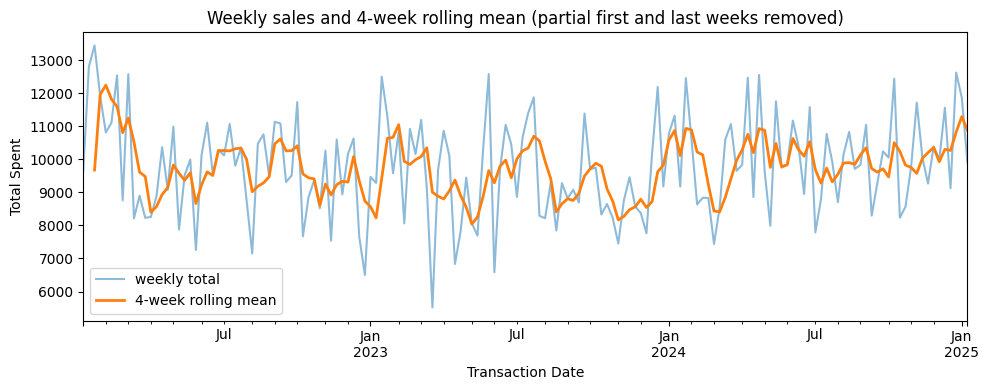

In [275]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
weekly.iloc[1:-1].plot(ax=ax, alpha=0.5, label="weekly total")
rolling_mean.iloc[1:-1].plot(ax=ax, linewidth=2, label="4-week rolling mean")
ax.set_title("Weekly sales and 4-week rolling mean (partial first and last weeks removed)")
ax.set_ylabel("Total Spent")
ax.legend()
plt.tight_layout()
plt.show()

*The pale line is noisy week to week; the thick line shows the underlying level. The first and last weeks are left out because they are partial.*

## 8.6 The challenge: sales trend analyst

*The manager asks for a time-based sales summary. Sections A to D are code; E is the interpretation.*

**Q187.** **A. Date preparation:** confirm the date column is datetime and count invalid dates. **B. Date components:** show `Year`, `Month`, `Day Name`.

In [276]:
print(sales["Transaction Date"].dtype, "| invalid dates:", sales["Transaction Date"].isna().sum())

sales["Year"] = sales["Transaction Date"].dt.year
sales["Month"] = sales["Transaction Date"].dt.month
sales["Day Name"] = sales["Transaction Date"].dt.day_name()
sales[["Transaction Date", "Year", "Month", "Day Name"]].head(3)

datetime64[us] | invalid dates: 0


,Transaction Date,Year,Month,Day Name
0,2024-04-08,2024,4,Monday
1,2023-07-23,2023,7,Sunday
2,2022-10-05,2022,10,Wednesday


**Q188.** **C. Weekly reporting** and **D. Rolling analysis:** build the weekly Series with the 4-week rolling mean and standard deviation, and summarise the full weeks only.

In [277]:
full_weeks = weekly.iloc[1:-1]                       # drop the partial first and last weeks
summary = pd.DataFrame({
    "weekly_sales": full_weeks,
    "rolling_mean_4w": full_weeks.rolling(4).mean(),
    "rolling_std_4w": full_weeks.rolling(4).std(),
})
print(summary.describe().round(1))

       weekly_sales  rolling_mean_4w  rolling_std_4w
count         158.0            155.0           155.0
mean         9762.0           9734.6          1300.5
std          1476.8            813.8           521.7
min          5519.0           8038.6           264.8
25%          8757.5           9223.5           903.8
50%          9702.8           9751.5          1296.4
75%         10803.4          10264.2          1651.3
max         13441.0          12241.6          2689.0


**Q189.** **E. Interpretation:** what do the weekly sales and rolling measures tell a manager? (The numbers below are computed from the data.)

In [278]:
from IPython.display import Markdown, display

mean_w, std_w = full_weeks.mean(), full_weeks.std()
best, worst = full_weeks.idxmax(), full_weeks.idxmin()
rm = summary["rolling_mean_4w"].dropna()

# Is there a long-run trend? Fit a straight line through the weekly totals.
slope, _ = np.polyfit(np.arange(len(full_weeks)), full_weeks.values, 1)
drift = slope * len(full_weeks) / mean_w          # total change over the period, as a share of the average week

if abs(drift) < 0.10:
    trend_txt = (f"A straight-line fit changes by only {drift:+.1%} over the whole period, so there is no clear long-run growth or decline. "
                 "The rolling mean still swings up and down; those look like short waves (seasons, promotions) rather than a sustained trend.")
else:
    trend_txt = f"A straight-line fit changes by {drift:+.1%} over the period, so sales are trending and that is worth investigating."

display(Markdown(f'''
1. A typical full week brings in about **{mean_w:,.0f}**, with week-to-week swings of roughly **{std_w:,.0f}** ({std_w/mean_w:.0%} of the average), so single weeks are noisy.
2. The strongest week ended **{best.date()}** at {full_weeks.max():,.0f} and the weakest ended **{worst.date()}** at {full_weeks.min():,.0f}. A manager should check for events (promotions, holidays, stock-outs) around those dates.
3. {trend_txt} The 4-week rolling mean ranges from {rm.min():,.0f} to {rm.max():,.0f}.
4. The rolling standard deviation tells us when sales are *volatile*: high values mean unpredictable weeks that make stock planning harder.
5. Caveat: the data contains missing `Total Spent` values that `sum` skips, so true sales are slightly higher than shown.
'''))


1. A typical full week brings in about **9,762**, with week-to-week swings of roughly **1,477** (15% of the average), so single weeks are noisy.
2. The strongest week ended **2022-01-23** at 13,441 and the weakest ended **2023-03-19** at 5,519. A manager should check for events (promotions, holidays, stock-outs) around those dates.
3. A straight-line fit changes by only +1.4% over the whole period, so there is no clear long-run growth or decline. The rolling mean still swings up and down; those look like short waves (seasons, promotions) rather than a sustained trend. The 4-week rolling mean ranges from 8,039 to 12,242.
4. The rolling standard deviation tells us when sales are *volatile*: high values mean unpredictable weeks that make stock planning harder.
5. Caveat: the data contains missing `Total Spent` values that `sum` skips, so true sales are slightly higher than shown.


*Business reading, not code description: the rolling mean answers "where is the level?" and the rolling standard deviation answers "how much can I trust next week to look like this one?".*

## 8.7 Optional homework, answered

**Q190.** **Homework 2 to 4:** total sales by year, by month (across all years), and by day of the week.

In [279]:
print("By year:\n", sales.groupby("Year")["Total Spent"].sum(), "\n")
print("By month (all years):\n", sales.groupby("Transaction Month")["Total Spent"].sum().round(1), "\n")
print("By day of week:\n", by_day)

By year:
 Year
2022    510329.5
2023    491312.0
2024    524881.0
2025     25548.5
Name: Total Spent, dtype: float64 

By month (all years):
 Transaction Month
1     174421.0
2     119685.0
3     122392.0
4     125618.5
5     124594.5
6     129771.0
7     131509.0
8     123287.5
9     129344.0
10    119413.5
11    122346.5
12    129688.5
Name: Total Spent, dtype: float64 

By day of week:
 Transaction Day
Monday       213090.5
Tuesday      219650.0
Wednesday    216982.0
Thursday     219380.5
Friday       232786.0
Saturday     224191.0
Sunday       225991.0
Name: Total Spent, dtype: float64


*2025 holds only 18 days of data, so its total is small because the data stops early, not because sales fell. Monthly totals here add all years together, so months that appear in 2025 (January) get four years of data while others get three, which flatters January.*

**Q191.** **Homework 8 and 9:** explain `resample()` vs `rolling()` and downsampling vs upsampling in your own words.

*`resample()` **changes the time frequency**: many daily rows become one weekly row, and each output row covers a separate period. `rolling()` **keeps every row** and calculates a statistic over a moving window of neighbouring observations, so the windows overlap.*

*Downsampling moves to a coarser frequency (daily → weekly) by summarising rows, so information is combined. Upsampling moves to a finer frequency (weekly → daily) by creating new time points, so any filled value is an assumption rather than a real measurement.*

## 8.8 Common beginner mistakes (from the trainer's list)

# PART 9 — COMMON BEGINNER MISTAKES

## Mistake 1 — Treating dates as ordinary strings

```python
sales["Transaction Date"].dt.year
```

will not work properly if the column has not been converted to datetime.

**Fix:**

```python
sales["Transaction Date"] = pd.to_datetime(sales["Transaction Date"])
```

---

## Mistake 2 — Using `resample()` without a time-aware index

`resample()` expects a time-based index or an appropriate time-based selection.

A common beginner workflow is:

```python
sales.set_index("Transaction Date")
```

but forgetting to save the result.

Remember:

```python
sales_time = sales.set_index("Transaction Date")
```

---

## Mistake 3 — Confusing `resample()` and `rolling()`

They are both time-related, but they do different jobs.

- `resample("W")` → creates **weekly groups**.
- `rolling(7)` → creates a **moving 7-observation window**.

A useful memory trick:

> **Resample changes the time frequency. Rolling moves a window across the data.**

---

## Mistake 4 — Thinking upsampling creates new information

Upsampling creates new time points. It does not create real measurements that were never recorded.

Any filling or interpolation step needs to make sense for the meaning of the data.

---

## Mistake 5 — Forgetting what the rolling window represents

```python
rolling(7)
```

means **7 observations**, not automatically "7 calendar days" in every situation.

If your data has missing dates or irregular observations, this distinction matters.

## 8.9 More time-series examples (several per task)

**Q192.** Prepare a date-indexed daily series that every example below can share.

In [280]:
sales = pd.read_csv(DATA_PATH)
sales["Transaction Date"] = pd.to_datetime(sales["Transaction Date"])
ts = sales.set_index("Transaction Date").sort_index()
daily = ts["Total Spent"].resample("D").sum()
print(daily.index.min().date(), "to", daily.index.max().date(), "| days:", len(daily))
daily.head()

2022-01-01 to 2025-01-18 | days: 1114


Transaction Date
2022-01-01    1642.5
2022-01-02    1135.5
2022-01-03     823.0
2022-01-04    1117.5
2022-01-05    2227.5
Freq: D, Name: Total Spent, dtype: float64

### Task: building and checking a calendar

**Q193.** Example 1: make date ranges with different frequencies. Example 2: check for missing days. Example 3: find the gap between consecutive dates.

In [281]:
print(pd.date_range("2024-01-01", periods=4, freq="D").strftime("%d %b").tolist())
print(pd.date_range("2024-01-31", periods=4, freq="ME").strftime("%b %d").tolist())
print(pd.date_range("2024-01-01", periods=3, freq="MS").strftime("%b %d").tolist())
print(pd.date_range("2024-01-01", periods=4, freq="W").strftime("%b %d").tolist())

full = pd.date_range(daily.index.min(), daily.index.max(), freq="D")
print("missing calendar days:", len(full.difference(daily.index)))

dates = pd.Series(sorted(sales["Transaction Date"].unique()))
print("largest gap between transaction dates:", dates.diff().max())

['01 Jan', '02 Jan', '03 Jan', '04 Jan']
['Jan 31', 'Feb 29', 'Mar 31', 'Apr 30']
['Jan 01', 'Feb 01', 'Mar 01']
['Jan 07', 'Jan 14', 'Jan 21', 'Jan 28']
missing calendar days: 0
largest gap between transaction dates: 1 days 00:00:00


*`D` is calendar day, `W` week (ending Sunday), `MS` month **start**, `ME` month **end**, `QE` quarter end, `YE` year end. Checking for missing days matters before a `rolling(28)`, because that window counts rows, not days. Here every day has at least one transaction.*

### Task: date arithmetic

**Q194.** Example 1: days since a customer's first purchase. Example 2: add or subtract time with offsets. Example 3: business days.

In [282]:
first = sales.groupby("Customer ID")["Transaction Date"].transform("min")
sales["days_since_first"] = (sales["Transaction Date"] - first).dt.days
print(sales.groupby("Customer ID")["days_since_first"].max().head(3))

d = pd.Timestamp("2024-01-31")
print(d + pd.Timedelta(days=45), "|", d + pd.DateOffset(months=1), "|", d - pd.DateOffset(years=1))
print(pd.Timestamp("2024-03-01").day_name(), "->", (pd.Timestamp("2024-03-01") + pd.offsets.BDay(3)).date())
sales = sales.drop(columns="days_since_first")

Customer ID
CUST_01    1113
CUST_02    1095
CUST_03    1104
Name: days_since_first, dtype: int64
2024-03-16 00:00:00 | 2024-02-29 00:00:00 | 2023-01-31 00:00:00
Friday -> 2024-03-06


*Subtracting two datetimes gives a `Timedelta`, and `.dt.days` turns it into a number. `DateOffset(months=1)` from 31 January lands on 29 February in a leap year: offsets are calendar-aware, unlike adding 30 days. `BDay` skips weekends.*

### Task: pulling more out of a date

**Q195.** Example 1: week number, day of year, quarter. Example 2: month start/end flags. Example 3: format a date as text.

In [283]:
x = sales["Transaction Date"].head(4)
print(pd.DataFrame({"date": x, "week": x.dt.isocalendar().week, "dayofyear": x.dt.dayofyear, "quarter": x.dt.quarter,
                    "month_start": x.dt.is_month_start, "month_end": x.dt.is_month_end,
                    "as_text": x.dt.strftime("%d %B %Y")}))
print(sales["Transaction Date"].dt.to_period("M").head(3).tolist())

        date  week  dayofyear  quarter  month_start  month_end  \
0 2024-04-08    15         99        2        False      False   
1 2023-07-23    29        204        3        False      False   
2 2022-10-05    40        278        4        False      False   
3 2022-05-07    18        127        2        False      False   

           as_text  
0    08 April 2024  
1     23 July 2023  
2  05 October 2022  
3      07 May 2022  
[Period('2024-04', 'M'), Period('2023-07', 'M'), Period('2022-10', 'M')]


### Task: slicing by time

**Q196.** Example 1: a whole year. Example 2: a range of months. Example 3: one specific day.

In [284]:
print("2023 total:", ts.loc["2023", "Total Spent"].sum())
print("Mar-May 2024 total:", ts.loc["2024-03":"2024-05", "Total Spent"].sum())
print("1 Jan 2022 rows:", len(ts.loc["2022-01-01"]))

2023 total: 491312.0
Mar-May 2024 total: 132899.0
1 Jan 2022 rows: 11


### Task: resampling with different summaries

**Q197.** Example 1: monthly sum and count. Example 2: weekly mean and max. Example 3: monthly by location (group + resample).

In [285]:
print(ts["Total Spent"].resample("ME").agg(["sum", "count"]).head(3))
print(ts["Total Spent"].resample("W").agg(["mean", "max"]).round(1).head(3))
by_loc = ts.groupby("Location")["Total Spent"].resample("ME").sum().unstack(0)
print(by_loc.head(3).round(0))

                      sum  count
Transaction Date                
2022-01-31        52911.5    368
2022-02-28        43325.5    313
2022-03-31        40996.0    339
                   mean    max
Transaction Date              
2022-01-02        146.2  380.0
2022-01-09        125.5  395.0
2022-01-16        140.7  380.0
Location          In-store   Online
Transaction Date                   
2022-01-31         25294.0  27618.0
2022-02-28         21581.0  21744.0
2022-03-31         20998.0  19998.0


**Q198.** Example 4: the busiest day each month; Example 5: a yearly summary; Example 6: months as period labels.

In [286]:
print(daily.resample("ME").agg(["idxmax", "max"]).head(3))
print(ts["Total Spent"].resample("YE").agg(["sum", "mean", "count"]).round(1))
print(ts["Total Spent"].resample("ME").sum().to_period("M").head(3))

                     idxmax     max
Transaction Date                   
2022-01-31       2022-01-26  2808.0
2022-02-28       2022-02-18  2634.5
2022-03-31       2022-03-02  2791.5
                       sum   mean  count
Transaction Date                        
2022-12-31        510329.5  130.0   3925
2023-12-31        491312.0  129.0   3808
2024-12-31        524881.0  130.0   4036
2025-12-31         25548.5  126.5    202
Transaction Date
2022-01    52911.5
2022-02    43325.5
2022-03    40996.0
Freq: M, Name: Total Spent, dtype: float64


### Task: changes over time (`shift`, `diff`, `pct_change`)

**Q199.** Example 1: month-on-month change. Example 2: percentage growth. Example 3: year-on-year growth (compare with 12 months earlier).

In [287]:
monthly = ts["Total Spent"].resample("ME").sum()
change = pd.DataFrame({"sales": monthly, "prev": monthly.shift(1), "change": monthly.diff(),
                       "mom_%": (monthly.pct_change() * 100).round(1),
                       "yoy_%": (monthly.pct_change(12) * 100).round(1)})
print(change.iloc[[0, 1, 12, 13, 24]])

                    sales     prev  change  mom_%  yoy_%
Transaction Date                                        
2022-01-31        52911.5      NaN     NaN    NaN    NaN
2022-02-28        43325.5  52911.5 -9586.0  -18.1    NaN
2023-01-31        48052.5  38201.0  9851.5   25.8   -9.2
2023-02-28        39214.5  48052.5 -8838.0  -18.4   -9.5
2024-01-31        47908.5  43021.0  4887.5   11.4   -0.3


*`shift(1)` slides values down one period so each row sees the previous month. `diff()` is `value - shift(1)`. `pct_change(12)` compares with 12 months earlier, which removes seasonality from the comparison. The first rows are `NaN` because there is nothing earlier to compare with.*

### Task: rolling windows, in more ways

**Q200.** Example 1: different window sizes. Example 2: `min_periods` and `center`. Example 3: time-based window and other statistics.

In [288]:
weekly = ts["Total Spent"].resample("W").sum().iloc[1:-1]

w = pd.DataFrame({"weekly": weekly,
                  "roll4": weekly.rolling(4).mean(),
                  "roll12": weekly.rolling(12).mean()}).round(0)
print(w.iloc[[0, 3, 11, 12]])

print(weekly.rolling(4, min_periods=1).mean().head(3).round(0).tolist(), "<- min_periods=1: no NaN at the start")
print(weekly.rolling(5, center=True).mean().iloc[[0, 2, 3]].round(0).tolist(), "<- centred window")

print(daily.rolling("28D").agg(["mean", "max", "min", "median"]).iloc[[0, 27, 100]].round(0))

                   weekly    roll4   roll12
Transaction Date                           
2022-01-09         9666.0      NaN      NaN
2022-01-30        11912.0  11956.0      NaN
2022-03-27         8230.0   9478.0  10745.0
2022-04-03         8254.0   8398.0  10628.0
[9666.0, 11235.0, 11970.0] <- min_periods=1: no NaN at the start
[nan, 11727.0, 12014.0] <- centred window
                    mean     max     min  median
Transaction Date                                
2022-01-01        1642.0  1642.0  1642.0  1642.0
2022-01-28        1693.0  2808.0   764.0  1594.0
2022-04-11        1220.0  2210.0   228.0  1243.0


*A wider window (12 weeks) is smoother but reacts more slowly than a narrow one (4 weeks). `min_periods=1` returns a value as soon as one observation exists, at the cost of noisier early values. `center=True` puts the window around each point rather than behind it, which is fine for describing the past but not for forecasting.*

**Q201.** Example 4: use rolling mean and standard deviation to flag unusual weeks. Example 5: expanding and exponentially weighted means.

In [289]:
r_mean, r_std = weekly.rolling(12).mean(), weekly.rolling(12).std()
z = (weekly - r_mean) / r_std
unusual = weekly[z.abs() > 2]
print("weeks more than 2 rolling std-devs from the 12-week mean:", len(unusual))
print(unusual.round(0).head(4))

print(pd.DataFrame({"weekly": weekly, "expanding": weekly.expanding().mean(), "ewm(span=8)": weekly.ewm(span=8).mean()}).iloc[[0, 10, 100]].round(0))

weeks more than 2 rolling std-devs from the 12-week mean: 3
Transaction Date
2023-03-19     5519.0
2023-12-24    12186.0
2024-10-13    12435.0
Name: Total Spent, dtype: float64
                  weekly  expanding  ewm(span=8)
Transaction Date                                
2022-01-09        9666.0     9666.0       9666.0
2022-03-20        8896.0    10974.0      10226.0
2023-12-10        7762.0     9578.0       8482.0


*The expanding mean uses **all** history to date; the exponentially weighted mean (`ewm`) gives recent weeks more weight than old ones, so it follows changes faster than a plain rolling mean.*

### Task: seasonality: when are sales high?

**Q202.** Example 1: average by weekday. Example 2: average by month. Example 3: a year × month table of daily averages.

In [290]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
by_weekday = daily.groupby(daily.index.day_name()).mean().reindex(order).round(0)
print(by_weekday)

by_month = daily.groupby(daily.index.month).mean().round(0)
print(by_month.to_dict())

heat = daily.groupby([daily.index.year, daily.index.month]).mean().unstack(0).round(0)
print(heat.head(4))

Transaction Date
Monday       1340.0
Tuesday      1381.0
Wednesday    1365.0
Thursday     1380.0
Friday       1464.0
Saturday     1401.0
Sunday       1421.0
Name: Total Spent, dtype: float64
{1: 1571.0, 2: 1408.0, 3: 1316.0, 4: 1396.0, 5: 1340.0, 6: 1442.0, 7: 1414.0, 8: 1326.0, 9: 1437.0, 10: 1284.0, 11: 1359.0, 12: 1394.0}
Transaction Date    2022    2023    2024    2025
Transaction Date                                
1                 1707.0  1550.0  1545.0  1419.0
2                 1547.0  1401.0  1281.0     NaN
3                 1322.0  1243.0  1383.0     NaN
4                 1348.0  1297.0  1542.0     NaN


*Averaging **daily** values avoids the month-length effect (31-day months would otherwise look bigger). The table has `NaN` for months with no data (2025 only has January).*

**Q203.** Plot the year × month averages as a heatmap, and the weekday profile as a bar chart.

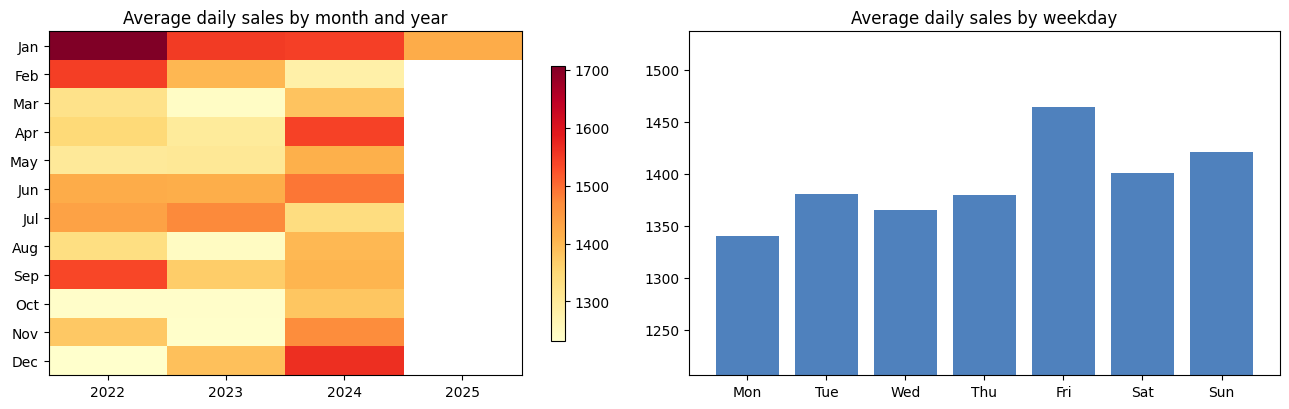

In [291]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
im = axes[0].imshow(heat.values, aspect="auto", cmap="YlOrRd")
axes[0].set_xticks(range(len(heat.columns)), heat.columns)
axes[0].set_yticks(range(12), ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
axes[0].set_title("Average daily sales by month and year")
fig.colorbar(im, ax=axes[0], shrink=0.8)

axes[1].bar([d[:3] for d in order], by_weekday.values, color="#4f81bd")
axes[1].set_ylim(by_weekday.min() * 0.9, by_weekday.max() * 1.05)
axes[1].set_title("Average daily sales by weekday")
plt.tight_layout(); plt.show()

*The bar chart's vertical axis starts above zero to show small differences, so read the heights with care: the weekday differences are modest. The heatmap shows which month-year cells were high (darker) or low.*

### Task: cumulative totals and progress

**Q204.** Example 1: cumulative sales in a year. Example 2: days to reach a target. Example 3: cumulative share.

In [292]:
y23 = ts.loc["2023", "Total Spent"].resample("D").sum()
cum = y23.cumsum()
target = 250_000
hit = cum[cum >= target]
print("2023 total:", round(cum.iloc[-1]), "| first day cumulative >= 250,000:", hit.index[0].date() if len(hit) else "not reached")
print((cum / cum.iloc[-1] * 100).iloc[[89, 179, 269]].round(1).tolist(), "<- % of year's sales by day 90, 180, 270")

2023 total: 491312 | first day cumulative >= 250,000: 2023-07-03
[25.6, 50.1, 75.1] <- % of year's sales by day 90, 180, 270


**Q205.** Example 4: fill a missing day properly with `reindex`, and compare `asfreq` choices.

In [293]:
partial = daily.iloc[:6].drop(daily.index[2])         # remove one day
print(partial.index.strftime("%d").tolist())
print(partial.reindex(pd.date_range(partial.index.min(), partial.index.max())).tolist())
print(partial.reindex(pd.date_range(partial.index.min(), partial.index.max()), fill_value=0).tolist())

['01', '02', '04', '05', '06']
[1642.5, 1135.5, nan, 1117.5, 2227.5, 763.5]
[1642.5, 1135.5, 0.0, 1117.5, 2227.5, 763.5]


*`reindex` against a full calendar shows the gaps as `NaN`; `fill_value=0` fills them. Zero means "no sales" which may be right for sales but wrong for a temperature, so choose the fill to match the meaning.*

---
# PART 9 — EXPLORATORY DATA ANALYSIS (EDA) AND VISUALISATION
*(new: Module 2 promises "statistical visualisation & EDA mastery")*

EDA means **looking at the data from several angles before concluding anything**: its size and types, the shape of each variable, relationships between variables, what is missing, and what looks odd. Charts make patterns visible that tables hide.

```text
1. First look      shape, types, summary statistics
2. One variable    distribution (histogram, box plot), counts (bar chart)
3. Two variables   comparisons by group, scatter, correlation
4. Missing data    how much, where, and is it random?
5. Summary         what did we learn, and what do we check next?
```

**Q206.** Load the data, convert the date, and import the plotting library.

In [294]:
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (8, 3.8), "axes.spines.top": False, "axes.spines.right": False})
sales = pd.read_csv(DATA_PATH)
sales["Transaction Date"] = pd.to_datetime(sales["Transaction Date"])
print(sales.shape)

(12575, 11)


## 9.1 The first look

**Q207.** Example 1: types and non-null counts. Example 2: summary statistics for numbers. Example 3: summary statistics for text columns.

In [295]:
sales.info()
print()
print(sales.select_dtypes(include="number").describe().round(2).T)
print()
print(sales[["Category", "Item", "Payment Method", "Location"]].describe().T)

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    12575 non-null  str           
 1   Customer ID       12575 non-null  str           
 2   Category          12575 non-null  str           
 3   Item              11362 non-null  str           
 4   Price Per Unit    11966 non-null  float64       
 5   Quantity          11971 non-null  float64       
 6   Total Spent       11971 non-null  float64       
 7   Payment Method    12575 non-null  str           
 8   Location          12575 non-null  str           
 9   Transaction Date  12575 non-null  datetime64[us]
 10  Discount Applied  8376 non-null   object        
dtypes: datetime64[us](1), float64(3), object(1), str(6)
memory usage: 1.1+ MB

                  count    mean    std  min   25%    50%    75%    max
Price Per Unit  11966.0   23.37  10.74  5.0  14.0

*`describe()` on numbers gives count, mean, spread and quartiles; on text it gives the count, the number of distinct values, the most common value (`top`) and how often it occurs (`freq`). Compare `count` with the number of rows to see missing data at a glance.*

**Q208.** Example 4: loop over categorical columns and print their value counts.

In [296]:
for col in ["Category", "Payment Method", "Location", "Discount Applied"]:
    print(f"--- {col}")
    print(sales[col].value_counts(dropna=False).to_string())

--- Category
Category
Furniture                             1591
Electric household essentials         1591
Food                                  1588
Milk Products                         1584
Butchers                              1568
Beverages                             1567
Computers and electric accessories    1558
Patisserie                            1528
--- Payment Method
Payment Method
Cash              4310
Digital Wallet    4144
Credit Card       4121
--- Location
Location
Online      6354
In-store    6221
--- Discount Applied
Discount Applied
True     4219
NaN      4199
False    4157


## 9.2 One variable at a time

**Q209.** Example 1: the shape of `Total Spent` with a histogram, and numbers that describe the shape.

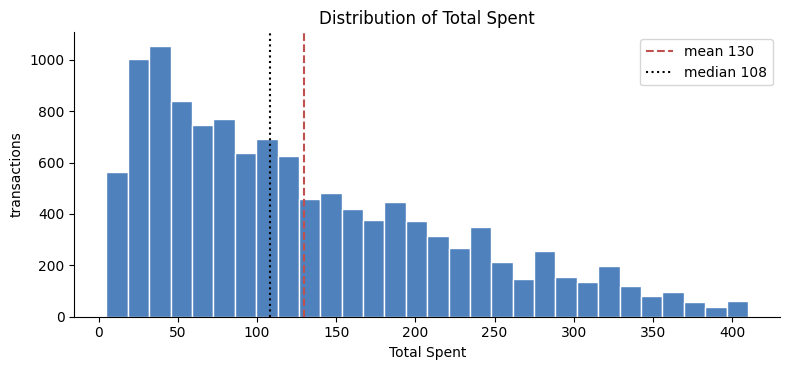

skew: 0.83 | kurtosis: -0.11


In [297]:
x = sales["Total Spent"].dropna()
fig, ax = plt.subplots()
ax.hist(x, bins=30, color="#4f81bd", edgecolor="white")
ax.axvline(x.mean(), color="#c0504d", linestyle="--", label=f"mean {x.mean():.0f}")
ax.axvline(x.median(), color="black", linestyle=":", label=f"median {x.median():.0f}")
ax.set_title("Distribution of Total Spent"); ax.set_xlabel("Total Spent"); ax.set_ylabel("transactions"); ax.legend()
plt.tight_layout(); plt.show()
print("skew:", round(x.skew(), 2), "| kurtosis:", round(x.kurt(), 2))

*Skew above 0 means a longer tail on the right: a few large transactions pull the **mean above the median**. A histogram's bins are a choice, so try a few bin counts before trusting a pattern.*

**Q210.** Example 2: the discrete `Quantity` as a bar chart of counts. Example 3: `Price Per Unit` histogram.

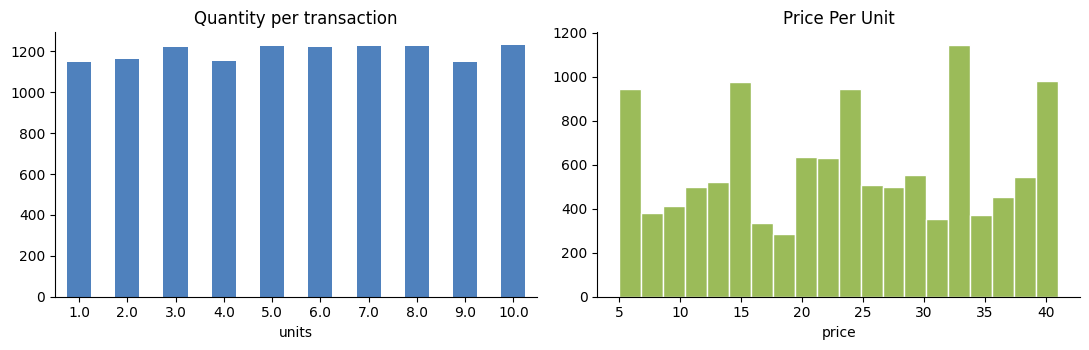

In [298]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
sales["Quantity"].value_counts().sort_index().plot.bar(ax=axes[0], color="#4f81bd", rot=0)
axes[0].set_title("Quantity per transaction"); axes[0].set_xlabel("units")
axes[1].hist(sales["Price Per Unit"].dropna(), bins=20, color="#9bbb59", edgecolor="white")
axes[1].set_title("Price Per Unit"); axes[1].set_xlabel("price")
plt.tight_layout(); plt.show()

*Quantity takes whole values from 1 to 10 so a bar chart of counts suits it better than a histogram. Roughly equal bars mean no quantity is much more common than the others.*

**Q211.** Example 4: a box plot to see median, spread and extremes. Example 5: compare the same measure across two groups with side-by-side box plots.

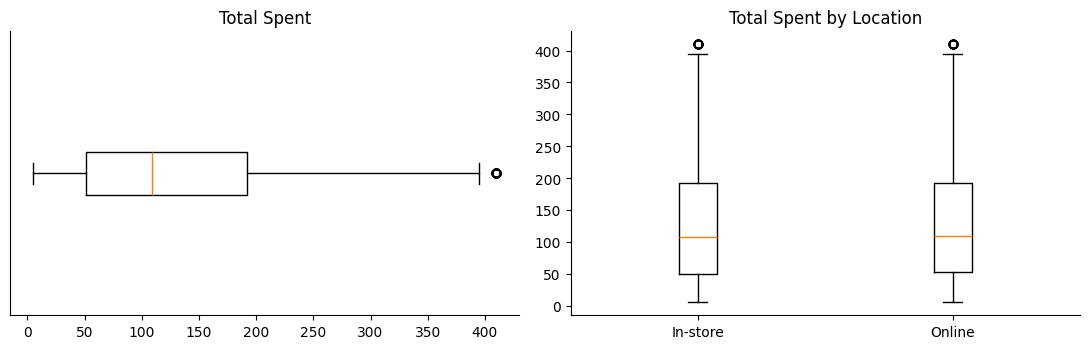

In [299]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].boxplot(x, vert=False); axes[0].set_title("Total Spent"); axes[0].set_yticks([])
groups = [g["Total Spent"].dropna() for _, g in sales.groupby("Location")]
axes[1].boxplot(groups, tick_labels=sorted(sales["Location"].unique())); axes[1].set_title("Total Spent by Location")
plt.tight_layout(); plt.show()

*The box spans the middle 50% of values (Q1 to Q3), the line inside is the median, and the whiskers reach the furthest points within 1.5 × IQR. Points beyond the whiskers would be drawn individually. Two nearly identical boxes mean the groups spend alike.*

## 9.3 Categorical variables

**Q212.** Example 1: revenue per category as a sorted horizontal bar chart. Example 2: transaction counts. Example 3: share of payment methods.

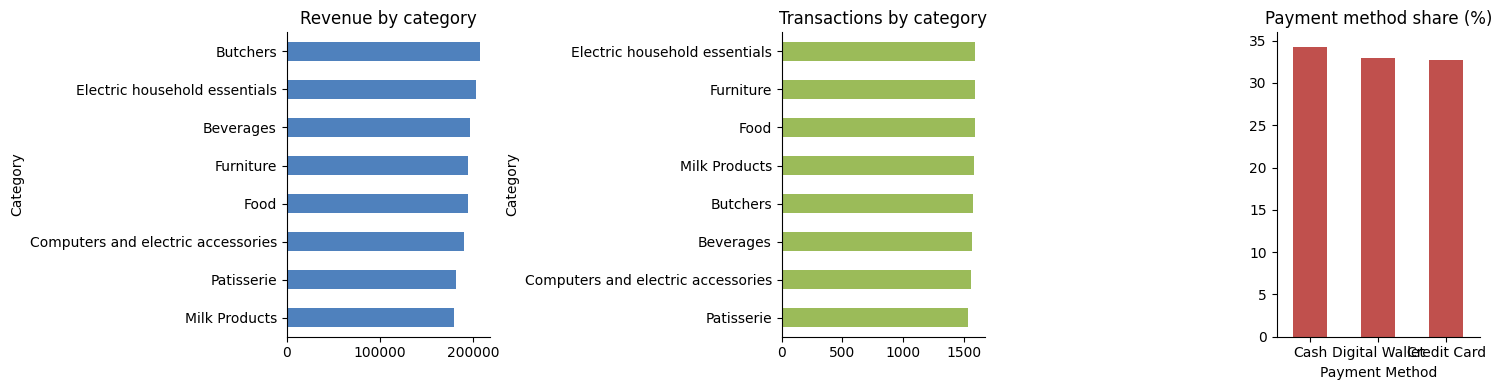

In [300]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sales.groupby("Category")["Total Spent"].sum().sort_values().plot.barh(ax=axes[0], color="#4f81bd")
axes[0].set_title("Revenue by category")
sales["Category"].value_counts().sort_values().plot.barh(ax=axes[1], color="#9bbb59")
axes[1].set_title("Transactions by category")
(sales["Payment Method"].value_counts(normalize=True) * 100).plot.bar(ax=axes[2], color="#c0504d", rot=0)
axes[2].set_title("Payment method share (%)")
plt.tight_layout(); plt.show()

*Sorting bars makes ranking easy to read. Revenue and transaction counts can tell different stories: a category can have many small sales or few large ones. Bar charts start at zero so the heights compare honestly.*

**Q213.** Example 4: a stacked bar showing payment mix inside each location. Example 5: the same as grouped bars.

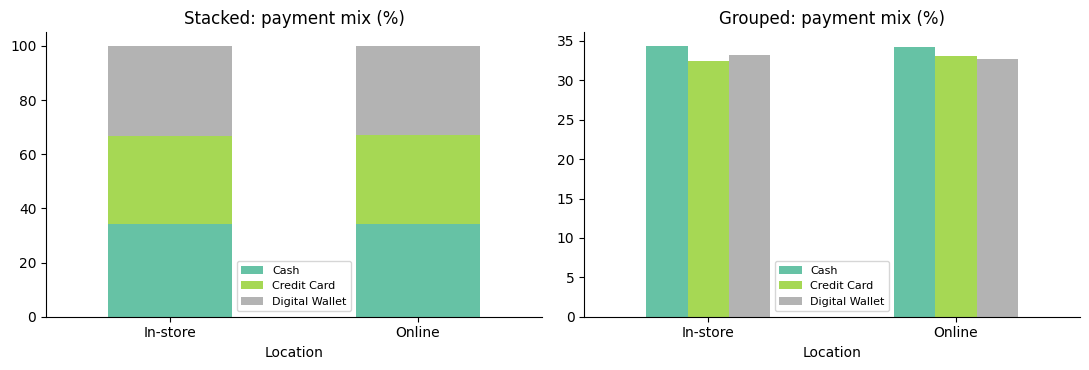

In [301]:
mix = pd.crosstab(sales["Location"], sales["Payment Method"], normalize="index") * 100
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
mix.plot.bar(stacked=True, ax=axes[0], rot=0, colormap="Set2"); axes[0].set_title("Stacked: payment mix (%)"); axes[0].legend(fontsize=8)
mix.plot.bar(ax=axes[1], rot=0, colormap="Set2"); axes[1].set_title("Grouped: payment mix (%)"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 9.4 Two or more variables

**Q214.** Example 1: scatter plot of `Price Per Unit` against `Total Spent`, coloured by quantity. Example 2: the correlation matrix.

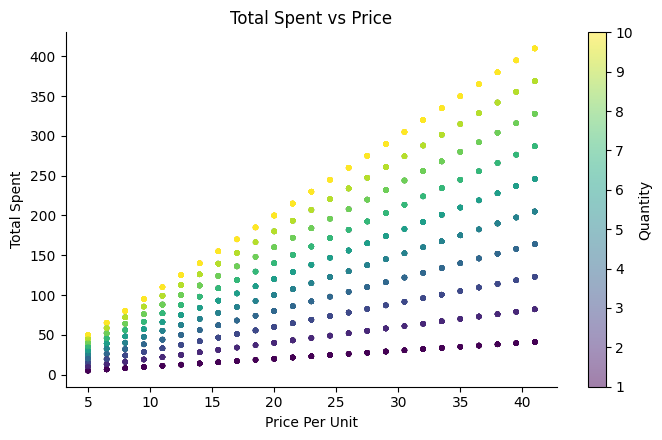

                Price Per Unit  Quantity  Total Spent
Price Per Unit            1.00      0.01         0.63
Quantity                  0.01      1.00         0.71
Total Spent               0.63      0.71         1.00


In [302]:
d = sales.dropna(subset=["Price Per Unit", "Quantity", "Total Spent"])
fig, ax = plt.subplots(figsize=(7, 4.5))
sc = ax.scatter(d["Price Per Unit"], d["Total Spent"], c=d["Quantity"], cmap="viridis", s=8, alpha=0.5)
fig.colorbar(sc, label="Quantity"); ax.set_xlabel("Price Per Unit"); ax.set_ylabel("Total Spent"); ax.set_title("Total Spent vs Price")
plt.tight_layout(); plt.show()

corr = d[["Price Per Unit", "Quantity", "Total Spent"]].corr().round(2)
print(corr)

*The fan shape appears because `Total Spent = Price × Quantity`: at a given price, the total ranges from one unit up to ten. Each colour band is a different quantity. Correlation measures **linear** association between −1 and +1; here `Total Spent` correlates positively with both inputs, and price and quantity are essentially unrelated to each other, as they were generated independently.*

**Q215.** Example 3: a correlation heatmap. Example 4: relationship between a category and spending with box plots.

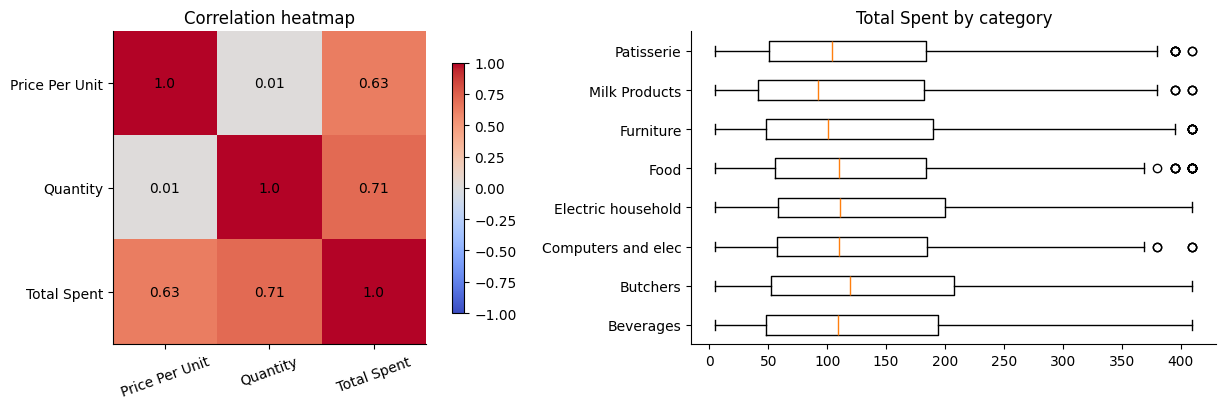

In [303]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
im = axes[0].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
axes[0].set_xticks(range(3), corr.columns, rotation=20); axes[0].set_yticks(range(3), corr.columns)
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, corr.iloc[i, j], ha="center", va="center")
axes[0].set_title("Correlation heatmap"); fig.colorbar(im, ax=axes[0], shrink=0.8)

cats = sorted(sales["Category"].unique())
axes[1].boxplot([sales.loc[sales["Category"] == c, "Total Spent"].dropna() for c in cats], vert=False)
axes[1].set_yticks(range(1, len(cats) + 1), [c[:18] for c in cats]); axes[1].set_title("Total Spent by category")
plt.tight_layout(); plt.show()

**Q216.** Example 5: average spend by quantity (a line), and Example 6: a spend-band × location heat table.

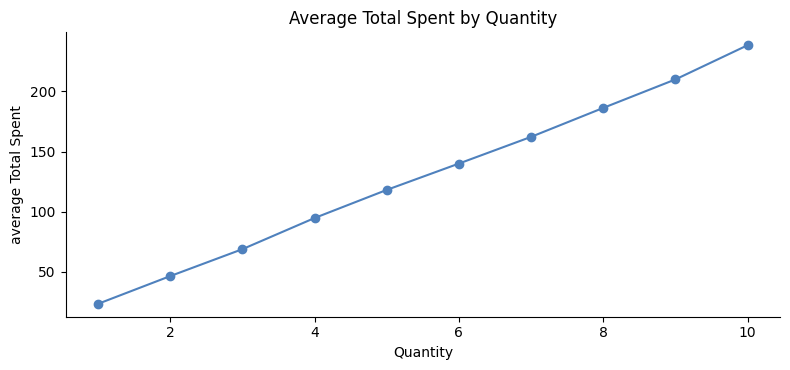

Location     In-store  Online
Total Spent                  
Low              48.2    47.2
Medium           39.0    39.6
High             12.8    13.2


In [304]:
fig, ax = plt.subplots()
sales.groupby("Quantity")["Total Spent"].mean().plot(marker="o", ax=ax, color="#4f81bd")
ax.set_title("Average Total Spent by Quantity"); ax.set_ylabel("average Total Spent")
plt.tight_layout(); plt.show()

band = pd.cut(sales["Total Spent"], [0, 100, 250, 500], labels=["Low", "Medium", "High"])
print((pd.crosstab(band, sales["Location"], normalize="columns") * 100).round(1))

*Average spend rises steadily with quantity, as expected. The last table shows that the spend-band mix is nearly the same online and in-store: the **location does not change how much people spend**, which is itself a finding.*

## 9.5 Missing data: how much, where, and is it random?

**Q217.** Example 1: a bar chart of the share missing per column. Example 2: which combinations of missing values occur together?

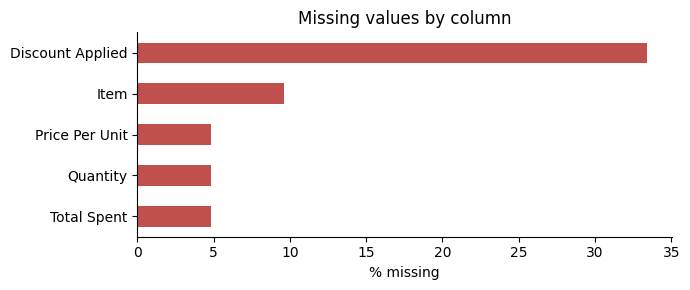

Total Spent  Quantity  Price Per Unit  Item   Discount Applied
False        False     False           False  False               7579
                                              True                3783
                       True            True   False                404
True         True      False           True   False                393
                                              True                 211
False        False     True            True   True                 205
Name: rows, dtype: int64


In [305]:
miss_pct = (sales.isna().mean() * 100).sort_values()
miss_pct = miss_pct[miss_pct > 0]
ax = miss_pct.plot.barh(color="#c0504d", figsize=(7, 3)); ax.set_xlabel("% missing"); ax.set_title("Missing values by column")
plt.tight_layout(); plt.show()

pattern = sales.isna().loc[:, miss_pct.index].value_counts().rename("rows")
print(pattern.head(8))

*Looking at **combinations** matters. `Quantity` and `Total Spent` are missing on exactly the same 604 rows, and `Price Per Unit` is only ever missing on rows where `Item` is also missing (609 rows). So every row with a missing `Item` has a second gap beside it, which is why the recovery rules in Part 4.1 work: the price can be rebuilt from the total and quantity, and the item from the category and price.*

**Q218.** Example 3: is the missingness related to a group? Compare the share of missing `Item` by category and by location.

In [306]:
print((sales["Item"].isna().groupby(sales["Category"]).mean() * 100).round(1))
print((sales["Item"].isna().groupby(sales["Location"]).mean() * 100).round(1))

Category
Beverages                              8.9
Butchers                               9.4
Computers and electric accessories    10.3
Electric household essentials          9.7
Food                                  10.2
Furniture                              8.2
Milk Products                         10.0
Patisserie                            10.4
Name: Item, dtype: float64
Location
In-store    9.7
Online      9.6
Name: Item, dtype: float64


*If missingness differs a lot between groups, the gaps are **not random** and simply dropping rows could bias results. Similar percentages everywhere suggest the gaps are scattered randomly.*

## 9.6 Summarise what you found: a reusable EDA function

**Q219.** Wrap the first-look checks into one function and run it on the retail data and on a different DataFrame.

In [307]:
def eda_summary(df, target=None):
    print(f"Rows: {len(df):,} | Columns: {df.shape[1]} | Duplicate rows: {df.duplicated().sum()}")
    miss = df.isna().mean().mul(100).round(1)
    print("Columns with missing values:", {c: f"{v}%" for c, v in miss[miss > 0].items()} or "none")
    num = df.select_dtypes(include="number")
    if target in num:
        print(f"Correlation with {target}:", num.corr()[target].drop(target).round(2).to_dict())
    low_card = [c for c in df.columns if df[c].nunique() <= 10]
    print("Low-cardinality columns (good for grouping):", low_card)

eda_summary(sales, target="Total Spent")
print()
eda_summary(pd.DataFrame({"score": [50, 60, 70, np.nan], "hours": [2, 3, 5, 6], "group": list("aabb")}), target="score")

Rows: 12,575 | Columns: 11 | Duplicate rows: 0
Columns with missing values: {'Item': '9.6%', 'Price Per Unit': '4.8%', 'Quantity': '4.8%', 'Total Spent': '4.8%', 'Discount Applied': '33.4%'}
Correlation with Total Spent: {'Price Per Unit': 0.63, 'Quantity': 0.71}
Low-cardinality columns (good for grouping): ['Category', 'Quantity', 'Payment Method', 'Location', 'Discount Applied']

Rows: 4 | Columns: 3 | Duplicate rows: 0
Columns with missing values: {'score': '25.0%'}
Correlation with score: {'hours': 0.98}
Low-cardinality columns (good for grouping): ['score', 'hours', 'group']


*The same function worked on two completely different tables. Writing reusable helpers like this is how EDA becomes a repeatable habit instead of a one-off.*

**Q220.** **EDA findings for the retail data** (computed from the data, not typed in).

In [308]:
from IPython.display import Markdown, display

tot = sales["Total Spent"].dropna()
cat_rev = sales.groupby("Category")["Total Spent"].sum()
loc_gap = abs(sales.groupby("Location")["Total Spent"].mean().diff().iloc[-1]) / tot.mean()
display(Markdown(f'''
1. **Size and quality:** {len(sales):,} rows, no duplicates; {int(sales.isna().any(axis=1).sum()):,} rows ({sales.isna().any(axis=1).mean():.0%}) have at least one missing value, mostly the discount flag.
2. **Distribution:** spending is right-skewed (skew {tot.skew():.2f}): median {tot.median():.0f}, mean {tot.mean():.0f}; the largest transactions reach {tot.max():.0f}.
3. **Categories:** revenue is spread evenly; the top category ({cat_rev.idxmax()}) holds {cat_rev.max() / cat_rev.sum():.1%} and the bottom ({cat_rev.idxmin()}) {cat_rev.min() / cat_rev.sum():.1%}.
4. **Location:** average spend differs by only {loc_gap:.1%} between online and in-store.
5. **Next checks:** test whether the discount flag changes spending, and look at weekly patterns (Part 8).
'''))


1. **Size and quality:** 12,575 rows, no duplicates; 4,996 rows (40%) have at least one missing value, mostly the discount flag.
2. **Distribution:** spending is right-skewed (skew 0.83): median 108, mean 130; the largest transactions reach 410.
3. **Categories:** revenue is spread evenly; the top category (Butchers) holds 13.4% and the bottom (Milk Products) 11.6%.
4. **Location:** average spend differs by only 1.2% between online and in-store.
5. **Next checks:** test whether the discount flag changes spending, and look at weekly patterns (Part 8).


---
# PART 10 — CAPSTONE MINI-PROJECT: RETAIL PERFORMANCE REVIEW

Bring everything together in one repeatable workflow. **Brief:** the manager asks for a performance review of three years of retail sales, built from a messy file, with clear numbers and honest limits.

```text
LOAD → AUDIT → CLEAN / RECOVER → KPIs → BREAKDOWNS → CUSTOMERS → TIME → FINDINGS
```

### Step 1 — Load and audit

In [309]:
raw = pd.read_csv(DATA_PATH)
audit = pd.DataFrame({"dtype": raw.dtypes.astype(str), "missing": raw.isna().sum(), "missing_%": (raw.isna().mean() * 100).round(1), "unique": raw.nunique()})
print("rows:", len(raw), "| duplicate rows:", raw.duplicated().sum(), "| duplicate transaction ids:", raw["Transaction ID"].duplicated().sum())
audit

rows: 12575 | duplicate rows: 0 | duplicate transaction ids: 0


,dtype,missing,missing_%,unique
Transaction ID,str,0,0.0,12575
Customer ID,str,0,0.0,25
Category,str,0,0.0,8
Item,str,1213,9.6,200
Price Per Unit,float64,609,4.8,25
Quantity,float64,604,4.8,10
Total Spent,float64,604,4.8,227
Payment Method,str,0,0.0,3
Location,str,0,0.0,2
Transaction Date,str,0,0.0,1114


### Step 2 — Clean and recover (a reusable function)

In [310]:
def clean_retail(df):
    out = df.copy()
    out["Transaction Date"] = pd.to_datetime(out["Transaction Date"], errors="coerce")
    for col in ["Category", "Payment Method", "Location"]:
        out[col] = out[col].str.strip()

    # rebuild numbers from Price x Quantity = Total
    out["Price Per Unit"] = out["Price Per Unit"].fillna(out["Total Spent"] / out["Quantity"])
    out["Quantity"] = out["Quantity"].fillna(out["Total Spent"] / out["Price Per Unit"])
    out["Total Spent"] = out["Total Spent"].fillna(out["Price Per Unit"] * out["Quantity"])

    # rebuild Item from (Category, Price Per Unit)
    lookup = (df.dropna(subset=["Item", "Price Per Unit"]).drop_duplicates(["Category", "Price Per Unit"])
                [["Category", "Price Per Unit", "Item"]].rename(columns={"Item": "Item_lookup"}))
    out = out.merge(lookup, on=["Category", "Price Per Unit"], how="left", validate="many_to_one")
    out["Item"] = out["Item"].fillna(out["Item_lookup"])
    out = out.drop(columns="Item_lookup")

    out["Discount Applied"] = out["Discount Applied"].map({True: "Yes", False: "No"}).fillna("Not recorded")
    return out

clean = clean_retail(raw)
cols = ["Item", "Price Per Unit", "Quantity", "Total Spent"]
pd.DataFrame({"before": raw[cols].isna().sum(), "after": clean[cols].isna().sum()})

,before,after
Item,1213,0
Price Per Unit,609,0
Quantity,604,604
Total Spent,604,604


In [311]:
# Validation: nothing lost, nothing contradicted
assert len(clean) == len(raw)
ok = clean.dropna(subset=["Price Per Unit", "Quantity", "Total Spent"])
assert ((ok["Price Per Unit"] * ok["Quantity"] - ok["Total Spent"]).abs() < 0.01).all()
analysis = clean.dropna(subset=["Total Spent"]).copy()
print("rows used for revenue analysis:", len(analysis), "of", len(clean))

rows used for revenue analysis: 11971 of 12575


### Step 3 — KPIs and breakdowns

In [312]:
kpi = pd.Series({"Revenue": analysis["Total Spent"].sum(), "Transactions": len(analysis), "Average sale": analysis["Total Spent"].mean(),
                 "Customers": analysis["Customer ID"].nunique(), "Units sold": analysis["Quantity"].sum()}).round(1)
print(kpi.to_string())

by_cat = (analysis.groupby("Category").agg(revenue=("Total Spent", "sum"), avg_sale=("Total Spent", "mean"), units=("Quantity", "sum"))
          .assign(share=lambda d: (d["revenue"] / d["revenue"].sum() * 100).round(1)).sort_values("revenue", ascending=False).round(1))
by_cat

Revenue         1552071.0
Transactions      11971.0
Average sale        129.7
Customers            25.0
Units sold        66276.0


,revenue,avg_sale,units,share
Category,,,,
Butchers,208118.0,139.1,8206.0,13.4
Electric household essentials,203813.5,134.4,8309.0,13.1
Beverages,197047.5,131.7,8358.0,12.7
Furniture,195310.0,128.1,8462.0,12.6
Food,194812.0,129.3,8387.0,12.6
Computers and electric accessories,190692.5,129.1,8272.0,12.3
Patisserie,182165.5,126.4,7943.0,11.7
Milk Products,180112.0,119.0,8339.0,11.6


In [313]:
pivot = pd.pivot_table(analysis, values="Total Spent", index="Category", columns=["Location"], aggfunc="sum", margins=True, margins_name="Total").round(0)
mix = (pd.crosstab(analysis["Payment Method"], analysis["Location"], normalize="columns") * 100).round(1)
display(pivot); display(mix)

Location,In-store,Online,Total
Category,,,
Beverages,98026.0,99022.0,197048.0
Butchers,101777.0,106341.0,208118.0
Computers and electric accessories,87324.0,103369.0,190692.0
Electric household essentials,97778.0,106035.0,203814.0
Food,95926.0,98886.0,194812.0
Furniture,99611.0,95699.0,195310.0
Milk Products,88813.0,91299.0,180112.0
Patisserie,91415.0,90750.0,182166.0
Total,760670.0,791401.0,1552071.0


Location,In-store,Online
Payment Method,,
Cash,34.4,34.1
Credit Card,32.5,33.1
Digital Wallet,33.1,32.8


### Step 4 — Customers: segment and join back

In [314]:
cust = analysis.groupby("Customer ID").agg(total=("Total Spent", "sum"), visits=("Transaction ID", "count")).reset_index()
cust["segment"] = pd.qcut(cust["total"], 3, labels=["Low", "Mid", "High"])
tagged = analysis.merge(cust[["Customer ID", "segment"]], on="Customer ID", how="left", validate="many_to_one")
assert len(tagged) == len(analysis) and tagged["segment"].notna().all()
tagged.groupby("segment", observed=True).agg(customers=("Customer ID", "nunique"), revenue=("Total Spent", "sum"), avg_sale=("Total Spent", "mean")).round(1)

,customers,revenue,avg_sale
segment,,,
Low,9,534298.5,127.5
Mid,8,493607.0,130.8
High,8,524165.5,130.8


### Step 5 — Time: weekly trend, rolling view and month-on-month

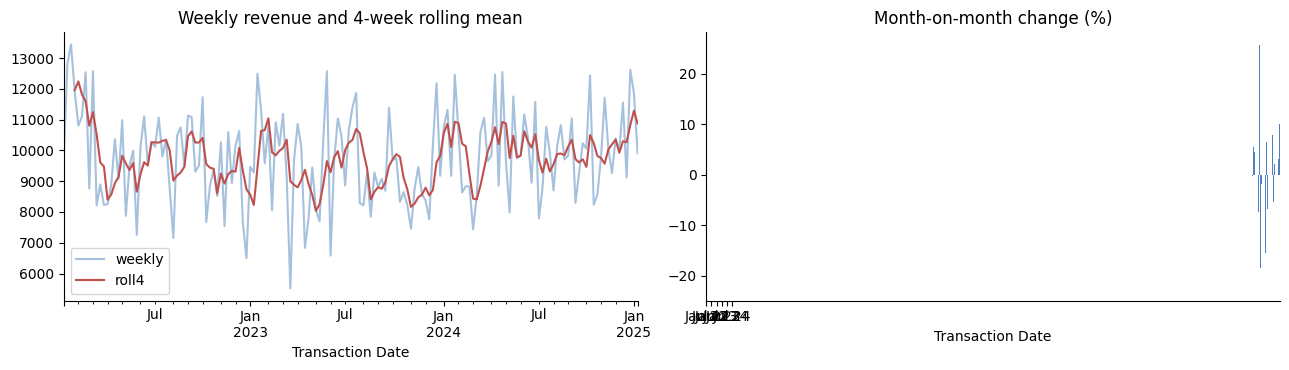

In [315]:
series = analysis.set_index("Transaction Date").sort_index()["Total Spent"]
weekly = series.resample("W").sum().iloc[1:-1]                    # full weeks only
monthly = series.resample("ME").sum().iloc[:-1]                   # drop the partial last month
roll = pd.DataFrame({"weekly": weekly, "roll4": weekly.rolling(4).mean(), "std4": weekly.rolling(4).std()})

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
roll[["weekly", "roll4"]].plot(ax=axes[0], color=["#a6c1de", "#c0504d"]); axes[0].set_title("Weekly revenue and 4-week rolling mean")
(monthly.pct_change() * 100).plot.bar(ax=axes[1], color="#4f81bd"); axes[1].set_title("Month-on-month change (%)")
axes[1].set_xticks(range(0, len(monthly), 6), [d.strftime("%b %y") for d in monthly.index[::6]], rotation=0)
plt.tight_layout(); plt.show()

### Step 6 — Findings (computed)

In [316]:
slope, _ = np.polyfit(np.arange(len(weekly)), weekly.values, 1)
drift = slope * len(weekly) / weekly.mean()
best_m = series.resample("ME").sum().iloc[:-1].groupby(lambda d: d.month).mean().idxmax()
miss_total = raw["Total Spent"].isna().sum()

display(Markdown(f'''
**Retail performance review: summary for the manager**

1. **Scale:** revenue of {kpi["Revenue"]:,.0f} from {int(kpi["Transactions"]):,} transactions across {int(kpi["Customers"])} customers (average sale {kpi["Average sale"]:,.1f}).
2. **Mix:** the top category is {by_cat.index[0]} ({by_cat["share"].iloc[0]}%); the smallest is {by_cat.index[-1]} ({by_cat["share"].iloc[-1]}%): a balanced portfolio.
3. **Channel:** online {pivot.loc["Total", "Online"] / pivot.loc["Total", "Total"]:.1%} of revenue, in-store {pivot.loc["Total", "In-store"] / pivot.loc["Total", "Total"]:.1%}.
4. **Trend:** a fitted line moves {drift:+.1%} over the period, so weekly sales are essentially flat; the typical week varies by {weekly.std() / weekly.mean():.0%} around its average.
5. **Seasonality:** month {best_m} (January = 1) has the highest average monthly revenue.
6. **Limits:** {miss_total:,} transactions have no total and are excluded, so revenue is slightly understated; the file has only {int(kpi["Customers"])} customers and no cost data, so we cannot comment on profit.
'''))


**Retail performance review: summary for the manager**

1. **Scale:** revenue of 1,552,071 from 11,971 transactions across 25 customers (average sale 129.7).
2. **Mix:** the top category is Butchers (13.4%); the smallest is Milk Products (11.6%): a balanced portfolio.
3. **Channel:** online 51.0% of revenue, in-store 49.0%.
4. **Trend:** a fitted line moves +1.4% over the period, so weekly sales are essentially flat; the typical week varies by 15% around its average.
5. **Seasonality:** month 1 (January = 1) has the highest average monthly revenue.
6. **Limits:** 604 transactions have no total and are excluded, so revenue is slightly understated; the file has only 25 customers and no cost data, so we cannot comment on profit.


*What the capstone shows: every step is a function or a check you can rerun on next month's file. That is the difference between analysing data once and having a process.*

---
# PART 11 — EXTRA PRACTICE ON A NEW DATASET

Everything so far used the retail data. Here is a **different dataset**, a small Kenyan supermarket generated with a fixed seed, so you meet the same skills on new ground. Solved examples come first; **Your turn** cells at the end are blank for independent practice.

## 11.1 Build the mini-market data

**Q221.** Generate 900 sales rows for four branches and six products, plus a small branch information table.

In [317]:
rng = np.random.default_rng(2024)

products = pd.DataFrame({
    "product": ["Unga (2kg)", "Milk (500ml)", "Sugar (1kg)", "Rice (1kg)", "Cooking Oil (1L)", "Bread"],
    "unit_price": [190, 60, 165, 210, 320, 65],
})
branches = ["Nairobi CBD", "Westlands", "Kisumu", "Mombasa"]

n = 900
mm = pd.DataFrame({
    "date": pd.to_datetime("2024-01-01") + pd.to_timedelta(rng.integers(0, 182, n), unit="D"),
    "branch": rng.choice(branches, n),
    "product": rng.choice(products["product"], n),
    "units": rng.integers(1, 12, n),
    "payment": rng.choice(["M-Pesa", "Cash", "Card"], n, p=[0.55, 0.30, 0.15]),
})
mm = mm.merge(products, on="product")
mm["revenue"] = mm["units"] * mm["unit_price"]

branch_info = pd.DataFrame({
    "branch": ["Nairobi CBD", "Westlands", "Kisumu", "Nakuru"],
    "manager": ["Amina", "Brian", "Carol", "Dennis"],
})
print(mm.shape)
mm.head()

(900, 7)


,date,branch,product,units,payment,unit_price,revenue
0,2024-02-13,Kisumu,Milk (500ml),10,Cash,60,600
1,2024-05-03,Westlands,Sugar (1kg),4,Cash,165,660
2,2024-01-17,Nairobi CBD,Cooking Oil (1L),4,Card,320,1280
3,2024-02-09,Mombasa,Cooking Oil (1L),2,M-Pesa,320,640
4,2024-02-27,Nairobi CBD,Bread,4,M-Pesa,65,260


*The random generator has a fixed seed, so everyone gets identical data. `Nakuru` appears in `branch_info` but not in the sales, and `Mombasa` appears in the sales but not in `branch_info`. That mismatch is deliberate; it makes the join exercise interesting.*

## 11.2 Inspect and filter

**Q222.** Inspect the data, then filter M-Pesa sales of 8 or more units.

In [318]:
mm.info()
print()
print("missing values:", mm.isna().sum().sum())
mpesa_big = mm[(mm["payment"] == "M-Pesa") & (mm["units"] >= 8)]
print("M-Pesa sales with 8+ units:", mpesa_big.shape[0])

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        900 non-null    datetime64[us]
 1   branch      900 non-null    str           
 2   product     900 non-null    str           
 3   units       900 non-null    int64         
 4   payment     900 non-null    str           
 5   unit_price  900 non-null    int64         
 6   revenue     900 non-null    int64         
dtypes: datetime64[us](1), int64(3), str(3)
memory usage: 49.3 KB

missing values: 0
M-Pesa sales with 8+ units: 194


*No missing values in this clean data. The filter follows the same pattern as Part 3: each condition in parentheses, joined with `&`.*

## 11.3 Aggregate

**Q223.** Total revenue per product, sorted, and the best-selling product.

In [319]:
rev = mm.groupby("product")["revenue"].sum().sort_values(ascending=False)
print(rev)
print("best product:", rev.idxmax(), f"(Ksh {rev.max():,})")

product
Cooking Oil (1L)    277760
Rice (1kg)          185430
Sugar (1kg)         165330
Unga (2kg)          148580
Bread                72670
Milk (500ml)         48300
Name: revenue, dtype: int64
best product: Cooking Oil (1L) (Ksh 277,760)


**Q224.** Named aggregation per branch: revenue, average sale, number of sales, distinct products.

In [320]:
branch_summary = (
    mm.groupby("branch")
    .agg(revenue=("revenue", "sum"),
         avg_sale=("revenue", "mean"),
         sales=("revenue", "count"),
         products=("product", "nunique"))
    .round(0)
    .reset_index()
)
branch_summary

,branch,revenue,avg_sale,sales,products
0,Kisumu,219625,968.0,227,6
1,Mombasa,256990,1016.0,253,6
2,Nairobi CBD,213720,989.0,216,6
3,Westlands,207735,1018.0,204,6


**Q225.** Use `transform` to show each row's revenue as a percentage of its branch's total.

In [321]:
mm["pct_of_branch"] = (mm["revenue"] / mm.groupby("branch")["revenue"].transform("sum") * 100).round(3)
print(mm.groupby("branch")["pct_of_branch"].sum().round(1))     # each branch should add to 100
mm[["branch", "product", "revenue", "pct_of_branch"]].head()

branch
Kisumu         100.0
Mombasa        100.0
Nairobi CBD    100.0
Westlands      100.0
Name: pct_of_branch, dtype: float64


,branch,product,revenue,pct_of_branch
0,Kisumu,Milk (500ml),600,0.273
1,Westlands,Sugar (1kg),660,0.318
2,Nairobi CBD,Cooking Oil (1L),1280,0.599
3,Mombasa,Cooking Oil (1L),640,0.249
4,Nairobi CBD,Bread,260,0.122


*The check works: each branch's percentages sum to 100. Whenever you build a share, add up the shares to confirm.*

## 11.4 Reshape

**Q226.** Pivot: revenue by product (rows) and branch (columns), with totals.

In [322]:
pt = pd.pivot_table(mm, values="revenue", index="product", columns="branch", aggfunc="sum", margins=True, margins_name="Total")
pt

branch,Kisumu,Mombasa,Nairobi CBD,Westlands,Total
product,,,,,
Bread,17680,20995,19435,14560,72670
Cooking Oil (1L),65600,90240,61120,60800,277760
Milk (500ml),10620,15480,11520,10680,48300
Rice (1kg),44100,46410,49980,44940,185430
Sugar (1kg),38115,43395,42405,41415,165330
Unga (2kg),43510,40470,29260,35340,148580
Total,219625,256990,213720,207735,898070


**Q227.** Crosstab: within each branch, what share of sales used each payment method?

In [323]:
(pd.crosstab(mm["branch"], mm["payment"], normalize="index") * 100).round(1)

payment,Card,Cash,M-Pesa
branch,,,
Kisumu,15.4,32.2,52.4
Mombasa,14.6,30.0,55.3
Nairobi CBD,15.3,25.9,58.8
Westlands,14.7,26.0,59.3


**Q228.** Melt the branch summary so it has one row per branch and metric.

In [324]:
branch_summary.melt(id_vars="branch", var_name="metric", value_name="value")

,branch,metric,value
0,Kisumu,revenue,219625.0
1,Mombasa,revenue,256990.0
2,Nairobi CBD,revenue,213720.0
3,Westlands,revenue,207735.0
4,Kisumu,avg_sale,968.0
5,Mombasa,avg_sale,1016.0
6,Nairobi CBD,avg_sale,989.0
7,Westlands,avg_sale,1018.0
8,Kisumu,sales,227.0
9,Mombasa,sales,253.0


## 11.5 Combine

**Q229.** Add the manager to each branch's summary with a left join, then find branches with no manager on file. Then outer-join to find managers with no sales.

In [325]:
left = branch_summary.merge(branch_info, on="branch", how="left")
print(left[["branch", "revenue", "manager"]])
print("\nBranches with no manager on file:", left.loc[left["manager"].isna(), "branch"].tolist())

outer = branch_summary.merge(branch_info, on="branch", how="outer", indicator=True)
print("\nManagers with no sales:", outer.loc[outer["_merge"] == "right_only", "manager"].tolist())

        branch  revenue manager
0       Kisumu   219625   Carol
1      Mombasa   256990     NaN
2  Nairobi CBD   213720   Amina
3    Westlands   207735   Brian

Branches with no manager on file: ['Mombasa']

Managers with no sales: ['Dennis']


*A left join keeps every branch in the sales summary, with NaN where the manager is unknown (Mombasa). An outer join with `indicator=True` reveals rows on only one side: Nakuru's manager Dennis has no sales.*

## 11.6 Time series

**Q230.** Weekly revenue, monthly revenue, and a 4-week rolling mean. Which month was strongest?

In [326]:
ts = mm.set_index("date").sort_index()
weekly_mm = ts["revenue"].resample("W").sum()
monthly_mm = ts["revenue"].resample("ME").sum()

print(monthly_mm)
print("\nstrongest month:", monthly_mm.idxmax().strftime("%B %Y"))
print("\nweekly + 4-week rolling mean:")
print(pd.DataFrame({"weekly": weekly_mm, "roll4": weekly_mm.rolling(4).mean().round(0)}).head(8))

date
2024-01-31    171460
2024-02-29    151270
2024-03-31    161095
2024-04-30    146910
2024-05-31    126750
2024-06-30    140585
Freq: ME, Name: revenue, dtype: int64

strongest month: January 2024

weekly + 4-week rolling mean:
            weekly    roll4
date                       
2024-01-07   49505      NaN
2024-01-14   34220      NaN
2024-01-21   28860      NaN
2024-01-28   45020  39401.0
2024-02-04   32580  35170.0
2024-02-11   38395  36214.0
2024-02-18   32875  37218.0
2024-02-25   36965  35204.0


*Same three-step recipe as Part 8: `set_index` on the date, `resample` to change the frequency, then `rolling` to smooth.*

## 11.7 Your turn (blank cells for independent practice)

Try these on `mm`, `products` and `branch_info`. Write your answer in the cell below each task, then compare your result with a partner or with me.

1. Which **payment method** brings in the most revenue, and what share of total revenue is that?
2. Which **product and branch pair** has the highest revenue? (Hint: `groupby` two columns, then `nlargest`.)
3. Create a column `size` that labels each sale `"Small"` (revenue < 300), `"Medium"` (300 to 999) or `"Large"` (1000+). (Hint: `pd.cut`.)
4. Make a pivot table of average `units` by `branch` and `payment`.
5. Find the **busiest day of the week** by number of sales.
6. Merge `products` back onto a summary of units sold per product and compute revenue from `units × unit_price`.
7. Compute a **4-week rolling standard deviation** of weekly revenue for one branch only.

In [327]:
# 1.

In [328]:
# 2.

In [329]:
# 3.

In [330]:
# 4.

In [331]:
# 5.

In [332]:
# 6.

In [333]:
# 7.

## 11.8 Solutions to "Your turn"
Try the seven tasks yourself first. These are one way to do each.

**Q231.** **Solution 1.** Which payment method brings in the most revenue, and what share is that?

In [334]:
by_pay = mm.groupby("payment")["revenue"].sum().sort_values(ascending=False)
print(by_pay)
print(f"{by_pay.index[0]} brings in {by_pay.iloc[0] / by_pay.sum():.1%} of revenue")

payment
M-Pesa    516125
Cash      257405
Card      124540
Name: revenue, dtype: int64
M-Pesa brings in 57.5% of revenue


**Q232.** **Solution 2.** Which product and branch pair has the highest revenue?

In [335]:
mm.groupby(["product", "branch"])["revenue"].sum().nlargest(3)

product           branch     
Cooking Oil (1L)  Mombasa        90240
                  Kisumu         65600
                  Nairobi CBD    61120
Name: revenue, dtype: int64

**Q233.** **Solution 3.** Label each sale Small, Medium or Large with `pd.cut`.

In [336]:
mm["size"] = pd.cut(mm["revenue"], bins=[0, 299, 999, np.inf], labels=["Small", "Medium", "Large"])
print(mm["size"].value_counts())
mm = mm.drop(columns="size")

size
Medium    424
Large     335
Small     141
Name: count, dtype: int64


*Because `cut` bins are **right-inclusive**, `(0, 299]` means 1 to 299, `(299, 999]` means 300 to 999 and `(999, inf]` means 1000 and above, which matches the task's wording.*

**Q234.** **Solution 4.** Pivot table of average units by branch and payment.

In [337]:
pd.pivot_table(mm, values="units", index="branch", columns="payment", aggfunc="mean").round(2)

payment,Card,Cash,M-Pesa
branch,,,
Kisumu,5.57,5.99,5.82
Mombasa,5.86,5.63,6.54
Nairobi CBD,4.97,6.20,6.46
Westlands,6.20,6.25,6.00


**Q235.** **Solution 5.** The busiest weekday by number of sales.

In [338]:
counts = mm["date"].dt.day_name().value_counts()
print(counts)
print("busiest:", counts.idxmax())

date
Tuesday      140
Monday       137
Wednesday    131
Thursday     130
Saturday     129
Friday       128
Sunday       105
Name: count, dtype: int64
busiest: Tuesday


**Q236.** **Solution 6.** Units per product, merged with the price table to recompute revenue.

In [339]:
units = mm.groupby("product", as_index=False)["units"].sum()
check = units.merge(products, on="product", how="left", validate="one_to_one")
check["revenue"] = check["units"] * check["unit_price"]
print(check.sort_values("revenue", ascending=False))
print("matches total revenue:", check["revenue"].sum() == mm["revenue"].sum())

            product  units  unit_price  revenue
1  Cooking Oil (1L)    868         320   277760
3        Rice (1kg)    883         210   185430
4       Sugar (1kg)   1002         165   165330
5        Unga (2kg)    782         190   148580
0             Bread   1118          65    72670
2      Milk (500ml)    805          60    48300
matches total revenue: True


**Q237.** **Solution 7.** A 4-week rolling standard deviation of weekly revenue for one branch.

In [340]:
kisumu = mm[mm["branch"] == "Kisumu"].set_index("date").sort_index()["revenue"].resample("W").sum()
print(kisumu.rolling(4).std().dropna().round(0).head())

date
2024-01-28    2337.0
2024-02-04    1882.0
2024-02-11    1020.0
2024-02-18    1031.0
2024-02-25    2145.0
Freq: W-SUN, Name: revenue, dtype: float64


*Filter first, then resample, then roll: the order matters. Rolling before filtering would mix the branches together.*

---
# PART 12 — COMMON ERRORS: READ THEM, FIX THEM
*Error messages are information. Each cell below **fails on purpose** (the traceback is part of the lesson), and the cell after it shows the fix. Reading the **last line** of a traceback first usually tells you what went wrong.*

### 12.1 `NameError`: a name that does not exist

**Q238.** Example: a typo in a variable name.

In [341]:
total_sales = sales["Total Spent"].sum()
print(totl_sales)

NameError: name 'totl_sales' is not defined

In [342]:
print(total_sales)      # fixed: the name must match exactly

1552071.0


*`NameError` means Python has never heard of that name. Common causes: a typo, a cell that was never run, or a kernel restart that cleared your variables. Run the notebook from the top to rebuild them.*

### 12.2 `KeyError`: a column or label that is not there

**Q239.** Example: wrong column name (capitalisation and spaces matter).

In [343]:
sales["total spent"].sum()

KeyError: 'total spent'

In [344]:
print([c for c in sales.columns if "total" in c.lower()])     # find the real name
print(sales["Total Spent"].sum())

['Total Spent']
1552071.0


*The message shows the missing key. Print `df.columns` to see the exact spelling, or standardise names with `rename` (Part 4.2.2) so they are easy to type.*

### 12.3 `TypeError`: the wrong kind of value for the operation

**Q240.** Example: adding a number to a text column.

In [345]:
sales["Category"] + 1

TypeError: can only concatenate str (not "int") to str

In [346]:
print(sales["Category"] + " (retail)")           # text + text works
print(sales["Quantity"] + 1)                      # number + number works

0           Patisserie (retail)
1        Milk Products (retail)
2             Butchers (retail)
3            Beverages (retail)
4                 Food (retail)
                  ...          
12570       Patisserie (retail)
12571        Beverages (retail)
12572         Butchers (retail)
12573        Furniture (retail)
12574             Food (retail)
Name: Category, Length: 12575, dtype: str
0        11.0
1        10.0
2         3.0
3        10.0
4         8.0
         ... 
12570     5.0
12571    10.0
12572    11.0
12573     7.0
12574     4.0
Name: Quantity, Length: 12575, dtype: float64


### 12.4 `ValueError`: the right type but an unusable value

**Q241.** Example: converting a column with missing values to a whole-number type.

In [347]:
sales["Quantity"].astype(int)

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer.Replace or remove non-finite values or cast to an integer typethat supports these values (e.g. 'Int64')

In [348]:
print(sales["Quantity"].fillna(0).astype(int).head(3).tolist())     # decide what the gap means first
print(sales["Quantity"].astype("Int64").head(3).tolist())            # or use the nullable integer type

[10, 9, 2]
[10, 9, 2]


*pandas names this one `IntCastingNaNError`, a specialised kind of `ValueError`. `NaN` cannot be a regular integer. Either fill it with a value that makes sense, or use the nullable `Int64` type which can hold missing values.*

### 12.5 `AttributeError`: a method that does not belong to that object

**Q242.** Example: using `.str` on a number column.

In [349]:
sales["Quantity"].str.upper()

AttributeError: Can only use .str accessor with string values, not floating

In [350]:
print(sales["Quantity"].astype("Int64").astype(str).str.zfill(2).head(3).tolist())    # convert to text first

['10', '09', '02']


### 12.6 `IndexError`: a position that does not exist

**Q243.** Example: asking for the 20th element of a short array.

In [351]:
np.array([10, 20, 30])[20]

IndexError: index 20 is out of bounds for axis 0 with size 3

In [352]:
arr = np.array([10, 20, 30])
print(len(arr), "elements, valid positions 0 to", len(arr) - 1)
print(arr[-1])

3 elements, valid positions 0 to 2
30


### 12.7 `SyntaxError`: Python cannot read the code

**Q244.** Example: a space in a variable name (this was in my day2 notebook).

In [353]:
price matrix = np.array([[1000, 2000]])

SyntaxError: invalid syntax (1028745516.py, line 1)

In [354]:
price_matrix = np.array([[1000, 2000]])      # fixed: use an underscore
print(price_matrix)

[[1000 2000]]


*A `SyntaxError` is found **before** any code runs, so nothing in that cell executes. Look at the arrow in the message: the problem is at or just before it. Missing brackets, quotes and colons are the other usual causes.*

### 12.8 Errors that give no error: the silent ones

**Q245.** Example 1: a merge that multiplies rows. Example 2: a filter that drops missing rows. Example 3: a wrong variable that still runs.

In [355]:
a = pd.DataFrame({"k": ["x", "y"], "v": [1, 2]})
b = pd.DataFrame({"k": ["x", "x", "y"], "w": [10, 11, 20]})
print("merge rows:", len(a), "->", len(a.merge(b, on="k")), "(x matched twice)")

print("rows > 100:", (sales["Total Spent"] > 100).sum(), "| rows <= 100:", (sales["Total Spent"] <= 100).sum(),
      "| missing:", sales["Total Spent"].isna().sum(), "| sum of three:", (sales["Total Spent"] > 100).sum() + (sales["Total Spent"] <= 100).sum() + sales["Total Spent"].isna().sum())

prices = pd.Series([1, 2, 3]); daily_sales = pd.Series([100, 200, 300])
print((prices / 1000).tolist(), "<- ran fine, but it is not the sales in thousands")

merge rows: 2 -> 3 (x matched twice)
rows > 100: 6259 | rows <= 100: 5712 | missing: 604 | sum of three: 12575
[0.001, 0.002, 0.003] <- ran fine, but it is not the sales in thousands


*These run without a single error message and still give wrong answers. The defences are **checks**: compare row counts before and after merges, remember that filters skip missing values (the three counts above add up to the full 12,575 rows only because we counted the missing ones), and read your code for the right variable.*

### Error cheat sheet

| Error | Usually means | First thing to try |
|---|---|---|
| `NameError` | name not defined | check spelling; rerun earlier cells |
| `KeyError` | column or label missing | print `df.columns` |
| `TypeError` | wrong kind of value | check `df.dtypes` |
| `ValueError` | bad value for a function | look for `NaN`, text in numbers |
| `AttributeError` | method not for this type | check the dtype (`.str` needs text, `.dt` needs dates) |
| `IndexError` | position out of range | check `len()` / `shape` |
| `SyntaxError` | code is not valid Python | look at the arrow; brackets, quotes, names |
| `MergeError` | keys not unique as declared | `drop_duplicates` on the lookup, or fix the key |

---
# PART 13 — SELF-QUIZ (27 QUESTIONS)

Cover the answer, say it out loud, then check. Questions follow the order of the notebook. If you miss one, go back to the part named in its section.

**Quiz 1.** What is the difference between a NumPy array and a Python list that makes arrays faster for maths?

*An array stores one data type in a compact block of memory and applies operations to the whole array in compiled code (vectorisation); a list holds separate Python objects and needs a Python-level loop.*

**Quiz 2.** `a = np.array([1, 2, 3]); b = a; b[0] = 99`. What is `a`, and why?

*`a` is `[99 2 3]`. `b = a` is a second name for the same array, not a copy. Use `a.copy()` for an independent array.*

**Quiz 3.** What does `axis=0` versus `axis=1` mean in `arr.sum(axis=...)`?

*`axis=0` collapses the rows (one result per column); `axis=1` collapses the columns (one result per row).*

**Quiz 4.** Which is correct for a 3×4 array of zeros: `np.zeros(3, 4)` or `np.zeros((3, 4))`?

*`np.zeros((3, 4))`. The shape is one tuple; the second positional argument of `zeros` is `dtype`.*

**Quiz 5.** What is a Series, and how does it differ from a NumPy array?

*A Series is a one-dimensional array with an index (labels) and a name. You can look values up by label, and labels stay attached through calculations.*

**Quiz 6.** Why can a DataFrame hold text, numbers and booleans together while an array cannot?

*A DataFrame is a collection of Series and each Series has its own dtype. An array has one dtype for everything.*

**Quiz 7.** What is the difference between `.loc` and `.iloc`?

*`.loc` selects by index **label** (slices include the end); `.iloc` selects by integer **position** (slices exclude the end). They disagree once the index is no longer 0, 1, 2...*

**Quiz 8.** Write a filter for Beverages with a Quantity above 3. What is the most common mistake?

*`df[(df['Category'] == 'Beverages') & (df['Quantity'] > 3)]`. The common mistakes are forgetting the parentheses around each condition and using `and` instead of `&`.*

**Quiz 9.** A filter `df['Total Spent'] > 100` ignores some rows silently. Which ones?

*Rows where `Total Spent` is missing: `NaN > 100` is `False`, so they are dropped from the result without a warning.*

**Quiz 10.** What do `isna().sum()` and `isna().mean()` each tell you?

*`isna().sum()` counts the missing values per column; `isna().mean()` gives the **share** missing (multiply by 100 for a percentage), because the mean of True/False is the share of Trues.*

**Quiz 11.** In the retail data, how can a missing `Item` be recovered instead of dropped?

*Every (Category, Price Per Unit) pair identifies exactly one Item, so build a lookup table from the complete rows and merge it onto the rows with a missing item.*

**Quiz 12.** Why do `drop_duplicates(keep='first')`, `keep='last'` and `keep=False` give different results?

*`first` keeps the earliest copy, `last` keeps the latest copy, and `False` removes every row that belongs to a duplicated group, keeping none of them.*

**Quiz 13.** What does `pd.to_numeric(s, errors='coerce')` do with a value like `'unknown'`, and what should you do afterwards?

*It turns it into `NaN` instead of raising an error. Afterwards count what became missing with `.isna().sum()` so you know how much was lost.*

**Quiz 14.** Why can `.str.title()` be risky when cleaning a label such as `In-store`?

*It changes it to `In-Store`, which no longer equals the original label, so later filters on `'In-store'` find nothing. Check `unique()` after cleaning, or map to explicit standard labels.*

**Quiz 15.** What is the difference between `count()`, `size()` and `nunique()` in a groupby?

*`count()` counts non-missing values in a column, `size()` counts all rows in the group, and `nunique()` counts the distinct values.*

**Quiz 16.** When would you use `transform` instead of `agg`?

*When you need a group statistic repeated on **every original row** (for example each row's share of its group total). `agg` returns one row per group.*

**Quiz 17.** What does `groupby` do with rows whose key is missing, by default?

*It drops them silently. Use `dropna=False` to keep a group for the missing keys.*

**Quiz 18.** `pivot_table` or `crosstab`: which do you use to count combinations of two categories?

*`crosstab` is built for counts (and `normalize=` for percentages); `pivot_table` is more flexible for sums, means and other numeric summaries.*

**Quiz 19.** What does `melt` do, and what reverses it?

*`melt` converts a wide table (many value columns) into a long one (a name column and a value column). `pivot` or `pivot_table` reverses it.*

**Quiz 20.** A left join gives more rows than the left table had. What happened and how do you prevent it?

*The key was not unique in the right table, so some left rows matched more than one right row. Use `validate='many_to_one'` to raise an error, and remove duplicates from the lookup table.*

**Quiz 21.** When should you use `concat` and when `merge`?

*`concat` stacks tables with the same structure (or places them side by side by index); `merge` matches rows from tables with related information using a key.*

**Quiz 22.** Why must a text date be converted before you can use `.dt` or `resample`?

*Text has no calendar meaning; `.dt` and `resample` need a datetime type. Convert with `pd.to_datetime`, using `errors='coerce'` and checking for `NaT`.*

**Quiz 23.** What is the difference between `resample('W')` and `rolling(4)`?

*`resample` changes the frequency (many rows become one row per period); `rolling` keeps every row and calculates a statistic over a sliding window of neighbouring observations.*

**Quiz 24.** Why do the first rows of `rolling(4).mean()` show `NaN`?

*A full window of 4 values does not exist yet. Use `min_periods=1` to allow shorter windows at the start.*

**Quiz 25.** What does upsampling do, and why is it risky?

*It moves to a finer frequency (weekly to daily), creating time points with no data. Any filled value (`ffill`, `interpolate`) is an assumption, not a measurement, and may misrepresent totals.*

**Quiz 26.** `rolling(28)` versus `rolling('28D')`: what is the difference?

*`rolling(28)` uses the last 28 **rows**; `rolling('28D')` uses the last 28 **calendar days**. They differ when dates are missing.*

**Quiz 27.** Your merge, filter and groupby all ran without errors but the totals look wrong. What checks do you run first?

*Compare row counts before and after each step, count missing values, check for duplicated keys, confirm that you used the intended variable, and compare a total against an independent calculation.*

---
# PART 14 — CHEAT SHEET, GLOSSARY AND REFLECTION

## The big picture

```text
NUMPY            arrays, shape, dtype, slicing, broadcasting, np.where / np.select
   ↓
PANDAS BASICS    Series, DataFrame, read_csv / to_csv, dtypes
   ↓
INSPECT          shape, info, describe, head, isna, value_counts
SELECT           df[col], df[[cols]], .loc (labels), .iloc (positions)
FILTER           masks with & | ~, isin, between, query
   ↓
CLEAN            duplicated / drop_duplicates, rename, astype, to_numeric, to_datetime,
                 .str methods, fillna / dropna, cut / qcut, map / replace
   ↓
EXPLORE          histogram, box plot, bar chart, scatter, correlation, missingness
   ↓
AGGREGATE        groupby / agg / transform / filter / rank
RESHAPE          pivot_table / crosstab / melt / stack / unstack / get_dummies
COMBINE          merge (key) / join (index) / concat (stack)
   ↓
TIME             to_datetime, .dt, set_index, resample, rolling, shift / pct_change
```

## Quick reference

| I want to... | Use |
|---|---|
| Count missing values | `df.isna().sum()` |
| Keep rows matching two conditions | `df[(c1) & (c2)]` |
| Check for repeated rows | `df.duplicated().sum()` |
| Standardise text | `s.str.strip().str.lower()` |
| Turn messy text into numbers | `pd.to_numeric(s, errors="coerce")` |
| Fill gaps with a group statistic | `df[c].fillna(df.groupby(g)[c].transform("median"))` |
| Total by group | `df.groupby("col")["value"].sum()` |
| Several named summaries | `.agg(name=("col", "func"))` |
| Group value on every row | `.groupby(...)[col].transform("mean")` |
| Counts of two categories | `pd.crosstab(a, b, normalize="index")` |
| Wide → long | `df.melt(id_vars=...)` |
| Add info from another table | `df.merge(other, on="key", how="left", validate="many_to_one")` |
| Rows with no match | `merge(..., indicator=True)` then `_merge == "left_only"` |
| Stack same-shaped tables | `pd.concat([a, b], ignore_index=True)` |
| Text → dates | `pd.to_datetime(col, errors="coerce")` |
| Weekly / monthly totals | `s.resample("W").sum()` / `s.resample("ME").sum()` |
| Month-on-month / year-on-year change | `s.pct_change()` / `s.pct_change(12)` |
| Moving average | `s.rolling(4).mean()` |

## Glossary

| Term | Meaning |
|---|---|
| **ndarray** | NumPy's N-dimensional array: one dtype, fast maths |
| **Vectorisation** | Operating on a whole array at once instead of looping |
| **Broadcasting** | Stretching a smaller array across a larger one |
| **View / copy** | A view shares memory with the original; a copy owns its own |
| **Series / DataFrame** | One labelled column / a table of columns sharing an index |
| **Index** | The row labels |
| **Boolean mask** | A True/False array used to select rows |
| **NaN / NaT** | Missing number / missing date |
| **Imputation** | Filling missing values with a justified estimate |
| **Split-apply-combine** | The idea behind `groupby` |
| **Long / wide** | One row per observation / one column per variable |
| **Key** | The column(s) used to match rows in a merge |
| **Frequency** | The spacing of a time series (daily, weekly...) |
| **Window** | The set of neighbouring observations used by `rolling` |
| **Outlier** | A value far from the rest, to investigate, not automatically delete |

## Six habits to keep

1. **Check the shape** right after loading anything.
2. **Save your result** to a variable, or the change is lost.
3. **Missing values fail silently**: masks skip them, `count` ignores them, `groupby` drops missing keys.
4. **`.copy()`** before editing a slice or a filtered result.
5. **Check after every merge**: row count, `indicator`, `validate`.
6. **Ask what a row represents** before choosing an operation, and **what the result means** afterwards.

## Reflection

- Which topic took longest to click, and what finally made it clear?
- Which error from my early notebooks was hardest to spot, and why?
- What would I do differently the next time I meet a messy dataset?

## Where each source went

| Source notebook | Where it lives here |
|---|---|
| `day1`, `day2`, NumPy annotated notes, Lesson 2 | Part 1 |
| Lesson 4 (Intro to pandas) | Part 2 |
| Lesson 5 and `day3_4` filtering | Part 3 |
| Lesson 6 and the Lesson 8 data-cleaning section | Part 4 |
| Advanced Pandas I and `day3_4` groupby | Part 5 |
| Lesson 8: reshaping, combining, time series (both versions) | Parts 6, 7, 8 |
| New: EDA, capstone, solutions, errors, quiz | Parts 9, 10, 11.8, 12, 13 |

---
*Prepared by Benson M. Merita — Tech Savvy Institute, Python for Data Analysis, Module 2. Course material by Trainer Cantwel Njeri Otieno.*